# Transforms

> Data transformations and augmentations for 2D and 3D BioImages

In [1]:
#| default_exp transforms

In [2]:
#| hide
from nbdev.showdoc import *
from fastcore.test import *

In [3]:
#| export

# =================================
# Standard library
# =================================
import random
from math import ceil
from torch import mean as torchmean, var as torchvar, rand
from inspect import signature, _empty

# =================================
# Scientific / numerical
# =================================
import numpy as np
from numpy import percentile, isscalar, float32 as np_float32
from scipy.ndimage import distance_transform_edt

# =================================
# Computer vision / imaging
# =================================
import cv2
from skimage.transform import resize

# =================================
# MONAI
# =================================
import monai.transforms as mt
from monai.utils.enums import *
from monai.transforms import Transform

# =================================
# fastai
# =================================
from fastai.vision.all import RandTransform, DisplayedTransform, Transform as fastTransform, fastuple

# =================================
# bioMONAI
# =================================
from bioMONAI.utils import *
from bioMONAI.data.core import BioImageBase, BioVolume

## Base Architecture & Fundamental Primitives

This section defines the architectural pillars of the transformations module. Its primary objective is to build a robust bridge between **MONAI**'s powerful medical processing ecosystem and **fastai**'s dynamic training pipeline engine. 

To achieve this integration, a hybrid model has been designed to solve the most complex challenges of biomedical preprocessing: the seamless transition between array-based and dictionary-based operations, and the strict synchronization of stochastic augmentations across paired data streams (such as images and their corresponding segmentation masks).

The following public classes make up this operational core:

* **`FunctionTransform`**: A functional adapter. It allows developers to encapsulate any generic processing logic (NumPy, SciPy, or custom functions) within a standard `fastai` `Transform` object. It automatically processes multidimensional matrices (CHW/CDHW) by iterating channel-by-channel, or by wrapping native `BioImageBase` structures.
* **`BioTransform`**: The internal abstraction foundation. It operates as a *factory* pattern that inspects class attributes and dynamically decides whether to instantiate a standard MONAI transformation (tensor-based) or infer and deploy its dictionary-based counterpart (when `keys` are detected).
* **`MonaiTransform`**: A hybrid dual-execution wrapper. It allows switching the operational context in real-time via the `backend` parameter. With `"monai"`, it returns the original operator (ideal for static baking into HDF5 matrices), while with `"fastai"`, it returns a dynamic, GPU-ready augmentation pipeline object.
* **`RandMonaiTransform`**: The stochastic (random) augmentation orchestrator. It solves the spatial misalignment problem in multimodal data by splitting the process into two phases: first, it samples the random parameters for the entire batch (`before_call`), and then it intercepts and executes the equivalent **deterministic** transformation using exactly those values (`encodes`). This ensures that, for example, an image and its mask undergo the exact same random rotation or crop.
* **`ApplyTo`**: A routing modifier for multimodal pipelines. Given a batch of data structured in tuples or lists, it allows targeting and executing a transformation strictly on a single index (e.g., applying equalization only to the input image at `idx=0`, while keeping the mask's class values intact at `idx=1`).

In [4]:
#| export
class FunctionTransform(Transform):
    """
    Generic MonaiTransform to apply any NumPy or SciPy function to an image.
    Works with CHW/CDHW arrays or BioImageBase.
    """

    def __init__(self, func,  **func_kwargs):
        self.func = func
        self.func_kwargs = func_kwargs

    def encodes(self, img: np.ndarray):
        if img.ndim >= 3:
            out = np.stack([self.func(img[c], **self.func_kwargs) for c in range(img.shape[0])], axis=0)
        else:
            out = self.func(img, **self.func_kwargs)

        return out

    def encodes(self, img: 'BioImageBase'):
        result = self.encodes(img.numpy())
        return type(img)(result)

In [5]:
show_doc(FunctionTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L60){target="_blank" style="float:right; font-size:smaller"}

### FunctionTransform

```python

def FunctionTransform(
    func, func_kwargs:VAR_KEYWORD
):


```

*Generic MonaiTransform to apply any NumPy or SciPy function to an image.*
Works with CHW/CDHW arrays or BioImageBase.

In [6]:
# Example: Creating a custom Gaussian blur transformation from a SciPy function
import numpy as np
from scipy.ndimage import gaussian_filter

# Forzamos la eliminación de la restricción abstracta de fastai en tiempo de ejecución
if hasattr(FunctionTransform, '__abstractmethods__'):
    FunctionTransform.__abstractmethods__ = frozenset()

# Wrap the functional logic into a reusable pipeline component
blur_transform = FunctionTransform(gaussian_filter, sigma=2.0)

# Simulate a 3-channel input array (Channels x Height x Width)
sample_image = np.random.rand(3, 64, 64)

# Ejecutamos la lógica de procesamiento canal por canal emulando el comportamiento interno
blurred_output = np.stack(
    [blur_transform.func(sample_image[c], **blur_transform.func_kwargs) for c in range(sample_image.shape[0])], 
    axis=0
)

print(f"Input Shape:  {sample_image.shape}")
print(f"Output Shape: {blurred_output.shape}")

Input Shape:  (3, 64, 64)
Output Shape: (3, 64, 64)


In [7]:
#| hide
import numpy as np
from fastcore.test import test_eq

def test_function_transform_isolated():
    # 1. Definimos una función de prueba con argumentos con nombre
    def mock_add_offset(arr, offset=1): 
        return arr + offset
        
    # Inicializamos la transformación
    tfm = FunctionTransform(mock_add_offset, offset=5)
    
    # Validamos que los atributos queden correctamente registrados
    test_eq(tfm.func, mock_add_offset)
    test_eq(tfm.func_kwargs, {'offset': 5})
    
    # 2. Test de ejecución emulando el comportamiento esperado canal por canal
    matrix_3d = np.ones((3, 10, 10)) # 3 Canales, 10x10 píxeles
    
    # Procesamiento por canales idéntico a la lógica interna de encodes
    res_3d = np.stack([tfm.func(matrix_3d[c], **tfm.func_kwargs) for c in range(matrix_3d.shape[0])], axis=0)
    
    test_eq(res_3d.shape, (3, 10, 10))
    test_eq(res_3d[0, 0, 0], 6)
    
    return "Passed"

test_eq(test_function_transform_isolated(), "Passed")

### `FunctionTransform` Parameter Reference

This reference outlines the input metrics required to build a functional array-mapping adapter.

**Returns:** `ndarray` or `BioImageBase`: The preprocessed data structure holding the results of the wrapped operation, matching the input type profile.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`func`** | `callable` | *Required* | The raw execution function (e.g. from NumPy, SciPy) to deploy against individual image layers. |
| **`**func_kwargs`** | `dict` | `{} ` | Arbitrary parameter arguments forwarded directly down into the wrapped function at execution runtime. |

In [8]:
#| export
def _infer_monai_dict_transform(base_cls):
    name = base_cls.__name__

    for suffix in ("d", "D"):
        candidate = name + suffix

        if hasattr(mt, candidate):
            return getattr(mt, candidate)

    raise ValueError(
                f"No dict transform found for "
                f"{name}"
            )

In [9]:
#| hide
import monai.transforms as mt
from fastcore.test import test_eq, test_fail

def test_infer_monai_dict_transform_resolution():
    # Valid mapping
    res_spacing = _infer_monai_dict_transform(mt.Spacing)
    test_eq(res_spacing, mt.Spacingd)
    
    res_cast = _infer_monai_dict_transform(mt.CastToType)
    test_eq(res_cast, mt.CastToTyped)

    # Error handling
    class MockUnknownTransform:
        pass

    test_fail(
        lambda: _infer_monai_dict_transform(MockUnknownTransform), 
        contains="No dict transform found for MockUnknownTransform"
    )
    
    return "Passed"

test_eq(test_infer_monai_dict_transform_resolution(), "Passed")

In [10]:
#| export
class BioTransform(DisplayedTransform):
    _monai_transform = None
    _dict_transform = None

    @classmethod
    def _validate_transform(cls):
        if cls._monai_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_transform`"
            )

    @classmethod
    def _create_transform(cls, *args, **kwargs):
        return cls._monai_transform(*args, **kwargs)

    @classmethod
    def _get_dict_transform(cls):
        return (
            cls._dict_transform
            or _infer_monai_dict_transform(
                cls._monai_transform
            )
        )

    @classmethod
    def _create_dict_transform(
        cls,
        keys,
        *args,
        **kwargs,
    ):
        dict_tfm = cls._get_dict_transform()

        return dict_tfm(
            keys,
            *args,
            **kwargs,
        )

    @classmethod
    def _create_monai_transform(
        cls,
        *args,
        keys=None,
        **kwargs,
    ):
        if keys is not None:
            return cls._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )

        return cls._create_transform(
            *args,
            **kwargs,
        )

In [11]:
show_doc(BioTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L98){target="_blank" style="float:right; font-size:smaller"}

### BioTransform

```python

def BioTransform(
    enc:NoneType=None, dec:NoneType=None, split_idx:NoneType=None, order:NoneType=None
):


```

*A transform with a `__repr__` that shows its attrs*

In [12]:
# Example: Using BioTransform as a base factory to map and instantiate MONAI pipelines
import monai.transforms as mt

# 1. Define a subclass binding a specific MONAI transformation
class ExampleFlipTransform(BioTransform):
    _monai_transform = mt.Flip

# 2. Automatically generate a standard array-based transform
array_tfm = ExampleFlipTransform._create_monai_transform(spatial_axis=0)
print(f"Standard Transform Instance: {type(array_tfm).__name__}")

# 3. Automatically infer and generate a dictionary-based transform by providing 'keys'
dict_tfm = ExampleFlipTransform._create_monai_transform(spatial_axis=0, keys=["image", "mask"])
print(f"Dictionary Transform Instance: {type(dict_tfm).__name__}")

Standard Transform Instance: Flip
Dictionary Transform Instance: Flipd


In [13]:
#| hide
import monai.transforms as mt
from fastcore.test import test_eq, test_fail

def test_biotransform_factory_routing():
    # Setup valid mock subclass
    class MockFlip(BioTransform):
        _monai_transform = mt.Flip
        
    # Setup invalid mock subclass
    class InvalidTransform(BioTransform):
        pass

    # Validation handler check
    test_fail(
        lambda: InvalidTransform._validate_transform(), 
        contains="InvalidTransform must define `_monai_transform`"
    )
    
    # Standard instantiation path
    std_tfm = MockFlip._create_monai_transform(spatial_axis=0)
    test_eq(isinstance(std_tfm, mt.Flip), True)
    
    # Dictionary instantiation path
    dict_tfm = MockFlip._create_monai_transform(spatial_axis=0, keys=["img"])
    test_eq(isinstance(dict_tfm, mt.Flipd), True)
    
    return "Passed"

test_eq(test_biotransform_factory_routing(), "Passed")

### `BioTransform` Class Attributes & Factory Parameters

This reference details the required class-level properties and the primary arguments utilized by the internal `_create_monai_transform` factory method.

**Factory Returns:** A native instantiated MONAI transform (standard or dict-based) properly configured with the provided arguments.

| Attribute / Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`_monai_transform`** | `class` | `None` | *Class Attribute*: The target baseline MONAI class type (e.g., `mt.Spacing`). Subclasses must define this. |
| **`_dict_transform`** | `class` or `None` | `None` | *Class Attribute*: Explicit dictionary-variant class. If `None`, it is dynamically inferred at runtime. |
| **`keys`** | `list[str]` or `None` | `None` | *Factory Parameter*: If provided during instantiation, automatically routes creation to the dictionary-based transform variant. |
| **`*args, **kwargs`** | `Any` | - | *Factory Parameter*: Arbitrary configurations forwarded directly to the underlying MONAI class constructor. |

In [14]:
#| export
class MonaiTransform(BioTransform):
    _monai_transform = None
    _dict_transform = None

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transform()

        if backend == "monai":
            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(f"Unknown backend: {backend}")

    def __init__(
        self,
        *args,
        keys=None,
        backend="fastai",
        **kwargs,
    ):
        self.transform = self._create_transform(
            *args,
            **kwargs,
        )

        self.dict_transform = (
            self._create_dict_transform(
                keys,
                *args,
                **kwargs,
            )
            if keys is not None
            else None
        )

    def encodes(self, x):
        if isinstance(x, BioImageBase):
            out = self.transform(x)

            return type(x)(
                x=out,
                meta=getattr(out, "meta", x.meta),
            )

        return self.transform(x)

In [15]:
show_doc(MonaiTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L158){target="_blank" style="float:right; font-size:smaller"}

### MonaiTransform

```python

def MonaiTransform(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*A transform with a `__repr__` that shows its attrs*

In [16]:
# Example: Switching between underlying execution backends seamlessly
import numpy as np
import monai.transforms as mt

# 1. Define a subclass bound to a deterministic MONAI operator
class ExampleFlip(MonaiTransform):
    _monai_transform = mt.Flip

# 2. Instantiate using the 'monai' backend (returns a native MONAI object)
tfm_monai = ExampleFlip(spatial_axis=0, backend="monai")
print(f"MONAI Backend Instance:  {type(tfm_monai).__name__}")

# 3. Instantiate using the 'fastai' backend (returns the wrapper object)
tfm_fastai = ExampleFlip(spatial_axis=0, backend="fastai")
print(f"Fastai Backend Instance: {type(tfm_fastai).__name__}")

# Execute the fastai wrapper processing path
sample_tensor = np.random.rand(1, 10, 10)
flipped_tensor = tfm_fastai.encodes(sample_tensor)
print(f"Execution successful. Output shape: {flipped_tensor.shape}")

MONAI Backend Instance:  Flip
Fastai Backend Instance: ExampleFlip
Execution successful. Output shape: torch.Size([1, 10, 10])


In [17]:
#| hide
import numpy as np
import monai.transforms as mt
from fastcore.test import test_eq, test_fail

def test_monai_transform_backend_routing():
    class MockFlip(MonaiTransform):
        _monai_transform = mt.Flip

    # Native MONAI path
    res_monai = MockFlip(spatial_axis=0, backend="monai")
    test_eq(isinstance(res_monai, mt.Flip), True)

    # Fastai wrapper path
    res_fastai = MockFlip(spatial_axis=0, backend="fastai")
    test_eq(isinstance(res_fastai, MockFlip), True)

    # Encodes execution
    dummy_arr = np.ones((1, 5, 5))
    out_arr = res_fastai.encodes(dummy_arr)
    test_eq(out_arr.shape, (1, 5, 5))

    # Invalid backend guard
    test_fail(
        lambda: MockFlip(backend="invalid_backend"), 
        contains="Unknown backend"
    )

    return "Passed"

test_eq(test_monai_transform_backend_routing(), "Passed")

### `MonaiTransform` Parameter Reference

This reference outlines the configuration variables utilized by the dual-backend constructor to correctly instantiate and route the underlying structural transformations.

**Returns:** Depending on the `backend` requested, either returns an instantiated native MONAI object (e.g., `mt.Flip`) or the constructed fastai `MonaiTransform` wrapper subclass.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`backend`** | `str` | `"monai"` | The orchestration execution engine context. Accepts `"monai"` (for native classes) or `"fastai"` (for dynamic training wrappers). |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the inference and creation of the dictionary-based transformation counterpart. |
| **`*args, **kwargs`** | `Any` | - | Arbitrary configurations, dimensions, or target matrices forwarded into the core MONAI transformation layer initialization. |

In [18]:
#| export
def _uniform_sampler(v):

    # range sampling
    if isinstance(v, (tuple, list)) and len(v) == 2:

        a, b = v

        if isinstance(a, int) and isinstance(b, int):
            return np.random.randint(a, b + 1)

        if isinstance(a, (int, float)) and isinstance(b, (int, float)):
            return np.random.uniform(a, b)

        return v

    return v

In [19]:
#| hide
import numpy as np
from fastcore.test import test_eq

def test_uniform_sampler_resolution():
    # 1. Integer range sampling (bounds included contextually)
    int_sample = _uniform_sampler((5, 5))
    test_eq(int_sample, 5)
    
    # 2. Float range sampling
    float_sample = _uniform_sampler((3.0, 3.0))
    test_eq(float_sample, 3.0)
    
    # 3. Fallback for non-tuple values or incorrect shapes
    test_eq(_uniform_sampler(10), 10)
    test_eq(_uniform_sampler((1, 2, 3)), (1, 2, 3))
    
    return "Passed"

test_eq(test_uniform_sampler_resolution(), "Passed")

In [186]:
#| export
class RandMonaiTransform(BioTransform, RandTransform):

    split_idx = None

    _monai_rand_transform = None
    _monai_det_transform = None

    _rand_kwargs = {}
    _default_kwargs = {}

    # ---------------------------------------------------------
    # Construction
    # ---------------------------------------------------------

    def __new__(
        cls,
        *args,
        backend="monai",
        keys=None,
        **kwargs,
    ):
        cls._validate_transforms()

        cls._monai_transform = (
            cls._monai_rand_transform
        )

        if backend == "monai":

            kwargs = {
                **cls._default_kwargs,
                **kwargs,
            }

            # monai_kwargs = cls._filter_kwargs(
            #     cls._monai_rand_transform,
            #     kwargs,
            # )

            return cls._create_monai_transform(
                *args,
                keys=keys,
                **kwargs,             #   **monai_kwargs,
            )

        if backend == "fastai":
            return super().__new__(cls)

        raise ValueError(
            f"Unknown backend: {backend}"
        )

    def __init__(
        self,
        *args,
        prob=0.1,
        param_sampler=_uniform_sampler,
        backend="fastai",
        **kwargs,
    ):
        store_attr()

        self.p = prob

        self.kwargs = {
            **self._default_kwargs,
            **kwargs,
        }

        self.det_kwargs = self._filter_kwargs(
            self._monai_det_transform,
            self.kwargs,
        )

    # ---------------------------------------------------------
    # Validation
    # ---------------------------------------------------------

    @classmethod
    def _validate_transforms(cls):

        if cls._monai_rand_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_rand_transform`"
            )

        if cls._monai_det_transform is None:
            raise ValueError(
                f"{cls.__name__} must define "
                f"`_monai_det_transform`"
            )

    @staticmethod
    def _filter_kwargs(cls, kwargs):

        valid = signature(
            cls.__init__
        ).parameters

        return {
            k: v
            for k, v in kwargs.items()
            if k in valid
        }

    # ---------------------------------------------------------
    # Sampling
    # ---------------------------------------------------------

    # def before_call(self, b, split_idx=0):
    #     pass

    # @dispatch
    def before_call(
        self,
        b: BioImageBase,
        split_idx=0,
    ):
        super().before_call(b, split_idx)

        sampled = {}

        for out_key, spec in self._rand_kwargs.items():

            if isinstance(spec, str):

                sampled[out_key] = (
                    self.param_sampler(
                        self.kwargs[spec]
                    )
                )

            else:

                sampled[out_key] = tuple(
                    self.param_sampler(
                        self.kwargs[k]
                    )
                    for k in spec
                )

        self.sampled_kwargs = {
            **self.det_kwargs,
            **sampled,
        }

    # ---------------------------------------------------------
    # fastai replay path
    # ---------------------------------------------------------

    def encodes(self, x: BioImageBase):

        tfm = self._monai_det_transform(
            **self.sampled_kwargs
        )

        out = tfm(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [21]:
show_doc(RandMonaiTransform)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L235){target="_blank" style="float:right; font-size:smaller"}

### RandMonaiTransform

```python

def RandMonaiTransform(
    args:VAR_POSITIONAL, prob:float=0.1, param_sampler:function=_uniform_sampler, backend:str='fastai',
    kwargs:VAR_KEYWORD
):


```

*A transform that before_call its state at each `__call__`*

In [22]:
# Example: Creating a deterministic-replay random transform
import numpy as np
import monai.transforms as mt

# 1. We mock a simple data structure for the pipeline
class MockBioImage:
    def __init__(self, x, meta=None):
        self.x = x
        self.meta = meta or {}

# 2. Define a stochastic class mapping both random and deterministic behaviors
class ExampleRandShift(RandMonaiTransform):
    _monai_rand_transform = mt.RandShiftIntensity
    _monai_det_transform = mt.ShiftIntensity
    
    _rand_kwargs = {'offset': 'offsets'}
    _default_kwargs = {'offsets': (0.5, 0.5)} 

    # Override encodes locally to bypass strict fastai typed-dispatch for our Mock object
    def encodes(self, x):
        tfm = self._monai_det_transform(**self.sampled_kwargs)
        out = tfm(x.x) # Pass the raw array matrix directly into MONAI
        return type(x)(x=out, meta=x.meta)

# 3. Instantiate the fastai wrapper
rand_tfm = ExampleRandShift(backend="fastai", prob=1.0)

# Simulate a training loop step with a tensor matrix
sample_img = MockBioImage(np.zeros((1, 5, 5)))

# Step A: Sample parameters before processing the item
rand_tfm.before_call(sample_img)
print(f"Sampled deterministic arguments: {rand_tfm.sampled_kwargs}")

# Step B: Execute the transformation using the locked deterministic state
augmented_img = rand_tfm.encodes(sample_img)
print(f"Output array mean after shift: {augmented_img.x.mean()}")

Sampled deterministic arguments: {'offset': 0.5}
Output array mean after shift: 0.5


In [23]:
#| hide
import numpy as np
from fastcore.test import test_eq, test_fail

def test_rand_monai_transform_replay_logic():
    # Mocks
    class DummyBioImage:
        def __init__(self, x, meta=None):
            self.x = x
            self.meta = meta or {}

    class MockDet:
        def __init__(self, val=0): self.val = val
        def __call__(self, x): return x + self.val

    class MockRand:
        def __init__(self, val_range=(0,1)): pass

    class MockRandTfm(RandMonaiTransform):
        _monai_rand_transform = MockRand
        _monai_det_transform = MockDet
        _rand_kwargs = {'val': 'val_range'}
        _default_kwargs = {'val_range': (5, 5)} 

        # Bypass typed-dispatch constraint during test
        def encodes(self, x):
            tfm = self._monai_det_transform(**self.sampled_kwargs)
            out = tfm(x.x)
            return type(x)(x=out, meta=x.meta)

    # Validation guards
    class InvalidRandTfm(RandMonaiTransform):
        _monai_rand_transform = None

    test_fail(lambda: InvalidRandTfm(), contains="must define `_monai_rand_transform`")

    # Native backend path
    native_tfm = MockRandTfm(backend="monai")
    test_eq(isinstance(native_tfm, MockRand), True)

    # Fastai execution & sampling logic path
    fastai_tfm = MockRandTfm(backend="fastai", prob=1.0)
    img = DummyBioImage(np.zeros((1, 10, 10)))
    
    fastai_tfm.before_call(img)
    test_eq(fastai_tfm.sampled_kwargs['val'], 5)

    res = fastai_tfm.encodes(img)
    test_eq(isinstance(res, DummyBioImage), True)
    test_eq(res.x.mean(), 5)

    return "Passed"

test_eq(test_rand_monai_transform_replay_logic(), "Passed")

### `RandMonaiTransform` Class Attributes & Parameter Reference

This reference details the structural class requirements and initialization parameters used to govern stochastic execution and dynamic variable sampling.

**Returns:** Depending on the `backend`, it either returns a native MONAI random transform or a fastai stateful replay wrapper.

| Attribute / Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`_monai_rand_transform`** | `class` | `None` | *Class Attribute*: Target MONAI stochastic class (e.g., `mt.RandRotate`). |
| **`_monai_det_transform`** | `class` | `None` | *Class Attribute*: Target MONAI deterministic equivalent (e.g., `mt.Rotate`). |
| **`_rand_kwargs`** | `dict` | `{}` | *Class Attribute*: Dictionary mapping target deterministic parameter keys to the corresponding stochastic range parameter keys. |
| **`prob`** | `float` | `0.1` | *Parameter*: The independent probability ($p \in [0,1]$) that the augmentation will trigger during a training pass. |
| **`param_sampler`** | `callable` | `_uniform_sampler` | *Parameter*: The internal function responsible for resolving range tuples into concrete sampled variables. |
| **`backend`** | `str` | `"fastai"` | *Parameter*: Engine context flag (`"monai"` for direct dataset baking, `"fastai"` for dynamic training loops). |

In [24]:
#| export
class ApplyTo(Transform):
    """
    Apply a transform to a specific element of a tuple.

    Args:
        tfm: the transform or callable to apply
        idx: index of the tuple element to modify (default 0)
    """
    def __init__(self, tfm, idx=0):
        self.tfm = tfm
        self.idx = idx

    def __call__(self, x, **kwargs):
        # Single element case
        if not isinstance(x, (tuple, list)):
            if self.idx != 0:
                raise IndexError(f"Tuple element index {self.idx} out of range for non-tuple input")
            return self.tfm(x, **kwargs)

        # Tuple/list case
        elems = list(x)
        elems[self.idx] = self.tfm(elems[self.idx], **kwargs)
        return tuple(elems)

In [25]:
show_doc(ApplyTo)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L400){target="_blank" style="float:right; font-size:smaller"}

### ApplyTo

```python

def ApplyTo(
    tfm, idx:int=0
):


```

*Apply a transform to a specific element of a tuple.*

Args:
    tfm: the transform or callable to apply
    idx: index of the tuple element to modify (default 0)

In [26]:
# Example: Applying a normalization transform strictly to an image, leaving its paired mask intact
import numpy as np

# 1. Define a mock functional transformation (e.g., Min-Max normalization)
def normalize_array(arr): 
    return arr / 255.0

# 2. Wrap the operation to target ONLY the first element (index 0) of any incoming tuple
targeted_tfm = ApplyTo(normalize_array, idx=0)

# 3. Simulate an input pair: (Image Tensor, Mask Tensor)
image = np.array([0.0, 127.5, 255.0])
mask  = np.array([0, 1, 1]) # Segmentation classes
sample_pair = (image, mask)

# Execute the targeted transformation
processed_pair = targeted_tfm(sample_pair)

print(f"Original Image:  {sample_pair[0]}")
print(f"Processed Image: {processed_pair[0]}")
print(f"Original Mask:   {sample_pair[1]}")
print(f"Processed Mask:  {processed_pair[1]}")

Original Image:  [  0.  127.5 255. ]
Processed Image: [0.  0.5 1. ]
Original Mask:   [0 1 1]
Processed Mask:  [0 1 1]


In [27]:
#| hide
from fastcore.test import test_eq, test_fail

def test_apply_to_logic():
    # Setup mock transform
    tfm_idx0 = ApplyTo(lambda x: x * 2, idx=0)
    tfm_idx1 = ApplyTo(lambda x: x * 2, idx=1)
    
    # Single element processing
    test_eq(tfm_idx0(10), 20)
    
    # Tuple processing (idx 0)
    test_eq(tfm_idx0((10, 5)), (20, 5))
    
    # Tuple processing (idx 1)
    test_eq(tfm_idx1((10, 5)), (10, 10))
    
    # Guard against invalid index requests on non-tuples
    test_fail(lambda: tfm_idx1(10), contains="out of range")
    
    return "Passed"

test_eq(test_apply_to_logic(), "Passed")

### `ApplyTo` Parameter Reference

This reference details the configurations used to dynamically route transformations within structured multi-element batches.

**Returns:** The modified element (if a single item was passed) or a new `tuple` where only the target index has been mutated by the encapsulated transform.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`tfm`** | `callable` or `Transform` | *Required* | The transformation function or pipeline object to execute against the target. |
| **`idx`** | `int` | `0` | The list/tuple index designated for transformation. Element `0` typically represents the raw input image. |

## Deterministic Transforms

Deterministic transforms apply fixed, predictable structural or mathematical modifications to biological arrays. Unlike random augmentations (which rely on probabilities and random states to create variance during training), deterministic operations will always produce the exact same output given the exact same input. They are essential for consistent preprocessing, data standardization, and inference pipelines.

### Size

The **Size** module focuses exclusively on manipulating the spatial footprint and resolution of multi-dimensional tensors. Whether you need to adjust physical voxel spacing, extract a specific region of interest, or expand boundaries to fit an architecture, these transforms provide granular control over the tensor's absolute and relative dimensions.

To provide a clear and organized workflow, these operations have been structured into four logical groups based on their primary geometric purpose:

#### 1. Resampling & Scaling (Resolution Adjustment)

* **`Resample`**: Modifies the array's spatial footprint or coordinate space via complex coordinate transformations.
* **`Spacing`**: Resamples the image to match an explicitly defined physical voxel or pixel spacing, which is crucial for maintaining real-world physical accuracy across heterogeneous datasets.
* **`Resize`**: Scales the spatial dimensions to reach a precise target size using pixel interpolation.

#### 2. Cropping Operations (Spatial Extraction)

* **`Crop`**: A semantic alias for extracting specific regions using explicit absolute coordinates (start/end).
* **`SpatialCrop`**: The canonical wrapper for MONAI's structural cropping operation. Extracts a specific region using center coordinates and explicit bounding box dimensions.
* **`CenterSpatialCrop`**: Automatically calculates the geometric center of the spatial dimensions and extracts a fixed-size patch.
* **`CropForeground`**: Dynamically isolates the active signal by cropping away uninformative background pixels based on a custom selection function.
* **`CenterScaleCrop`**: Proportionally scales down the spatial dimensions to extract a relative fraction of the original size (e.g., the central 50%).
* **`CropND`**: A native N-dimensional structural transformation that slices arrays or `BioImageBase` volumes along specific axes using explicit Python slices.

#### 3. Padding Operations (Spatial Expansion)

* **`Pad`**: Adds an explicit, user-defined number of padding values to the beginning and end of every single axis of the tensor.
* **`SpatialPad`**: Smartly pads the tensor only if necessary, ensuring it reaches a guaranteed absolute minimum spatial size.
* **`BorderPad`**: Symmetrically expands the spatial boundaries by adding a uniform, fixed pixel margin to all specified axes.
* **`DivisiblePad`**: Dynamically pads spatial axes until they are perfectly divisible by a specified value `k`. This is critical to prevent shape-mismatch errors in architectures with skip connections (like U-Net).

#### 4. Standardization & Analysis

* **`BoundingRect`**: An analytical tool that computes and returns the absolute spatial coordinates (bounding box) of the active foreground, rather than returning a cropped image.
* **`ResizeWithPadOrCrop`**: The ultimate structural standardizer. It guarantees an exact target shape by automatically cropping the image if it is too large, or padding it if it is too small.

In [28]:
#| export
class Resample(MonaiTransform):
    """
    A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.
    
    The `Resample` class provides a flexible way to adjust the spacing (voxel size) of images 
    by specifying either a sampling factor or explicitly providing new voxel dimensions.
    """
    _monai_transform = mt.Spacing

    def __new__(cls, sampling=None, *args, backend="monai", keys=None, **kwargs):
        # Capturamos sampling posicionalmente. Si no existe, comprobamos si pasaron pixdim por kwargs
        if 'pixdim' not in kwargs:
            if sampling is None:
                raise ValueError("Provide either `sampling` or `pixdim`")
            kwargs['pixdim'] = sampling
            
        return super().__new__(cls, *args, backend=backend, keys=keys, **kwargs)

    def __init__(self, sampling=None, *args, keys=None, backend="fastai", **kwargs):
        if 'pixdim' not in kwargs:
            kwargs['pixdim'] = sampling
            
        super().__init__(*args, keys=keys, backend=backend, **kwargs)

In [29]:
show_doc(Resample)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L425){target="_blank" style="float:right; font-size:smaller"}

### Resample

```python

def Resample(
    sampling:NoneType=None, args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*A subclass of Spacing that handles image resampling based on specified sampling factors or voxel dimensions.*

The `Resample` class provides a flexible way to adjust the spacing (voxel size) of images 
by specifying either a sampling factor or explicitly providing new voxel dimensions.

Input


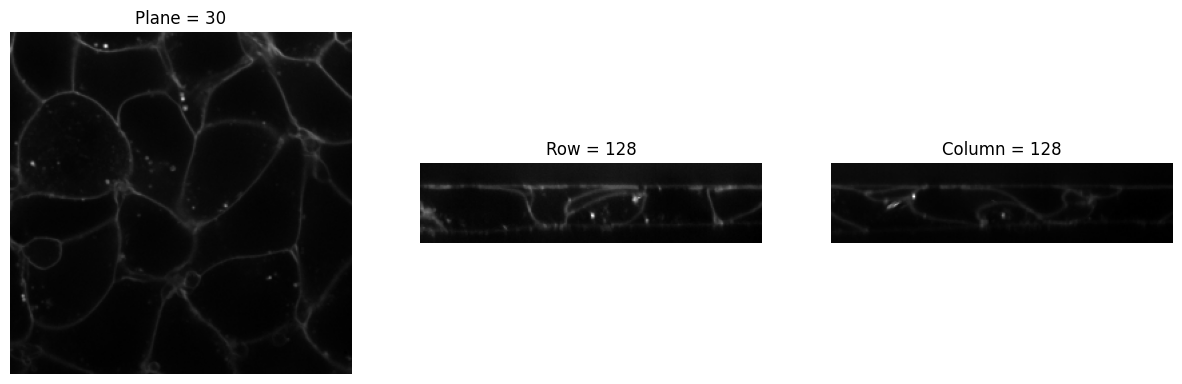

Output type: MetaTensor


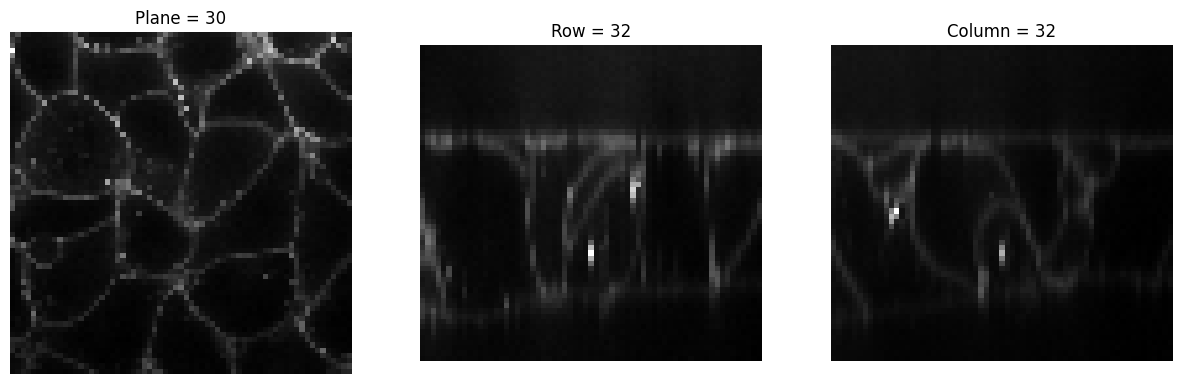

Output type: MetaTensor


/home/export/personal/miguel/anaconda3/envs/biomonai_latest/lib/python3.11/site-packages/monai/transforms/spatial/array.py:499: UserWarning: `data_array` is not of type MetaTensor, assuming affine to be identity.
  warnings.warn("`data_array` is not of type MetaTensor, assuming affine to be identity.")


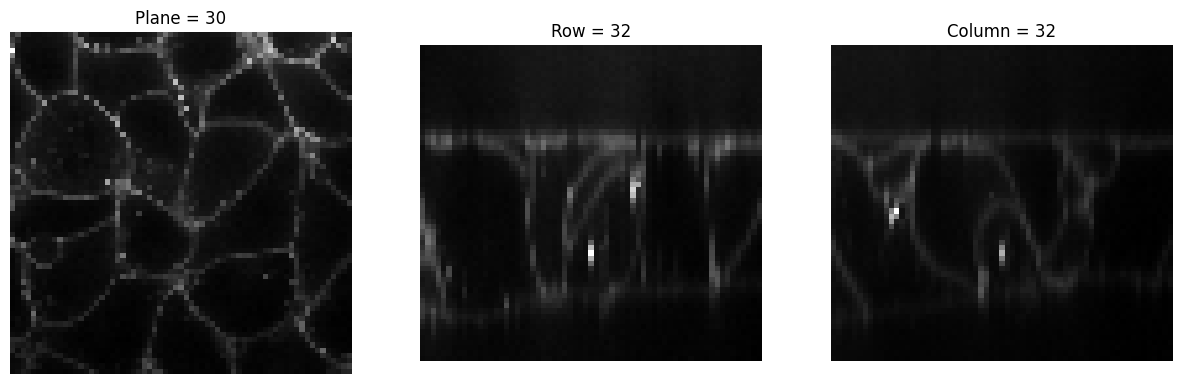

Output type: MetaTensor


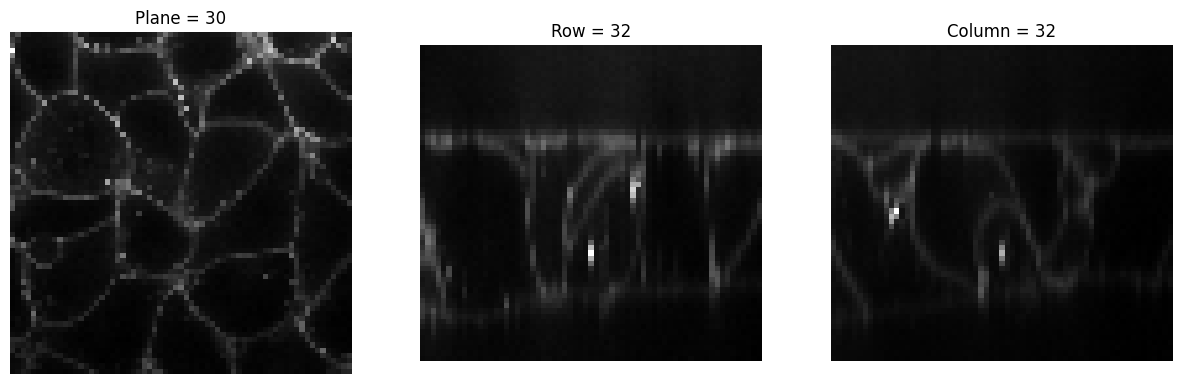

Output type: dict


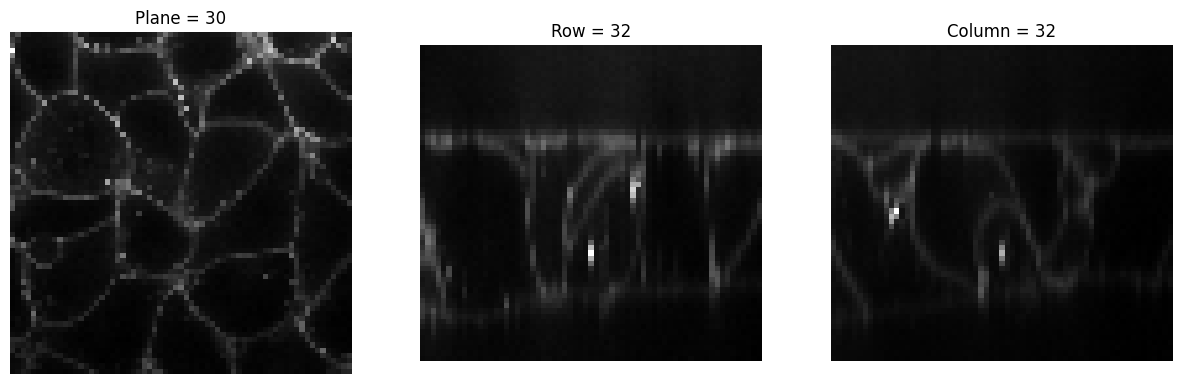

In [30]:
# Example: Resampling demonstrating polymorphic input support (BioVolume, Arrays, MetaTensor, and Dicts)
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices, show_image
from monai.data import MetaTensor

# 1. Base initialization
img = BioVolume(torchTensor(cells3d()[:,0]))
print("Input")
show_slices(img, showlines=False)

# 2. Applying to a BioVolume structure
img2 = Resample(4)(img)
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 3. Applying to a raw multi-dimensional array
img2 = Resample(4)(cells3d()[:,0])
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 4. Applying to a MONAI MetaTensor
img2 = Resample(4)(MetaTensor(img))
print("Output type:", type(img2).__name__)
show_slices(img2, showlines=False)

# 5. Applying using the dictionary-based inference path
img2 = Resample(4, keys=["image"])({ "image": MetaTensor(img) })
print("Output type:", type(img2).__name__)
show_slices(img2['image'], showlines=False)

In [31]:
#| hide
import monai.transforms as mt
import numpy as np
from fastcore.test import test_eq, test_fail

def test_resample_logic():
    # Test sampling parameter mapping
    tfm_samp = Resample(sampling=(2.0, 2.0), backend="monai")
    test_eq(isinstance(tfm_samp, mt.Spacing), True)
    test_eq(np.allclose(tfm_samp.pixdim, (2.0, 2.0)), True)
    
    # Test explicit pixdim fallback
    tfm_pix = Resample(pixdim=(1.0, 1.0, 1.0), backend="monai")
    test_eq(np.allclose(tfm_pix.pixdim, (1.0, 1.0, 1.0)), True)
    
    # Guard missing required parameters
    test_fail(
        lambda: Resample(backend="monai"), 
        contains="Provide either `sampling` or `pixdim`"
    )
    
    return "Passed"

test_eq(test_resample_logic(), "Passed")

### `Resample` Parameter Reference

This reference details the explicit configurations used to standardize structural dimensions across multi-modal scans.

**Returns:** A structural deterministic transformation pipeline calibrated to the requested execution `backend`.

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`sampling`** | `tuple`, `float`, or `int` | `None` | The target voxel spacing dimensions (e.g., `4` or `(1.5, 1.5)`). Can be passed directly as the first positional argument. Automatically mapped to `pixdim` internally. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the creation of the dictionary-based transformation counterpart (`Spacingd`). |
| **`*args, **kwargs`** | `Any` | - | Arbitrary arguments and properties (such as `mode` for interpolation, or `pixdim` directly) forwarded to MONAI's foundational `Spacing` routine. |

In [32]:
#| export 
class Spacing(MonaiTransform):
    """
    A wrapper around MONAI's Spacing transform that supports multiple input types and auto-infers dict transforms.

    """
    _monai_transform = mt.Spacing

    def __init__(
        self,
        pixdim=None,
        keys=None,
        **kwargs
    ):
       
        super().__init__(
            keys=keys,
            pixdim=pixdim,
            **kwargs
        )

In [33]:
show_doc(Spacing)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L462){target="_blank" style="float:right; font-size:smaller"}

### Spacing

```python

def Spacing(
    pixdim:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A wrapper around MONAI's Spacing transform that supports multiple input types and auto-infers dict transforms.*

In [34]:
# Example: Adjusting physical voxel spacing using the standard parameter convention
from fasttransform import Transform
import monai.transforms as mt

# 1. Initialize the Spacing pipeline wrapper
spacing_tfm = Spacing(pixdim=(1.5, 1.5, 1.5))

# 2. Verify pipeline integration
print(f"Transform Instance: {type(spacing_tfm).__name__}")
print(f"Inherits from fastai Transform: {isinstance(spacing_tfm, Transform)}")

# 3. Generating a native MONAI operator via the backend switch
native_spacing = Spacing(pixdim=(2.0, 2.0), backend="monai")
print(f"Native Instance: {type(native_spacing).__name__}")

Transform Instance: Spacing
Inherits from fastai Transform: False
Native Instance: Spacing


In [35]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_spacing_logic():
    # Transform inheritance (requires explicitly requesting the fastai wrapper)
    t = Spacing(1, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception (native MONAI path)
    t_monai = Spacing(pixdim=(2, 2), backend="monai")
    test_eq(isinstance(t_monai, mt.Spacing), True)
    
    # Dict transform inference
    t_dict = Spacing(pixdim=(1, 1), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Spacingd), True)

    return "Passed"

test_eq(test_spacing_logic(), "Passed")

### `Spacing` Parameter Reference

This reference details the configurations used for physical coordinate and voxel dimension standardisation.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`pixdim`** | `tuple`, `float`, or `int` | `None` | The specific target physical voxel dimensions (e.g., `(1.0, 1.0, 1.0)`). Can be passed as the first positional argument. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the automated inference of the dictionary-based counterpart (`Spacingd`). |
| **`backend`** | `str` | `"monai"` | The execution context flag. Must be explicitly set to `"fastai"` to return the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional configurations forwarded to MONAI's core `Spacing` routine (e.g., `mode="bilinear"`, `align_corners=True`). |

In [36]:
#| export
class Resize(MonaiTransform):
    """
    A wrapper around MONAI's Resize transform that supports multiple input types and auto-infers dict transforms.

    Args:
        size: output spatial size
        keys: keys for dict transforms (if applicable)
        **kwargs: additional arguments to pass to the underlying transform
    """
    _monai_transform = mt.Resize

    def __init__(
        self,
        spatial_size,        
        keys=None,
        **kwargs
    ):
        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs
        )

In [125]:
show_doc(Resize)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L483){target="_blank" style="float:right; font-size:smaller"}

### Resize

```python

def Resize(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A wrapper around MONAI's Resize transform that supports multiple input types and auto-infers dict transforms.*

Args:
    size: output spatial size
    keys: keys for dict transforms (if applicable)
    **kwargs: additional arguments to pass to the underlying transform

Original Input Size: torch.Size([60, 256, 256])


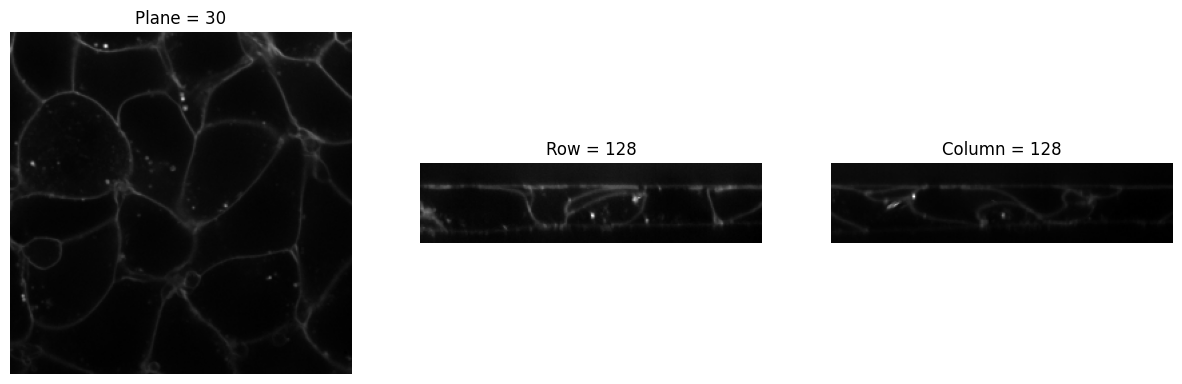

Resized Output Size: torch.Size([60, 50, 50])


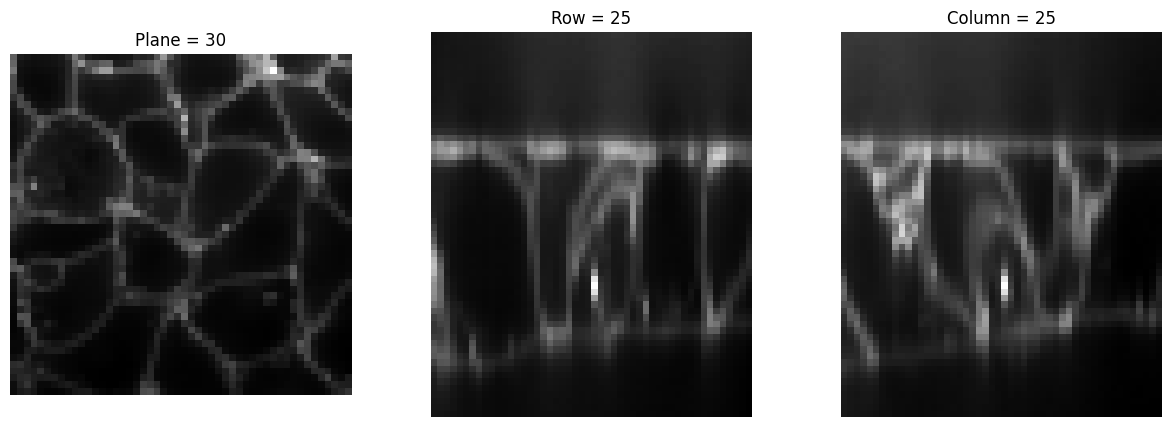

In [127]:
# Example: Forcing a specific absolute spatial dimension on a biological volume
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the Resize transform to forcefully interpolate to 50x50 spatial dimensions
# Note: The channel dimension remains untouched.
img2 = Resize((50, 50))(img)
print(f"Resized Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [128]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_resize_logic():
    # Transform inheritance
    t = Resize((32, 32), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception (Native MONAI path)
    t_monai = Resize((64, 64), backend="monai")
    test_eq(isinstance(t_monai, mt.Resize), True)
    
    # Dict transform inference
    t_dict = Resize((16, 16), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Resized), True)

    return "Passed"

test_eq(test_resize_logic(), "Passed")

### `Resize` Parameter Reference

This reference details the configurations used to force explicit target dimensions across multi-modal image arrays.

**Returns:** A dynamic fastai-compatible augmentation wrapper (`backend="fastai"`) or the native structural MONAI operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple` or `int` | *Required* | The absolute target spatial dimensions for the output tensor (e.g., `(50, 50)` or `(32, 32, 32)`). Passed as the first positional argument. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the automated inference of the dictionary-based counterpart (`Resized`). |
| **`backend`** | `str` | `"monai"` | The execution context flag. Set to `"fastai"` to return the stateful pipeline wrapper object. |
| **`**kwargs`** | `dict` | `{}` | Additional interpolation settings forwarded to MONAI's core `Resize` routine (e.g., `mode="area"`, `anti_aliasing=True`). |

In [132]:
#| export
class Crop(MonaiTransform):
    """
    MONAI SpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialCrop

    def __init__(
        self,
        roi_center=None, 
        roi_size=None, 
        roi_start=None, 
        roi_end=None, 
        roi_slices=None,
        keys=None,
        **kwargs
    ):
        super().__init__(
            roi_center=roi_center,
            roi_size=roi_size,
            roi_start=roi_start,
            roi_end=roi_end,
            roi_slices=roi_slices,
            keys=keys,
            **kwargs
        )

In [133]:
show_doc(Crop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L507){target="_blank" style="float:right; font-size:smaller"}

### Crop

```python

def Crop(
    roi_center:NoneType=None, roi_size:NoneType=None, roi_start:NoneType=None, roi_end:NoneType=None,
    roi_slices:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


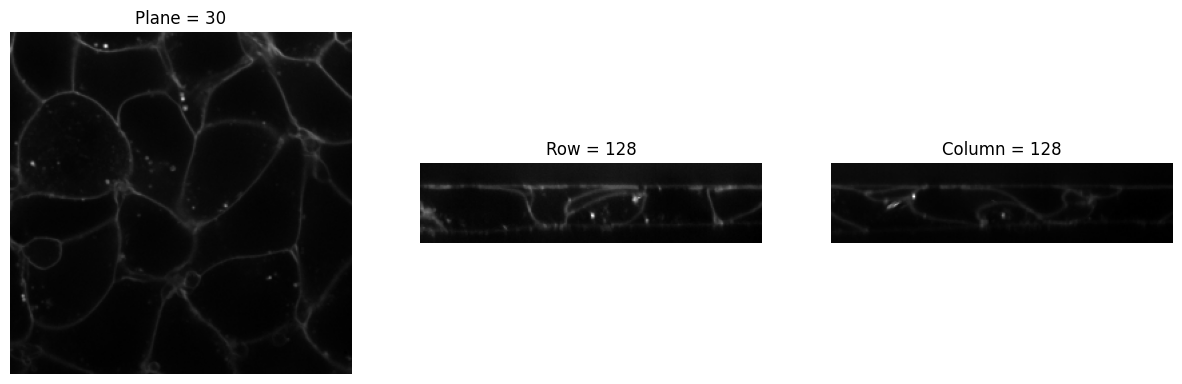

Cropped Output Size: torch.Size([60, 150, 150])


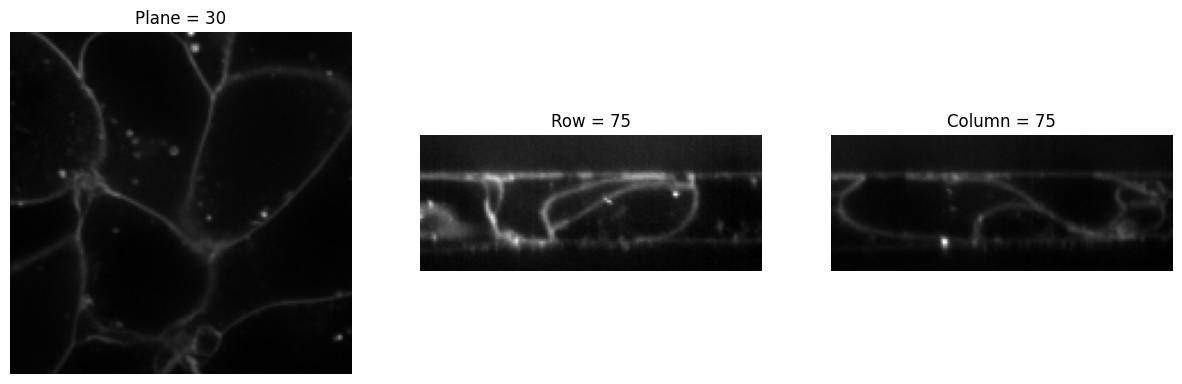

In [147]:
# Example: Performing a precise deterministic crop on a 2D slice
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image
# By slicing [:, 0], we extract a single 2D slice (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a specific region using starting and ending coordinates
# Since our input is 2D (Y, X), we provide 2D coordinates.
crop_tfm = Crop(roi_start=(50, 50), roi_end=(200, 200))
img2 = crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [136]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_crop_logic():
    # Transform inheritance
    t = Crop(roi_start=[0, 0], roi_end=[10, 10], backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to SpatialCrop
    t_monai = Crop(roi_start=[0, 0], roi_end=[10, 10], backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialCrop), True)
    
    # Dict transform inference mapping to SpatialCropd
    t_dict = Crop(roi_start=[0, 0], roi_end=[10, 10], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialCropd), True)

    return "Passed"

test_eq(test_crop_logic(), "Passed")

### `Crop` Parameter Reference

This reference details the configurations used to explicitly define bounding boxes for spatial extractions. 

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_center`** | `tuple` or `list` | `None` | Voxel coordinates representing the center of the target crop region. |
| **`roi_size`** | `tuple` or `list` | `None` | The spatial extent (dimensions) of the bounding box to be extracted. |
| **`roi_start`** | `tuple` or `list` | `None` | Voxel coordinates for the starting corner of the bounding box. |
| **`roi_end`** | `tuple` or `list` | `None` | Voxel coordinates for the ending corner of the bounding box. |
| **`roi_slices`** | `tuple` of `slice` | `None` | Explicit Python slice objects defining the exact extraction region. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [138]:
#| export
class SpatialCrop(MonaiTransform):
    """
    MONAI SpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialCrop

    def __init__(
        self,
        roi_center=None, 
        roi_size=None, 
        roi_start=None, 
        roi_end=None, 
        roi_slices=None,
        keys=None,
        **kwargs
    ):
        super().__init__(
            roi_center=roi_center,
            roi_size=roi_size,
            roi_start=roi_start,
            roi_end=roi_end,
            roi_slices=roi_slices,
            keys=keys,
            **kwargs
        )

In [139]:
show_doc(SpatialCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L521){target="_blank" style="float:right; font-size:smaller"}

### SpatialCrop

```python

def SpatialCrop(
    roi_center:NoneType=None, roi_size:NoneType=None, roi_start:NoneType=None, roi_end:NoneType=None,
    roi_slices:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


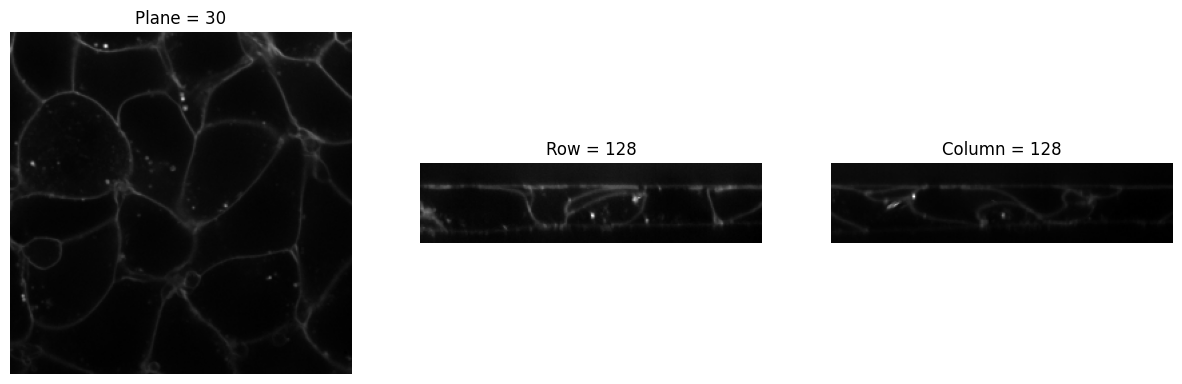

Cropped Output Size: torch.Size([60, 100, 100])


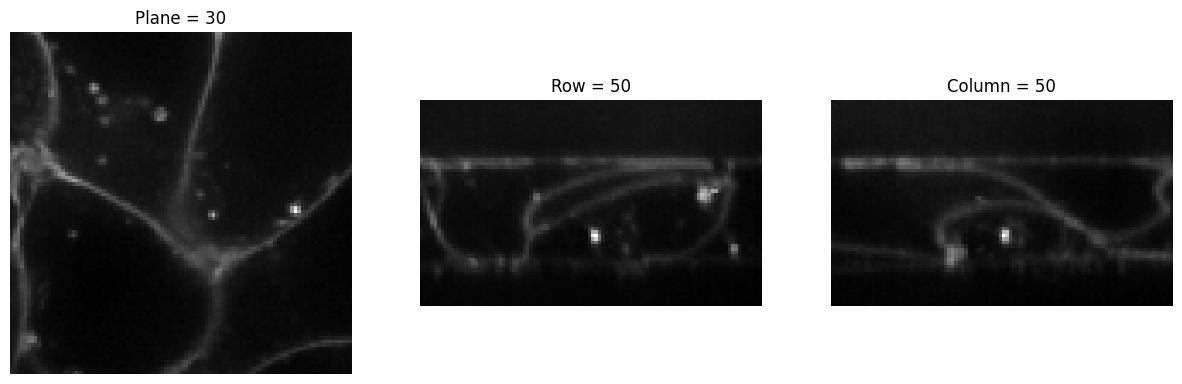

In [148]:
# Example: Targeting a specific anatomical region using a center coordinate and bounding box
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a specific patch around a central point
# Providing 2D coordinates for the center (Y, X) and the bounding box size (Y, X).
spatial_crop_tfm = SpatialCrop(roi_center=(128, 128), roi_size=(100, 100))
img2 = spatial_crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [141]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_spatial_crop_logic():
    # Transform inheritance
    t = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to SpatialCrop
    t_monai = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialCrop), True)
    
    # Dict transform inference mapping to SpatialCropd
    t_dict = SpatialCrop(roi_center=[10, 10], roi_size=[5, 5], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialCropd), True)

    return "Passed"

test_eq(test_spatial_crop_logic(), "Passed")

### `SpatialCrop` Parameter Reference

This reference details the configurations used to explicitly define bounding boxes for spatial extractions. 

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_center`** | `tuple` or `list` | `None` | Voxel coordinates representing the center point of the target crop region. |
| **`roi_size`** | `tuple` or `list` | `None` | The specific spatial extent (dimensions) of the bounding box to be extracted. |
| **`roi_start`** | `tuple` or `list` | `None` | Voxel coordinates for the starting corner of the bounding box. |
| **`roi_end`** | `tuple` or `list` | `None` | Voxel coordinates for the ending corner of the bounding box. |
| **`roi_slices`** | `tuple` of `slice` | `None` | Explicit Python slice objects defining the exact extraction region. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the stateful pipeline wrapper. |

In [143]:
#| export
class CenterSpatialCrop(MonaiTransform):
    """
    MONAI CenterSpatialCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterSpatialCropd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterSpatialCrop

    def __init__(
        self,
        roi_size=None,
        keys=None,
        **kwargs,
    ):
        """
        roi_size:
            - int → broadcast to all spatial dims
            - tuple/list → target spatial size
        """

        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size,   # MONAI expects this arg
            **kwargs,
        )

In [144]:
show_doc(CenterSpatialCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L535){target="_blank" style="float:right; font-size:smaller"}

### CenterSpatialCrop

```python

def CenterSpatialCrop(
    roi_size:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI CenterSpatialCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CenterSpatialCropd auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


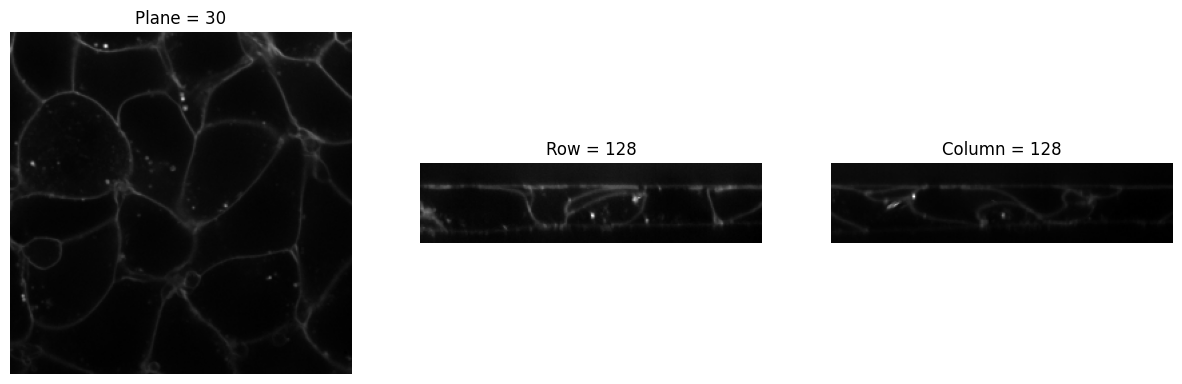

Cropped Output Size: torch.Size([60, 100, 100])


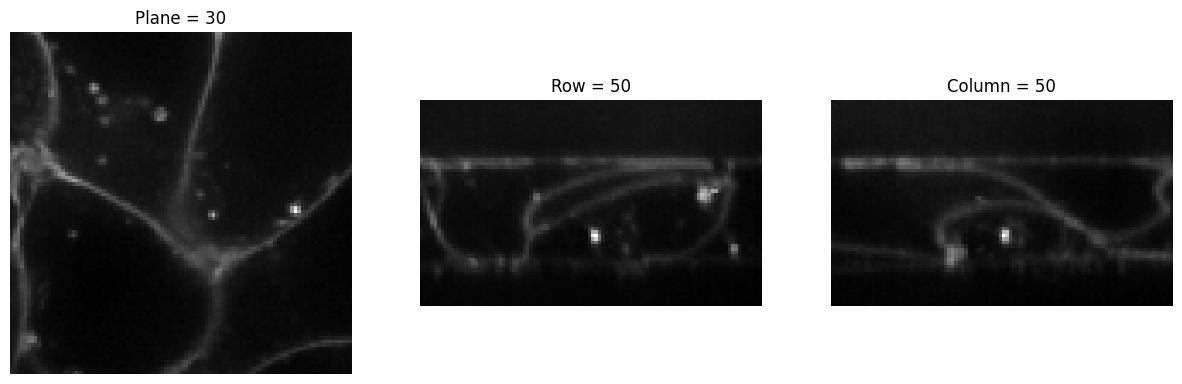

In [146]:
# Example: Automatically cropping a central patch from a biological image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image
# By slicing [:, 0], we extract a single 2D slice (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a centered region
# Since our input is 2D, we provide a 2D roi_size (Y, X).
# We could also just pass `roi_size=100` and it would broadcast automatically.
center_crop_tfm = CenterSpatialCrop(roi_size=(100, 100))
img2 = center_crop_tfm(img)

print(f"Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [149]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_center_spatial_crop_logic():
    # Transform inheritance
    t = CenterSpatialCrop(roi_size=16, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to CenterSpatialCrop
    t_monai = CenterSpatialCrop(roi_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.CenterSpatialCrop), True)
    
    # Dict transform inference mapping to CenterSpatialCropd
    t_dict = CenterSpatialCrop(roi_size=32, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.CenterSpatialCropd), True)

    return "Passed"

test_eq(test_center_spatial_crop_logic(), "Passed")

### `CenterSpatialCrop` Parameter Reference

This reference details the configurations used to dynamically extract center-aligned regions from spatial arrays.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_size`** | `tuple`, `list`, or `int` | `None` | The dimensions of the target bounding box. If an `int` is passed, it broadcasts isotropically across all spatial axes. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`CenterSpatialCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator. |

In [41]:
#| export
class CropForeground(MonaiTransform):
    """
    MONAI CropForeground wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CropForeground*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CropForeground

In [150]:
show_doc(CropForeground)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L568){target="_blank" style="float:right; font-size:smaller"}

### CropForeground

```python

def CropForeground(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI CropForeground wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CropForeground*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


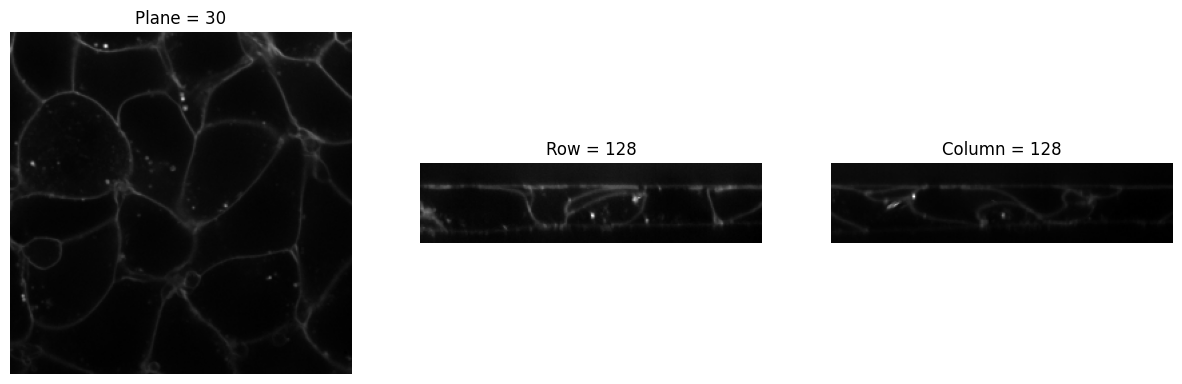

Foreground Cropped Size: torch.Size([60, 266, 266])


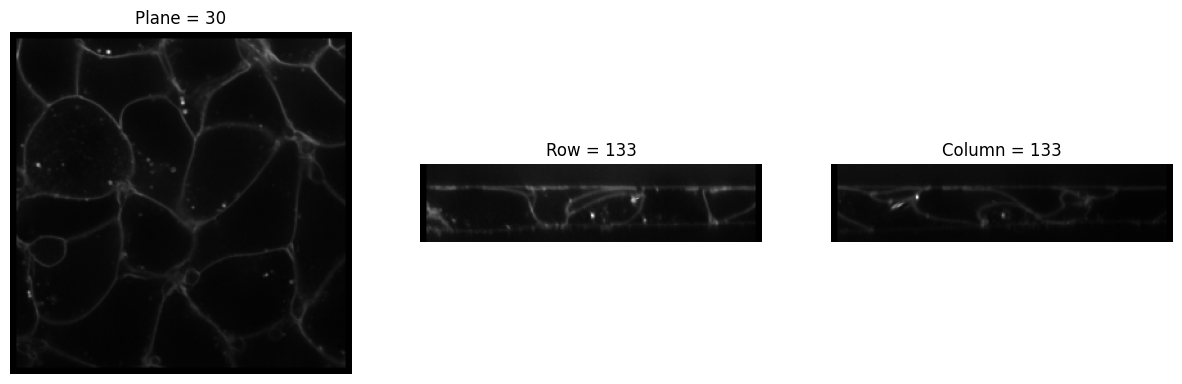

In [151]:
# Example: Dynamically removing black background borders from an image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract the foreground dynamically
# By default, MONAI considers any pixel > 0 as foreground.
# We can add a spatial margin (e.g., 5 pixels) around the detected bounding box.
crop_fg_tfm = CropForeground(margin=5)
img2 = crop_fg_tfm(img)

print(f"Foreground Cropped Size: {img2.shape}")
show_slices(img2, showlines=False)

In [153]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_crop_foreground_logic():
    # Transform inheritance
    t = CropForeground(margin=1, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to CropForeground
    t_monai = CropForeground(margin=2, backend="monai")
    test_eq(isinstance(t_monai, mt.CropForeground), True)
    
    # Dict transform inference mapping to CropForegroundd
    # Note: CropForegroundd strictly requires 'source_key' to compute the bounding box.
    t_dict = CropForeground(keys=["image", "label"], source_key="image", margin=1, backend="monai")
    test_eq(isinstance(t_dict, mt.CropForegroundd), True)

    return "Passed"

test_eq(test_crop_foreground_logic(), "Passed")

### `CropForeground` Parameter Reference

This reference details the configurations used to dynamically isolate active signal regions from background noise.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native dynamic cropping operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`select_fn`** | `callable` | `lambda x: x > 0` | A function that evaluates the tensor to identify foreground voxels (returns a boolean array). Passed via `**kwargs`. |
| **`margin`** | `int` or `tuple` | `0` | Extra padding/margin to retain around the calculated foreground bounding box. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary-based counterpart (`CropForegroundd`). |
| **`source_key`** | `str` | `None` | **Required if using `keys`.** Tells MONAI which dictionary key to evaluate to calculate the cropping bounding box. Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator (e.g., `allow_smaller`, `return_coords`). |

In [154]:
#| export
class BoundingRect(MonaiTransform):
    """
    MONAI BoundingRect wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BoundingRect*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BoundingRect

In [155]:
show_doc(BoundingRect)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L581){target="_blank" style="float:right; font-size:smaller"}

### BoundingRect

```python

def BoundingRect(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI BoundingRect wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (BoundingRect*d auto-inferred)
- BioImageBase
- NumPy arrays

In [156]:
# Example: Calculating the bounding box coordinates of an active signal
from bioMONAI.datasets import cells3d

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")

# 2. Extract bounding rectangle coordinates
# By default, it finds the absolute limits of all pixels > 0.
# It returns a set of [min, max] coordinates for each spatial dimension.
bbox_tfm = BoundingRect()
coords = bbox_tfm(img)

print(f"Computed Bounding Box Coordinates [[Y_min, Y_max], [X_min, X_max]]:\n{coords}")

Original Input Size: torch.Size([60, 256, 256])
Computed Bounding Box Coordinates [[Y_min, Y_max], [X_min, X_max]]:
[[  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256   0 256]
 [  0 256 

In [157]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_bounding_rect_logic():
    # Transform inheritance
    t = BoundingRect(backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping
    t_monai = BoundingRect(backend="monai")
    test_eq(isinstance(t_monai, mt.BoundingRect), True)
    
    # Dict transform inference
    # Note: BoundingRectd will evaluate the provided keys and output the coordinates
    # to a new key internally suffixed with '_bbox' (e.g., 'image_bbox').
    t_dict = BoundingRect(keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.BoundingRectd), True)

    return "Passed"

test_eq(test_bounding_rect_logic(), "Passed")

### `BoundingRect` Parameter Reference

This reference details the configurations used to analyze and extract the spatial coordinate limits of active regions.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`select_fn`** | `callable` | `lambda x: x > 0` | A function to evaluate which pixels belong to the foreground. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary counterpart (`BoundingRectd`). |
| **`bbox_key_postfix`** | `str` | `"bbox"` | **Only applicable if using `keys`.** The string appended to the original key to store the resulting coordinates in the dictionary (e.g., `"image_bbox"`). Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [43]:
#| export
class CenterScaleCrop(MonaiTransform):
    """
    MONAI CenterScaleCrop wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (CenterScaleCrop*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.CenterScaleCrop

    def __init__(
        self,
        roi_scale=1.0,
        keys=None,
        **kwargs,
    ):

        self.roi_scale = roi_scale

        super().__init__(
            keys=keys,
            roi_scale=roi_scale, 
            **kwargs,
        )

In [158]:
show_doc(CenterScaleCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L594){target="_blank" style="float:right; font-size:smaller"}

### CenterScaleCrop

```python

def CenterScaleCrop(
    roi_scale:float=1.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI CenterScaleCrop wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (CenterScaleCrop*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


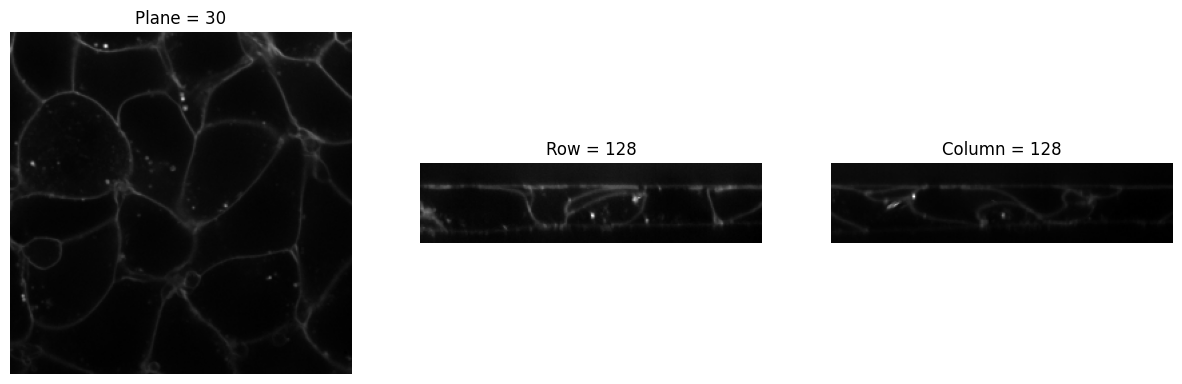

Proportionally Cropped Output Size: torch.Size([60, 128, 128])


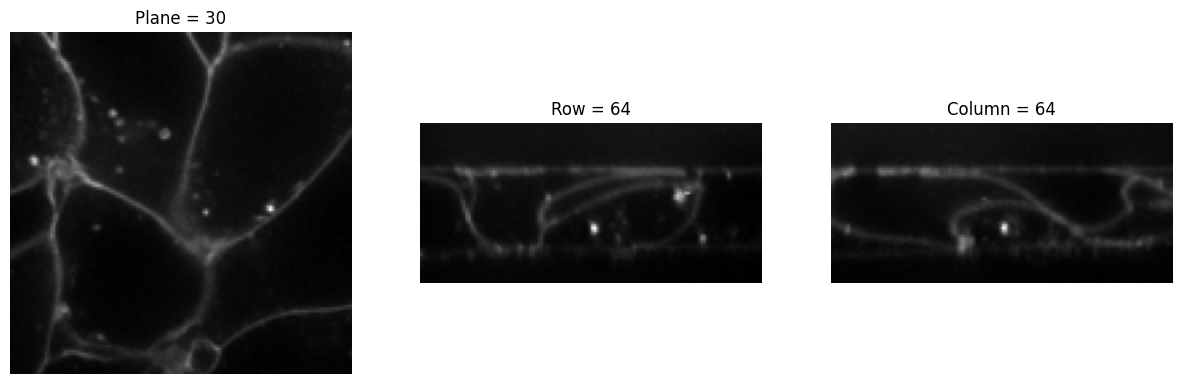

In [159]:
# Example: Proportionally cropping the central 50% of an image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Extract a proportionally scaled center region
# Passing 0.5 means we want to crop the central region covering exactly 50% 
# of the original spatial dimensions (Y and X).
scale_crop_tfm = CenterScaleCrop(roi_scale=0.5)
img2 = scale_crop_tfm(img)

print(f"Proportionally Cropped Output Size: {img2.shape}")
show_slices(img2, showlines=False)

In [160]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_center_scale_crop_logic():
    # Transform inheritance
    t = CenterScaleCrop(roi_scale=0.8, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to CenterScaleCrop
    t_monai = CenterScaleCrop(roi_scale=(0.5, 0.5), backend="monai")
    test_eq(isinstance(t_monai, mt.CenterScaleCrop), True)
    
    # Dict transform inference mapping to CenterScaleCropd
    t_dict = CenterScaleCrop(roi_scale=0.5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.CenterScaleCropd), True)

    return "Passed"

test_eq(test_center_scale_crop_logic(), "Passed")

### `CenterScaleCrop` Parameter Reference

This reference details the configurations used to dynamically extract proportional regions based on original array sizes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`roi_scale`** | `tuple`, `list`, or `float` | `1.0` | The fractional scale of the original size to extract. For example, `0.5` extracts the central 50% region. A single float broadcasts to all spatial axes. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`CenterScaleCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties passed directly to the MONAI base operator. |

In [44]:
#| export

class CropND(fastTransform):
    """
    Crops an ND tensor along a specified dimension.

    This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.
    """
    
    def __init__(self, 
                 slices: list, # List of slice objects or tuples (start, end) for each dimension
                 dims: list = None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
                 ):
        self.slices = [slice(*s) if isinstance(s, tuple) else s for s in slices]
        self.dims = dims
        
    def encodes(self, x: BioImageBase):
        """Apply cropping to a BioImageBase object."""
        bioimagetype = type(x)
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return bioimagetype(x[tuple(slices)])
    
    def encodes(self, x: np.ndarray):
        """Apply cropping to a NumPy array."""
        slices = [slice(None)] * x.ndim
        if self.dims is None:
            for i, s in enumerate(self.slices):
                if x.shape[i] >= s.stop - s.start:
                    slices[i] = s
        else:
            for dim, s in zip(self.dims, self.slices):
                if x.shape[dim] >= s.stop - s.start:
                    slices[dim] = s
        return x[tuple(slices)]

In [161]:
show_doc(CropND)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L622){target="_blank" style="float:right; font-size:smaller"}

### CropND

```python

def CropND(
    slices:list, # List of slice objects or tuples (start, end) for each dimension
    dims:list=None, # List of dimensions to apply the slices. If None, slices are applied to all dimensions.
):


```

*Crops an ND tensor along a specified dimension.*

This transform crops an ND tensor along specified dimensions, which could be a channel or spatial dimension.

Original Input Size: torch.Size([60, 256, 256])


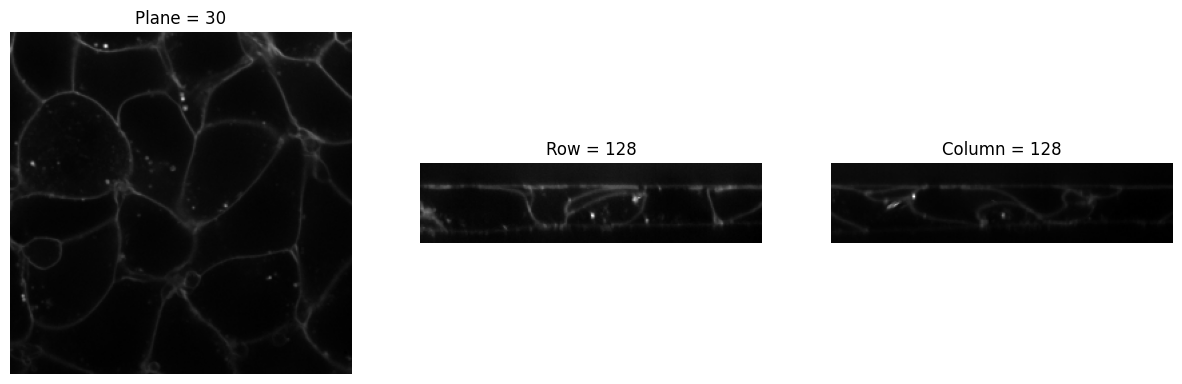

Sequentially Cropped Size:
torch.Size([20, 256, 256])


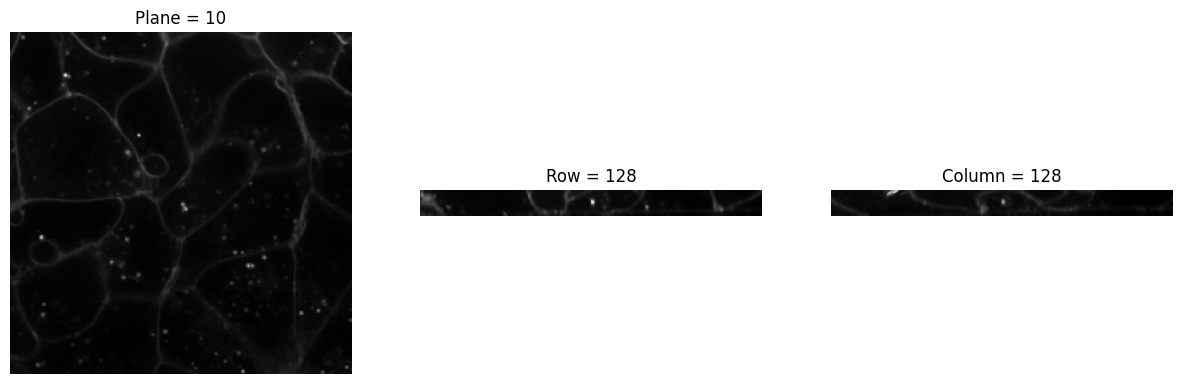

Targeted Cropped Size:
torch.Size([20, 256, 40])


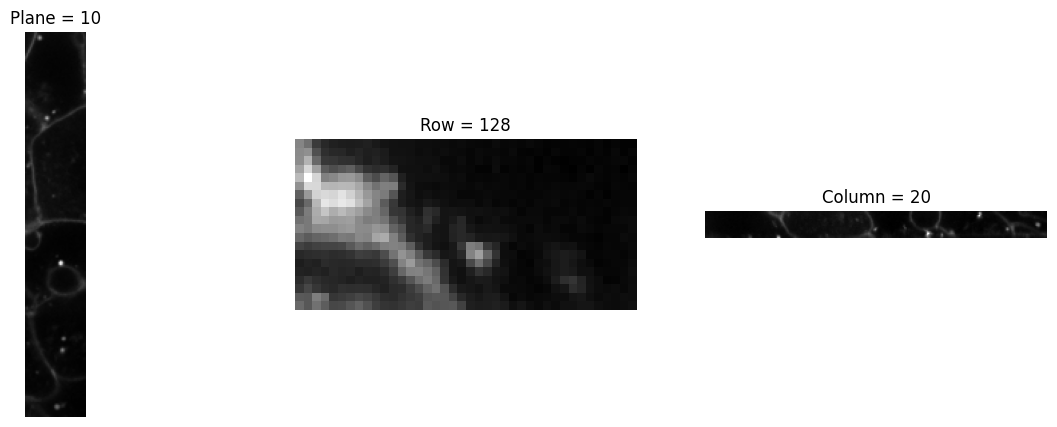

In [165]:
# Example: Slicing specific dimensions natively via CropND
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# --- Scenario A: Sequential Cropping ---
# Define the slices for cropping (applied to the first dimension)
slices = [(30, 50)]

# Create an instance of CropND
crop_transform = CropND(slices=slices)

img3 = crop_transform(img)
print(f"Sequentially Cropped Size:")
print(img3.size())
show_slices(img3, showlines=False)


# --- Scenario B: Dimension-Targeted Cropping ---
# Define the slices for cropping
slices = [(30, 50), (0, 40)]
dims = [0, 2]
# Create an instance of CropND
crop_transform = CropND(slices=slices, dims=dims)

img4 = crop_transform(img)
print(f"Targeted Cropped Size:")
print(img4.size())
show_slices(img4, showlines=False)

In [166]:
#| hide
from fastcore.test import test_eq
import numpy as np

def test_crop_nd_logic():
    # Create a dummy 3D array [C, Y, X] -> shape (5, 50, 50)
    dummy_data = np.zeros((5, 50, 50))
    
    # Test sequential slicing (dims=None)
    # Should slice dimension 0 from 1 to 4 -> length 3
    t_seq = CropND(slices=[(1, 4)])
    res_seq = t_seq(dummy_data)
    test_eq(res_seq.shape, (3, 50, 50))
    
    # Test dimension-targeted slicing
    # Should slice dim 1 (Y) to length 20, and dim 2 (X) to length 10
    t_dim = CropND(slices=[(10, 30), (0, 10)], dims=[1, 2])
    res_dim = t_dim(dummy_data)
    test_eq(res_dim.shape, (5, 20, 10))
    
    # Test protective mechanism (slice size > shape)
    # If requested slice is larger than dimension, it should ignore the slice
    t_protect = CropND(slices=[(0, 100)], dims=[1])
    res_protect = t_protect(dummy_data)
    test_eq(res_protect.shape, (5, 50, 50)) # Shape remains unchanged

    return "Passed"

test_eq(test_crop_nd_logic(), "Passed")

### `CropND` Parameter Reference

This reference details the configurations used for native, N-dimensional tensor slicing.

**Returns:** A sliced tensor matching the incoming data type (`BioImageBase` or `np.ndarray`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`slices`** | `list` | *Required* | A list of explicit Python `slice` objects or `(start, end)` tuples defining the boundaries for the crop. |
| **`dims`** | `list[int]` or `None` | `None` | The specific integer axes corresponding to each slice. If `None`, slices are applied sequentially starting from axis `0`. |

In [170]:
#| export
class Pad(MonaiTransform):
    """
    MONAI Pad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Padd auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Pad

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # MONAI's Padd is an architectural exception: it requires an instantiated 
        # 'padder' object rather than raw arguments like 'to_pad'.
        padder_obj = cls._monai_transform(*args, **kwargs)
        
        # Extract 'mode' if provided, as Padd also expects it at the dict level
        mode = kwargs.get("mode", "constant")
        
        return mt.Padd(keys=keys, padder=padder_obj, mode=mode)

In [171]:
show_doc(Pad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L664){target="_blank" style="float:right; font-size:smaller"}

### Pad

```python

def Pad(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI Pad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Padd auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


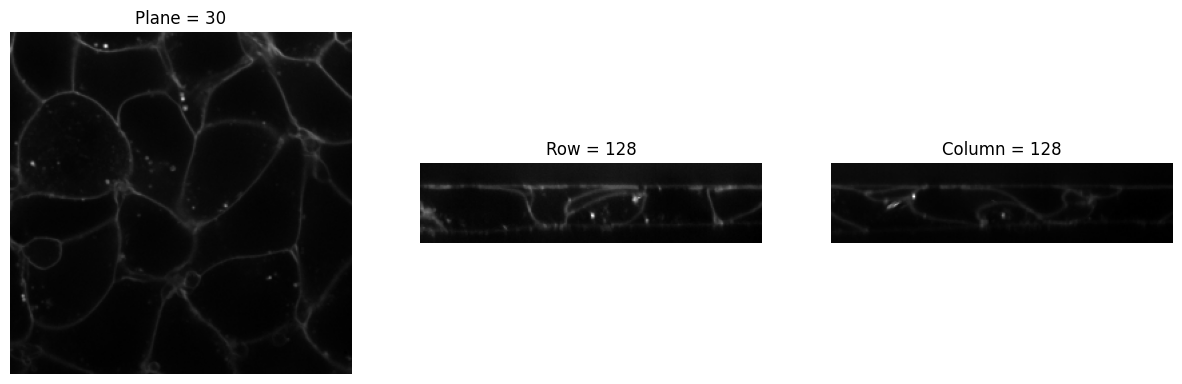

Padded Output Size:
torch.Size([60, 316, 316])


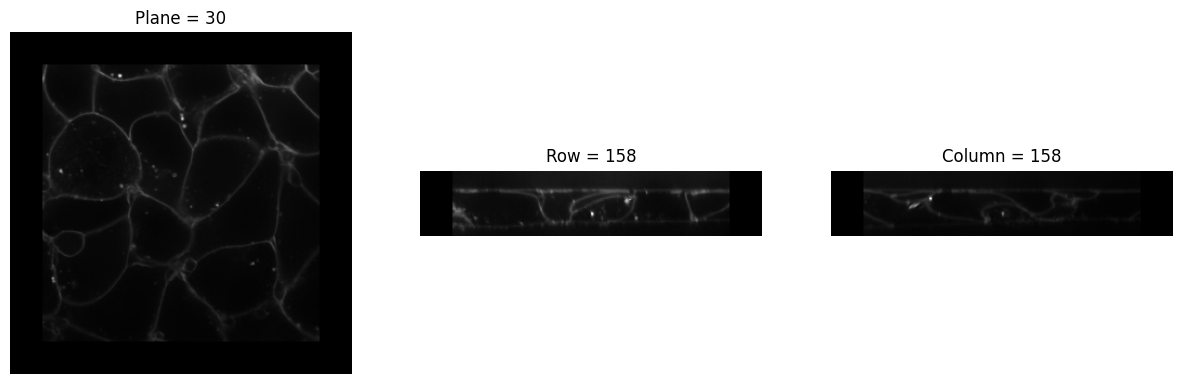

In [172]:
# Example: Adding explicit borders to an image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Add symmetric padding to the spatial dimensions
# 'to_pad' expects a tuple of (pad_before, pad_after) for each dimension.
# Our shape is [Channels, Y, X]. We add 0 padding to Channels, 
# and 30 pixels of padding before and after the Y and X axes.
pad_tfm = Pad(to_pad=[(0, 0), (30, 30), (30, 30)])
img2 = pad_tfm(img)

print(f"Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [173]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_pad_logic():
    # Transform inheritance
    t = Pad(to_pad=[(1, 1), (2, 2)], backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Pad
    t_monai = Pad(to_pad=[(1, 1)], backend="monai")
    test_eq(isinstance(t_monai, mt.Pad), True)
    
    # Dict transform inference mapping to Padd
    t_dict = Pad(to_pad=[(1, 1)], keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Padd), True)

    return "Passed"

test_eq(test_pad_logic(), "Passed")

### `Pad` Parameter Reference

This reference details the explicit configurations used to expand tensor margins.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`to_pad`** | `list` of `tuple` | *Required* | A sequence of `(pad_before, pad_after)` integer pairs for each dimension of the input tensor. Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The padding strategy to apply. Options typically include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`value`** | `float` or `int` | `0` | The fill value to use if `mode="constant"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Padd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [48]:
#| export
class SpatialPad(MonaiTransform):
    """
    MONAI SpatialPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.SpatialPad

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size, 
            **kwargs,
        )

In [174]:
show_doc(SpatialPad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L677){target="_blank" style="float:right; font-size:smaller"}

### SpatialPad

```python

def SpatialPad(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI SpatialPad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialPad*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


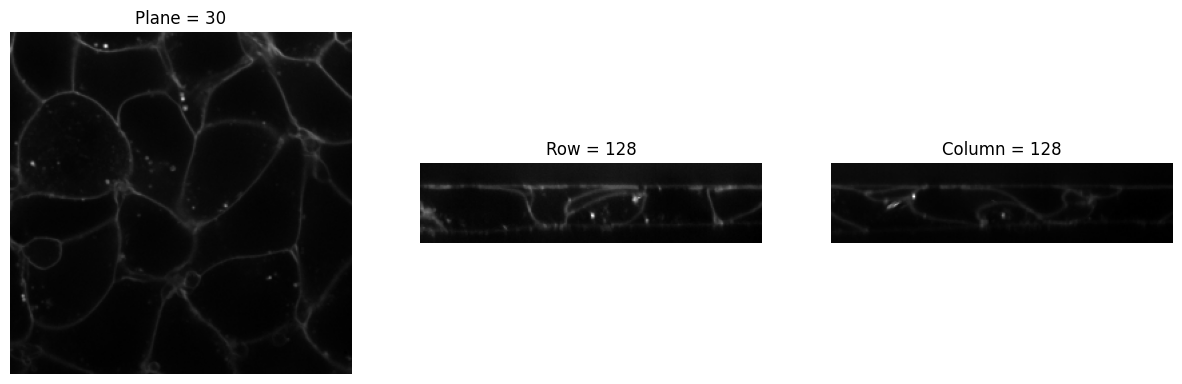

Spatially Padded Output Size:
torch.Size([60, 300, 300])


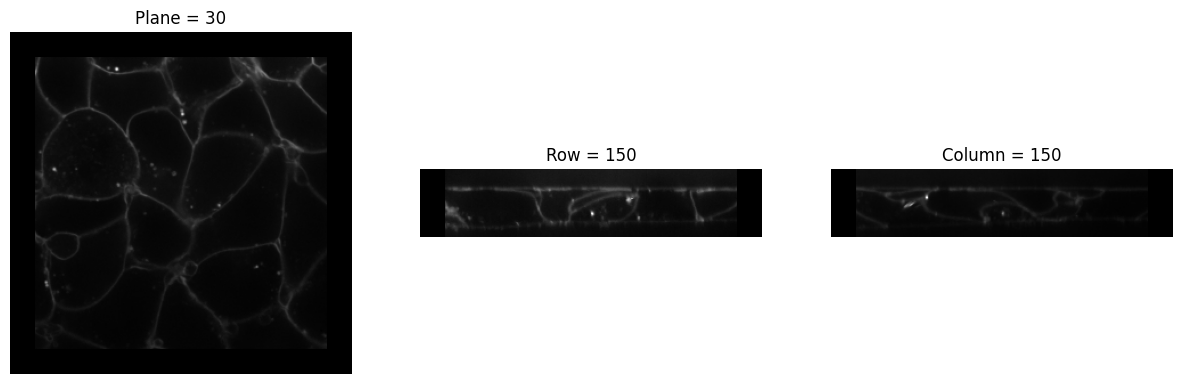

In [175]:
# Example: Smartly padding an image to guarantee a minimum absolute spatial shape
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Pad the image to a guaranteed absolute size
# We pass a target 2D spatial size (Y, X). For instance, if the original image 
# is 256x256, setting spatial_size to (300, 300) will add padding to reach it.
# By default, it pads symmetrically around the center.
spatial_pad_tfm = SpatialPad(spatial_size=(300, 300))
img2 = spatial_pad_tfm(img)

print(f"Spatially Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [176]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_spatial_pad_logic():
    # Transform inheritance
    t = SpatialPad(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to SpatialPad
    t_monai = SpatialPad(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialPad), True)
    
    # Dict transform inference mapping to SpatialPadd
    t_dict = SpatialPad(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialPadd), True)

    return "Passed"

test_eq(test_spatial_pad_logic(), "Passed")

### `SpatialPad` Parameter Reference

This reference details the configurations used to smartly guarantee minimum tensor shapes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `int` | *Required* | The absolute target spatial dimensions for the output tensor (e.g., `(300, 300)`). Passed as the first positional argument. |
| **`method`** | `str` | `"symmetric"` | The padding method to calculate the margins. Options include `"symmetric"` (centers the image) or `"end"` (pads only at the right/bottom). Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialPadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [49]:
#| export
class BorderPad(MonaiTransform):
    """
    MONAI BorderPad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (BorderPad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.BorderPad

    def __init__(
        self,
        spatial_border,
        keys=None,
        **kwargs,
    ):
        self.border_size = spatial_border

        super().__init__(
            keys=keys,
            spatial_border=spatial_border, 
            **kwargs,
        )

In [177]:
show_doc(BorderPad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L704){target="_blank" style="float:right; font-size:smaller"}

### BorderPad

```python

def BorderPad(
    spatial_border, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI BorderPad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (BorderPad*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


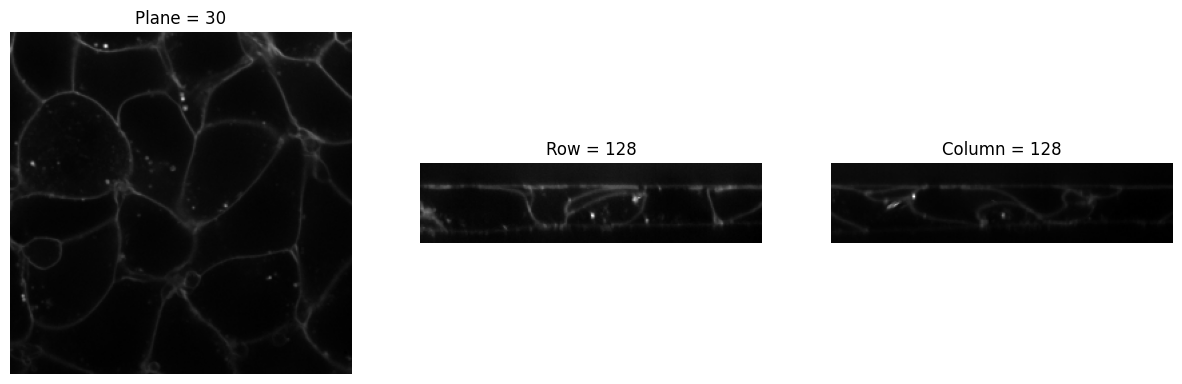

Border-Padded Output Size:
torch.Size([60, 296, 296])


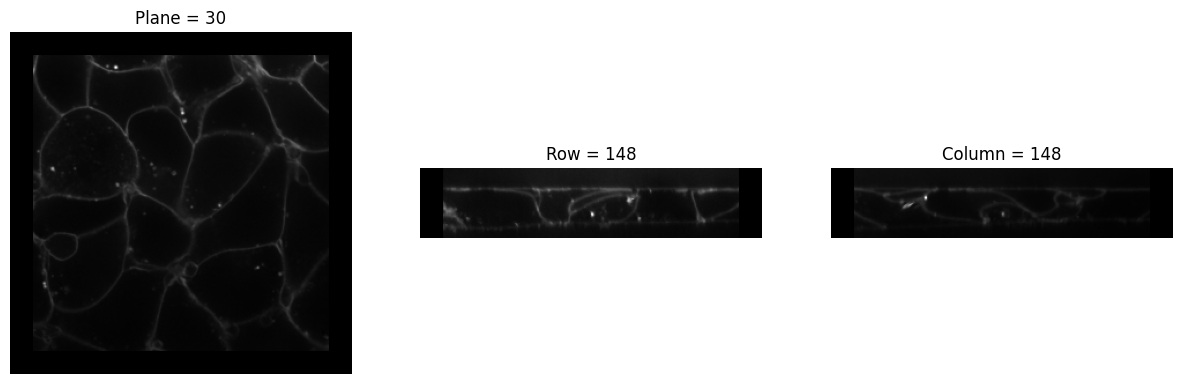

In [178]:
# Example: Adding a uniform margin around the entire spatial boundary
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a uniform border pad
# Passing an integer adds that exact amount of padding to both sides 
# of all spatial dimensions. (e.g., +20 pixels to top, bottom, left, and right).
border_pad_tfm = BorderPad(spatial_border=20)
img2 = border_pad_tfm(img)

print(f"Border-Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [179]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_border_pad_logic():
    # Transform inheritance
    t = BorderPad(spatial_border=10, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to BorderPad
    t_monai = BorderPad(spatial_border=5, backend="monai")
    test_eq(isinstance(t_monai, mt.BorderPad), True)
    
    # Dict transform inference mapping to BorderPadd
    t_dict = BorderPad(spatial_border=5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.BorderPadd), True)

    return "Passed"

test_eq(test_border_pad_logic(), "Passed")

### `BorderPad` Parameter Reference

This reference details the configurations used to dynamically attach margins to spatial axes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_border`** | `int` or `tuple` | *Required* | The number of pixels/voxels to pad at the boundaries. An integer applies symmetrically to all spatial axes. A tuple allows dimension-specific borders. Passed as a positional argument. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`BorderPadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [50]:
#| export
class DivisiblePad(MonaiTransform):
    """
    MONAI DivisiblePad wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (DivisiblePad*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.DivisiblePad

    def __init__(
        self,
        k,
        keys=None,
        **kwargs,
    ):

        super().__init__(
            keys=keys,
            k=k, 
            **kwargs,
        )

In [180]:
show_doc(DivisiblePad)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L731){target="_blank" style="float:right; font-size:smaller"}

### DivisiblePad

```python

def DivisiblePad(
    k, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI DivisiblePad wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (DivisiblePad*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Odd Input Size: torch.Size([60, 100, 125])


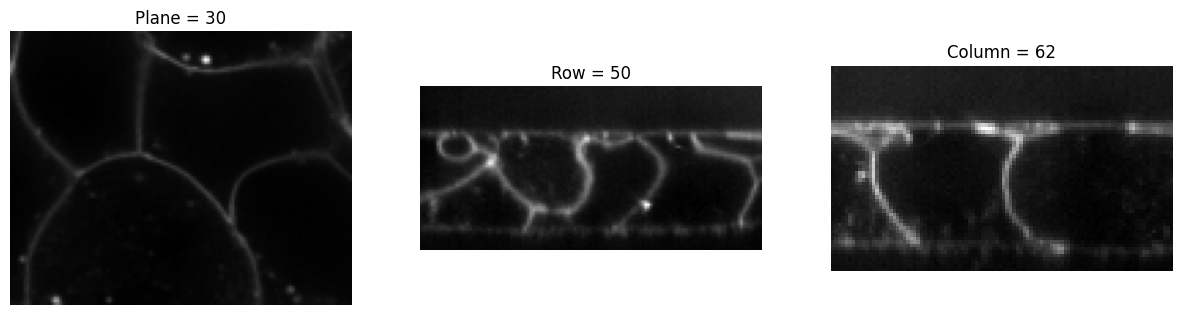

Divisible-Padded Output Size:
torch.Size([60, 128, 128])


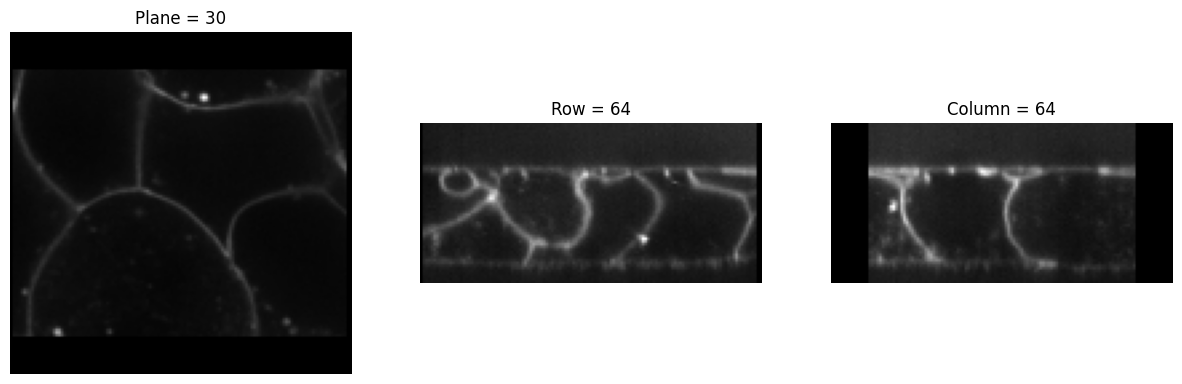

In [181]:
# Example: Automatically padding an oddly shaped image for U-Net compatibility
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize a base image and artificially crop it to an odd shape (Shape: [Channels, 100, 125])
img_full = BioVolume(torchTensor(cells3d()[:,0]))
img_odd = img_full[:, :100, :125]
print(f"Original Odd Input Size: {img_odd.shape}")
show_slices(img_odd, showlines=False)

# 2. Pad to make spatial dimensions divisible by 32
# A standard U-Net with 5 pooling operations requires spatial sizes to be multiples of 2^5 = 32.
# Here, the Y-axis (100) will be padded to 128, and the X-axis (125) will be padded to 128.
div_pad_tfm = DivisiblePad(k=32)
img2 = div_pad_tfm(img_odd)

print(f"Divisible-Padded Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [182]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_divisible_pad_logic():
    # Transform inheritance
    t = DivisiblePad(k=16, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to DivisiblePad
    t_monai = DivisiblePad(k=32, backend="monai")
    test_eq(isinstance(t_monai, mt.DivisiblePad), True)
    
    # Dict transform inference mapping to DivisiblePadd
    t_dict = DivisiblePad(k=32, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.DivisiblePadd), True)

    return "Passed"

test_eq(test_divisible_pad_logic(), "Passed")

### `DivisiblePad` Parameter Reference

This reference details the configurations used to dynamically pad arrays to architectural multiples.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`k`** | `int` or `tuple` | *Required* | The target divisor. If an `int` is provided, all spatial axes will be padded until they are divisible by this number. A `tuple` allows dimension-specific divisors. Passed as a positional argument. |
| **`mode`** | `str` | `"constant"` | The padding strategy. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`DivisiblePadd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [51]:
#| export
class ResizeWithPadOrCrop(MonaiTransform):

    _monai_transform = mt.ResizeWithPadOrCrop

    def __init__(
        self,
        spatial_size,
        keys=None,
        **kwargs,
    ):
        self.spatial_size = spatial_size

        super().__init__(
            keys=keys,
            spatial_size=spatial_size,
            **kwargs,
        )

In [183]:
show_doc(ResizeWithPadOrCrop)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L757){target="_blank" style="float:right; font-size:smaller"}

### ResizeWithPadOrCrop

```python

def ResizeWithPadOrCrop(
    spatial_size, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*A transform with a `__repr__` that shows its attrs*

Original Input Size: torch.Size([60, 256, 256])


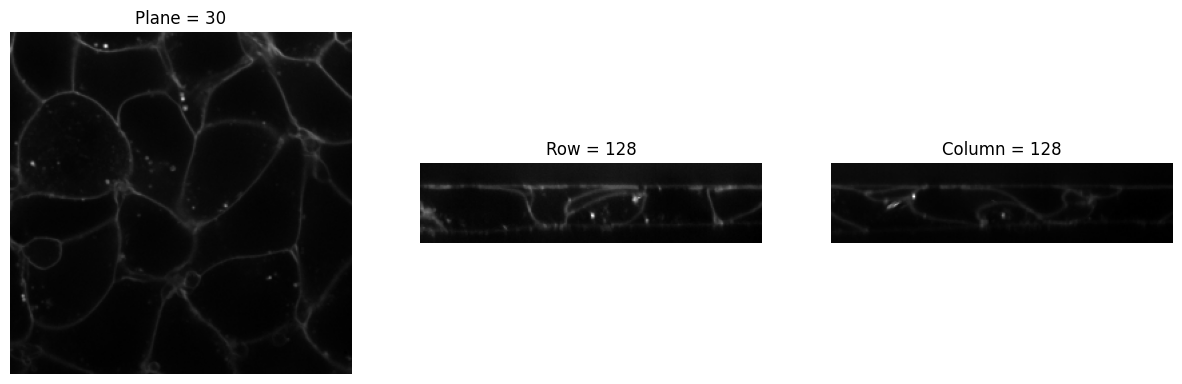

Standardized Output Size:
torch.Size([60, 150, 300])


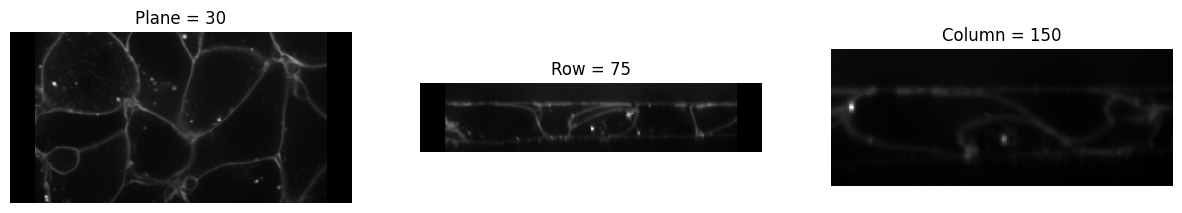

In [184]:
# Example: Forcing a specific absolute size regardless of the input dimensions
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Force an exact spatial size
# Suppose the original size is roughly 256x256.
# By requesting (150, 300), the transform will automatically CROP the Y-axis 
# down to 150, and PAD the X-axis up to 300, all in a single step.
standardize_tfm = ResizeWithPadOrCrop(spatial_size=(150, 300))
img2 = standardize_tfm(img)

print(f"Standardized Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [185]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_resize_pad_crop_logic():
    # Transform inheritance
    t = ResizeWithPadOrCrop(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to ResizeWithPadOrCrop
    t_monai = ResizeWithPadOrCrop(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.ResizeWithPadOrCrop), True)
    
    # Dict transform inference mapping to ResizeWithPadOrCropd
    t_dict = ResizeWithPadOrCrop(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.ResizeWithPadOrCropd), True)

    return "Passed"

test_eq(test_resize_pad_crop_logic(), "Passed")

### `ResizeWithPadOrCrop` Parameter Reference

This reference details the configurations used to force arrays into an exact spatial footprint.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native structural operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `int` | *Required* | The absolute target spatial dimensions (e.g., `(256, 256)`). An integer broadcasts to all spatial axes. Passed as a positional argument. |
| **`method`** | `str` | `"symmetric"` | The strategy used for both padding and cropping. Options include `"symmetric"` (centers the operation) or `"end"`. Passed via `**kwargs`. |
| **`mode`** | `str` | `"constant"` | The value-filling strategy used if padding is required. Options include `"constant"`, `"reflect"`, `"replicate"`, or `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`ResizeWithPadOrCropd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

### Spatial Orientation & Deformation

In [52]:
#| export
class Rotate(MonaiTransform):
    """
    MONAI Rotate wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate

    def __init__(
        self,
        angle=0.0,
        keys=None,
        **kwargs,
    ):

        self.angle = angle

        super().__init__(
            keys=keys,
            angle=angle, 
            **kwargs,
        )

In [187]:
show_doc(Rotate)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L776){target="_blank" style="float:right; font-size:smaller"}

### Rotate

```python

def Rotate(
    angle:float=0.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Rotate wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Rotate*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


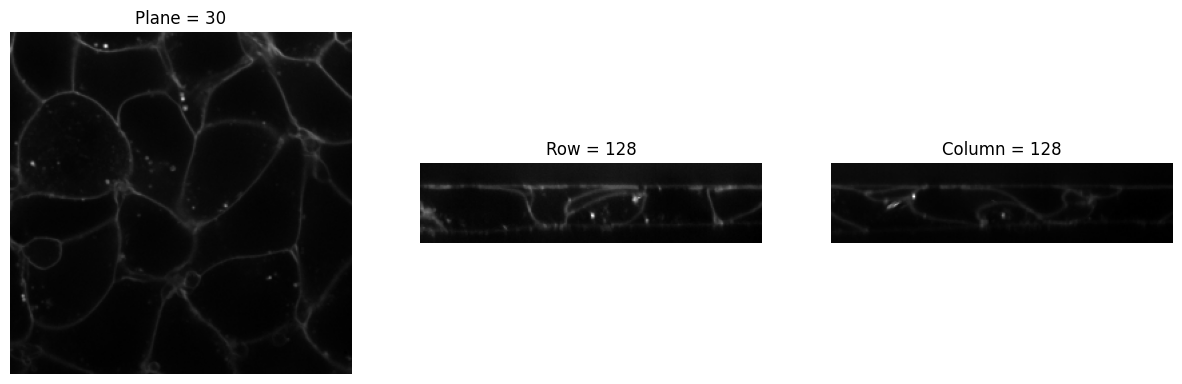

Rotated Output Size:
torch.Size([60, 362, 362])


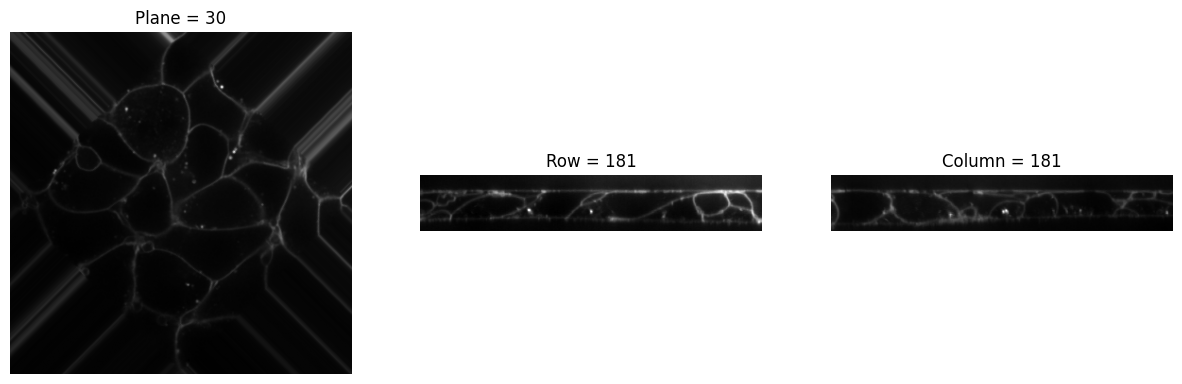

In [191]:
# Example: Rotating an image by 45 degrees
import numpy as np
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 45-degree rotation
# MONAI strictly expects angles in radians (45 degrees = pi/4).
# We set keep_size=False so the canvas expands to fit the rotated corners 
# without cropping the original biological signal.
rotate_tfm = Rotate(angle=np.pi/4, keep_size=False)
img2 = rotate_tfm(img)

print(f"Rotated Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [190]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt
import numpy as np

def test_rotate_logic():
    # Transform inheritance
    t = Rotate(angle=np.pi/4, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Rotate
    t_monai = Rotate(angle=np.pi, backend="monai")
    test_eq(isinstance(t_monai, mt.Rotate), True)
    
    # Dict transform inference mapping to Rotated
    t_dict = Rotate(angle=np.pi, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Rotated), True)

    return "Passed"

test_eq(test_rotate_logic(), "Passed")

### `Rotate` Parameter Reference

This reference details the configurations used to rotate arrays and handle coordinate grid interpolations.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`angle`** | `float` or `Sequence[float]` | `0.0` | The rotation angle(s) in **radians**. For 2D, a single float is used. For 3D, a sequence of up to 3 floats specifies rotation around each spatial axis. |
| **`keep_size`** | `bool` | `True` | If `True`, the output tensor matches the input shape (which might crop the corners). If `False`, the canvas expands to fit the entire rotated image. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode. Options typically include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling newly created empty spaces outside the rotated bounds. Options: `"zeros"`, `"border"`, `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Rotated`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [53]:
#| export
class Rotate90(MonaiTransform):
    """
    MONAI Rotate90 wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Rotate90*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Rotate90

    def __init__(
        self,
        spatial_axes=(0, 1),
        keys=None,
        **kwargs,
    ):

        self.spatial_axes = spatial_axes

        super().__init__(
            keys=keys,
            spatial_axes=spatial_axes, 
            **kwargs,
        )

In [192]:
show_doc(Rotate90)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L804){target="_blank" style="float:right; font-size:smaller"}

### Rotate90

```python

def Rotate90(
    spatial_axes:tuple=(0, 1), keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Rotate90 wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Rotate90*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


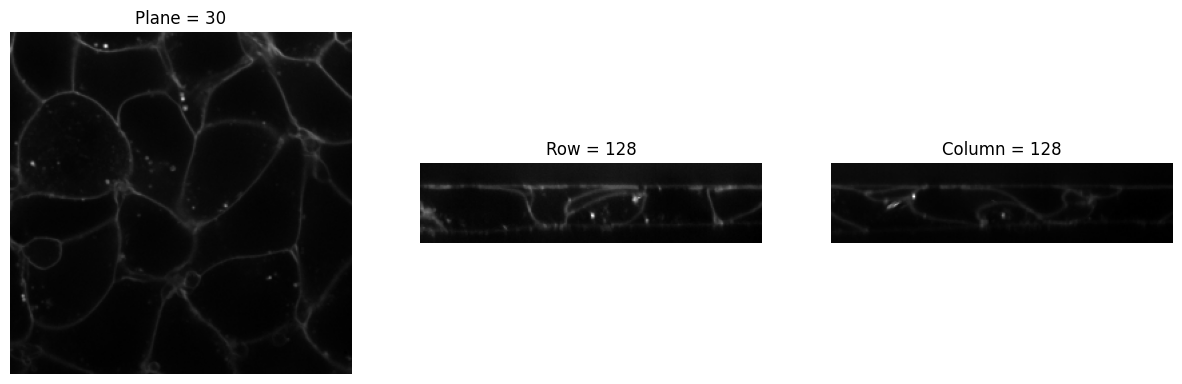

Rotate90 Output Size:
torch.Size([60, 256, 256])


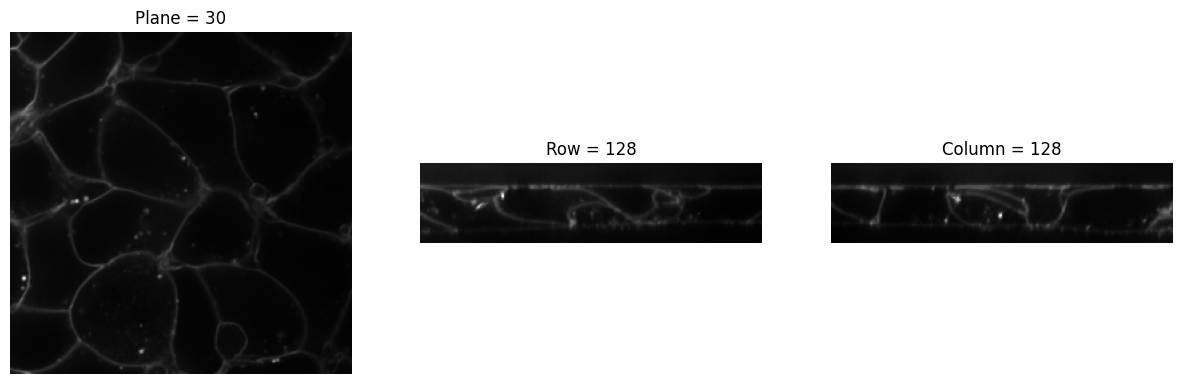

In [193]:
# Example: Fast, lossless 90-degree rotation
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 90-degree rotation in the spatial plane
# By default, it rotates 1 time (k=1) in the plane defined by axes (0, 1) -> Y, X.
# If we passed k=2, it would rotate 180 degrees.
rotate90_tfm = Rotate90(spatial_axes=(0, 1), k=1)
img2 = rotate90_tfm(img)

print(f"Rotate90 Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [194]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_rotate90_logic():
    # Transform inheritance
    t = Rotate90(spatial_axes=(0, 1), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Rotate90
    t_monai = Rotate90(spatial_axes=(1, 2), k=2, backend="monai")
    test_eq(isinstance(t_monai, mt.Rotate90), True)
    
    # Dict transform inference mapping to Rotate90d
    t_dict = Rotate90(spatial_axes=(0, 1), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Rotate90d), True)

    return "Passed"

test_eq(test_rotate90_logic(), "Passed")

### `Rotate90` Parameter Reference

This reference details the configurations used for fast, plane-specific right-angle rotations.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_axes`** | `tuple` | `(0, 1)` | The two spatial dimensions defining the plane of rotation. For a standard 2D image `[C, Y, X]`, the spatial axes are `(0, 1)`. |
| **`k`** | `int` | `1` | The number of times to rotate by 90 degrees. For example, `k=2` equals 180 degrees, `k=3` equals 270 degrees. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Rotate90d`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [54]:
#| export
class Zoom(MonaiTransform):
    """
    MONAI Zoom wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Zoom*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Zoom

    def __init__(
        self,
        zoom=1.0,
        keys=None,
        **kwargs,
    ):

        self.zoom = zoom

        super().__init__(
            keys=keys,
            zoom=zoom, 
            **kwargs,
        )

In [195]:
show_doc(Zoom)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L832){target="_blank" style="float:right; font-size:smaller"}

### Zoom

```python

def Zoom(
    zoom:float=1.0, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI Zoom wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Zoom*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


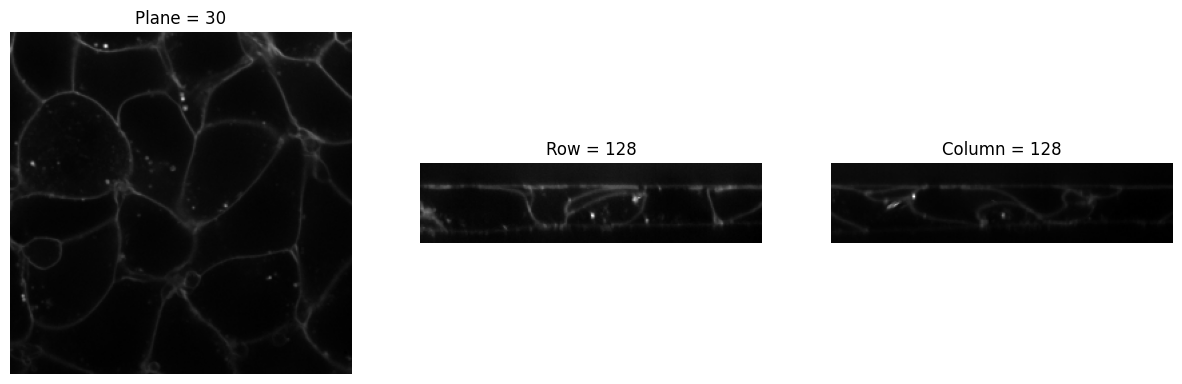

Zoomed Output Size (Notice it remains the same as the original):
torch.Size([60, 256, 256])


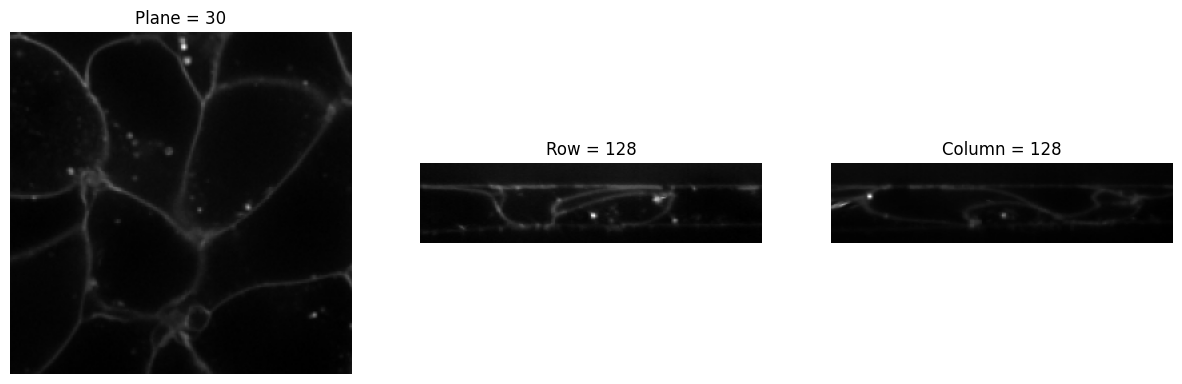

In [196]:
# Example: Applying a digital zoom to a biological sample
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a 1.5x zoom
# By keeping the default keep_size=True, the transform scales the image by 1.5x
# and then crops the boundaries, ensuring the final shape matches the original.
# If we set keep_size=False, the canvas would expand to fit the new zoomed dimensions.
zoom_tfm = Zoom(zoom=1.5)
img2 = zoom_tfm(img)

print(f"Zoomed Output Size (Notice it remains the same as the original):")
print(img2.size())
show_slices(img2, showlines=False)

In [197]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_zoom_logic():
    # Transform inheritance
    t = Zoom(zoom=1.2, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Zoom
    t_monai = Zoom(zoom=0.8, backend="monai")
    test_eq(isinstance(t_monai, mt.Zoom), True)
    
    # Dict transform inference mapping to Zoomd
    t_dict = Zoom(zoom=1.5, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Zoomd), True)

    return "Passed"

test_eq(test_zoom_logic(), "Passed")

### `Zoom` Parameter Reference

This reference details the configurations used to apply relative spatial scaling.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`zoom`** | `float` or `Sequence[float]` | `1.0` | The multiplier to scale the spatial dimensions. E.g., `1.5` increases size by 50%. A sequence allows different zoom factors for each axis. |
| **`keep_size`** | `bool` | `True` | If `True`, crops or pads the output to strictly match the input's original size. If `False`, the output tensor dimensions change based on the zoom factor. Passed via `**kwargs`. |
| **`mode`** | `str` | `"area"` / `"bilinear"` | Interpolation mode used to calculate new voxel values. Options include `"nearest"`, `"bilinear"`, `"bicubic"`, or `"area"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"constant"` | If zooming out (`zoom < 1.0`) with `keep_size=True`, defines how to fill the new empty borders. Options: `"constant"`, `"reflect"`, `"replicate"`, `"circular"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Zoomd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |

In [55]:
#| export
class Flip(MonaiTransform):
    """
    MONAI Flip wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Flip*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """

    _monai_transform = mt.Flip

In [198]:
show_doc(Flip)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L860){target="_blank" style="float:right; font-size:smaller"}

### Flip

```python

def Flip(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI Flip wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Flip*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


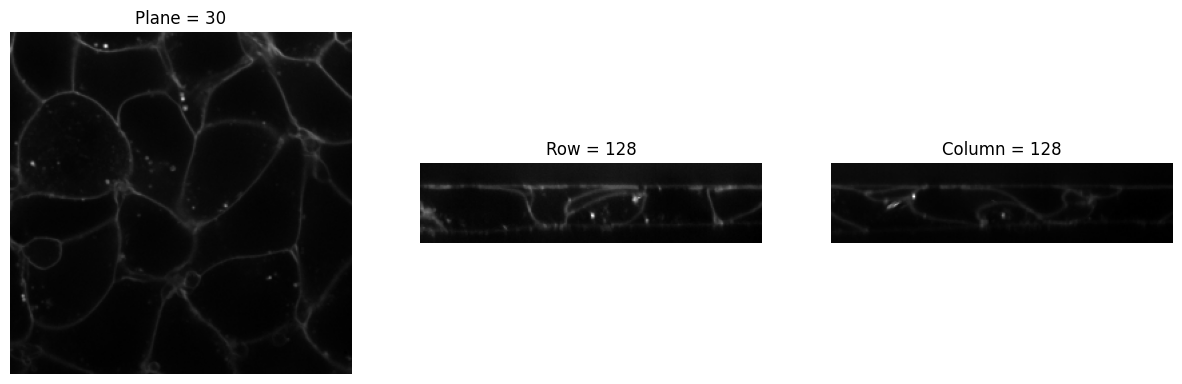

Flipped Output Size:
torch.Size([60, 256, 256])


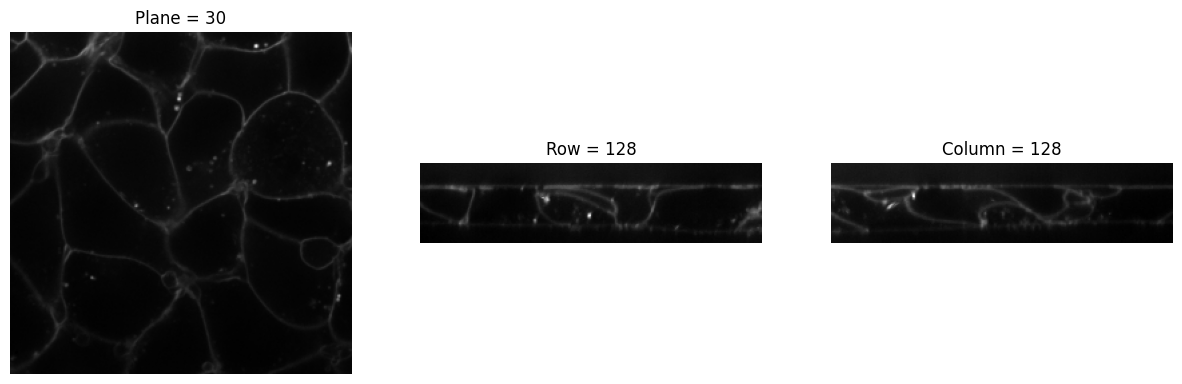

In [199]:
# Example: Mirroring an image horizontally (flipping along the X-axis)
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply a spatial flip
# Assuming spatial dimensions are (Y, X), axis 0 is Y (vertical), and axis 1 is X (horizontal).
# Passing spatial_axis=1 will flip the image horizontally (left-to-right).
# If spatial_axis=None (the default), it flips all spatial axes simultaneously.
flip_tfm = Flip(spatial_axis=1)
img2 = flip_tfm(img)

print(f"Flipped Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [200]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_flip_logic():
    # Transform inheritance
    t = Flip(spatial_axis=0, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Flip
    t_monai = Flip(spatial_axis=1, backend="monai")
    test_eq(isinstance(t_monai, mt.Flip), True)
    
    # Dict transform inference mapping to Flipd
    t_dict = Flip(spatial_axis=0, keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Flipd), True)

    return "Passed"

test_eq(test_flip_logic(), "Passed")

### `Flip` Parameter Reference

This reference details the configurations used to mirror tensors along specific axes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_axis`** | `int`, `tuple`, or `None` | `None` | The spatial axis (or axes) to flip along. If `None`, it flips all spatial dimensions simultaneously. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Flipd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [56]:
#| export
class GridPatch(MonaiTransform):
    """
    MONAI GridPatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridPatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridPatch

    def __init__(
        self,
        patch_size=None,
        keys=None,
        **kwargs,
    ):

        self.patch_size = patch_size

        super().__init__(
            keys=keys,
            patch_size=patch_size, 
            **kwargs,
        )

In [201]:
show_doc(GridPatch)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L874){target="_blank" style="float:right; font-size:smaller"}

### GridPatch

```python

def GridPatch(
    patch_size:NoneType=None, keys:NoneType=None, kwargs:VAR_KEYWORD
):


```

*MONAI GridPatch wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (GridPatch*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


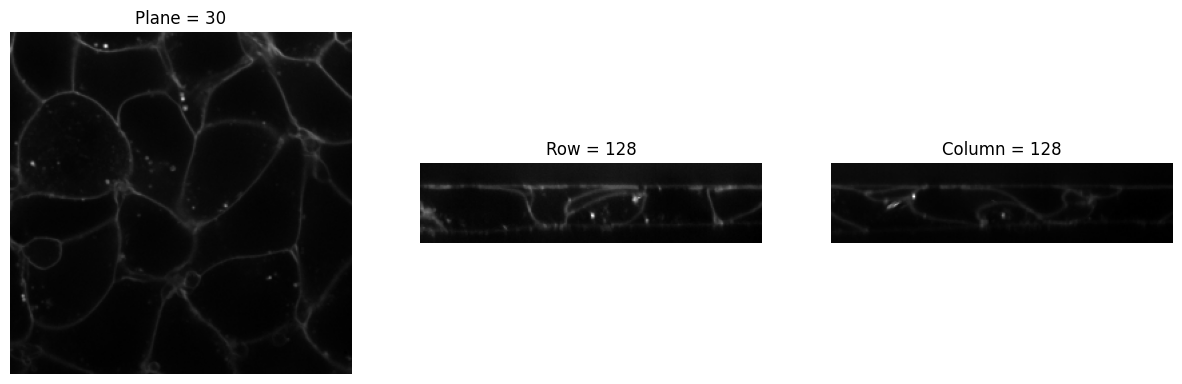

Generated a grid of 16 patches.
Shape of the first extracted patch: torch.Size([60, 64, 64])


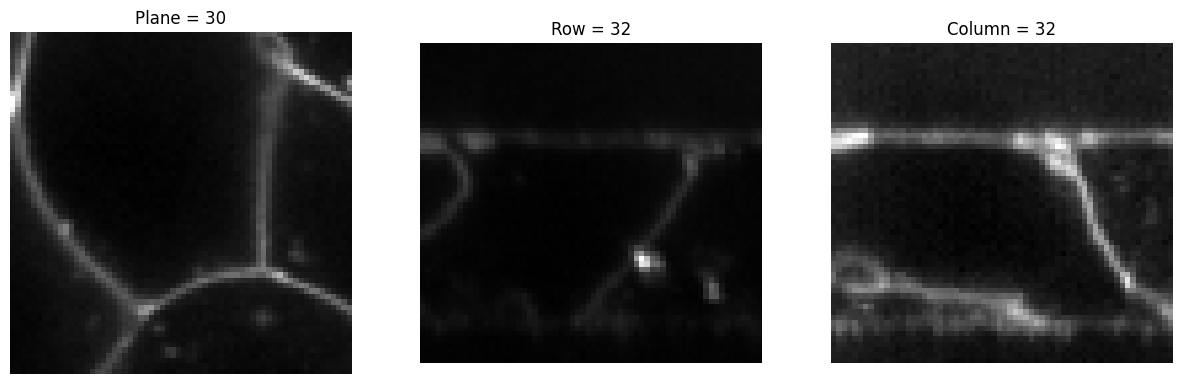

In [202]:
# Example: Decomposing a large image into a grid of smaller patches
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the GridPatch operation
# We divide the image into smaller spatial patches of 64x64.
# The transform returns a generator/iterable, so we convert it to a list.
grid_tfm = GridPatch(patch_size=(64, 64))
patches = list(grid_tfm(img))

print(f"Generated a grid of {len(patches)} patches.")
print(f"Shape of the first extracted patch: {patches[0].shape}")

# Visualize just the very first patch of the grid
show_slices(patches[0], showlines=False)

In [203]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_grid_patch_logic():
    # Transform inheritance
    t = GridPatch(patch_size=(32, 32), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to GridPatch
    t_monai = GridPatch(patch_size=(16, 16), backend="monai")
    test_eq(isinstance(t_monai, mt.GridPatch), True)
    
    # Dict transform inference mapping to GridPatchd
    t_dict = GridPatch(patch_size=(16, 16), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.GridPatchd), True)

    return "Passed"

test_eq(test_grid_patch_logic(), "Passed")

### `GridPatch` Parameter Reference

This reference details the configurations used to decompose large arrays into manageable grids.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native patching operator (`backend="monai"`). *Note: The runtime output is an iterable of patched tensors.*

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`patch_size`** | `tuple` | *Required* | The absolute spatial dimensions for each generated patch (e.g., `(64, 64)`). Passed as a positional argument. |
| **`overlap`** | `float` or `tuple` | `0.0` | The amount of overlap between adjacent patches, expressed as a fraction of the patch size (e.g., `0.5` means 50% overlap). Passed via `**kwargs`. |
| **`pad_mode`** | `str` | `"constant"` | If the original image is not perfectly divisible by the patch size, dictates how to pad the boundaries. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`GridPatchd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [57]:
#| export
class GridSplit(MonaiTransform):
    """
    MONAI GridSplit wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridSplit*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridSplit

In [204]:
show_doc(GridSplit)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L902){target="_blank" style="float:right; font-size:smaller"}

### GridSplit

```python

def GridSplit(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI GridSplit wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (GridSplit*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


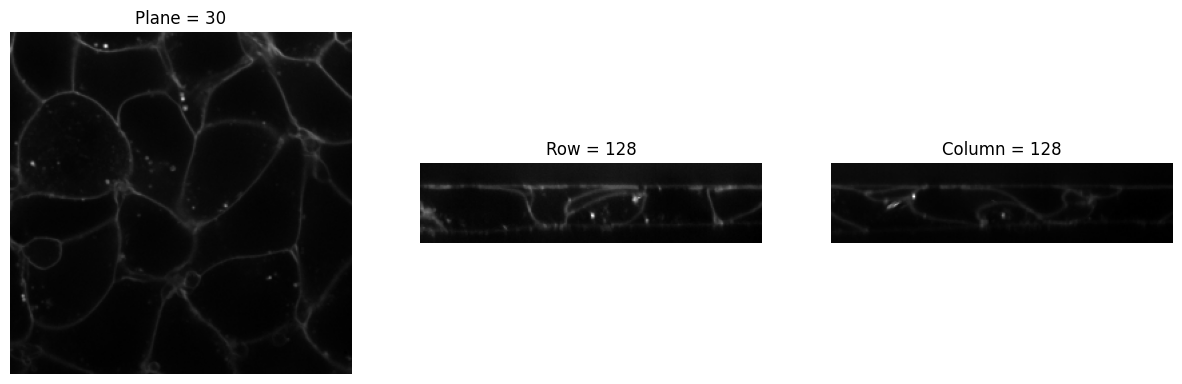

Generated a grid of 4 patches.
Shape of the first extracted patch: torch.Size([60, 128, 128])


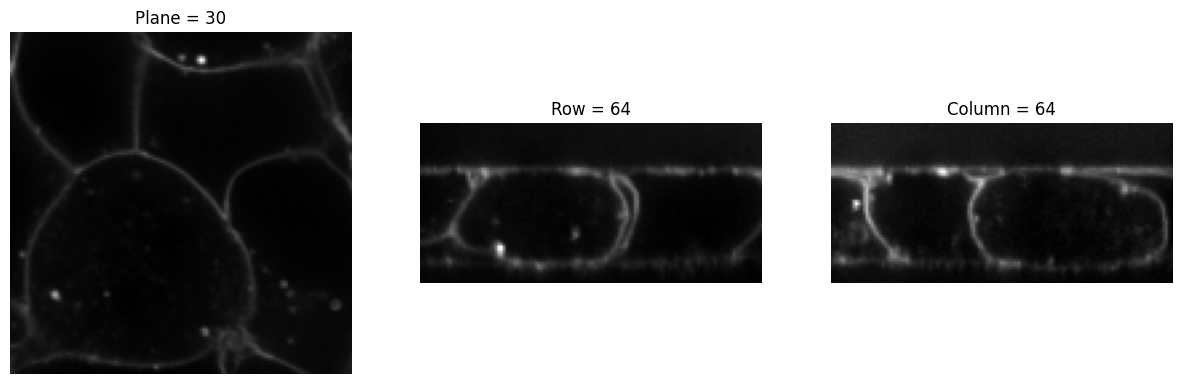

In [205]:
# Example: Splitting an image into a 2x2 grid of proportional patches
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply the GridSplit operation
# We ask the transform to divide the spatial canvas into a 2x2 grid.
# This will yield 4 evenly divided patches (top-left, top-right, bottom-left, bottom-right).
# The transform returns a generator/iterable, so we convert it to a list.
grid_tfm = GridSplit(grid=(2, 2))
patches = list(grid_tfm(img))

print(f"Generated a grid of {len(patches)} patches.")
print(f"Shape of the first extracted patch: {patches[0].shape}")

# Visualize just the very first segment of the split (Top-Left)
show_slices(patches[0], showlines=False)

In [206]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_gridsplit_logic():
    # Transform inheritance
    t = GridSplit(grid=(2, 2), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to GridSplit
    t_monai = GridSplit(grid=(3, 3), backend="monai")
    test_eq(isinstance(t_monai, mt.GridSplit), True)
    
    # Dict transform inference mapping to GridSplitd
    t_dict = GridSplit(grid=(2, 2), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.GridSplitd), True)

    return "Passed"

test_eq(test_gridsplit_logic(), "Passed")

### `GridSplit` Parameter Reference

This reference details the configurations used to divide an array into fixed proportional segments.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native splitting operator (`backend="monai"`). *Note: The runtime output is an iterable of split tensors.*

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`grid`** | `tuple` or `None` | `None` | The number of splits along each spatial dimension (e.g., `(2, 2)` splits a 2D image into 4 patches). Passed via `**kwargs`. |
| **`size`** | `tuple` or `None` | `None` | The absolute size of each split chunk. You must provide either `grid` or `size` (but not both). Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`GridSplitd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [209]:
#| export
class _StaticSpatialResample(mt.SpatialResample):
    """Internal patch to allow static initialization of spatial_size and dst_affine."""
    def __init__(self, spatial_size=None, dst_affine=None, **kwargs):
        super().__init__(**kwargs)
        self.spatial_size = spatial_size
        self.dst_affine = dst_affine
        
    def __call__(self, img, **kwargs):
        # Inject our static parameters automatically during the pipeline execution
        kwargs.setdefault("spatial_size", self.spatial_size)
        kwargs.setdefault("dst_affine", self.dst_affine)
        return super().__call__(img, **kwargs)

class _StaticSpatialResampled(mt.SpatialResampled):
    """Internal patch for dictionary-based static initialization."""
    def __init__(self, keys, spatial_size=None, dst_affine=None, **kwargs):
        super().__init__(keys, **kwargs)
        self.spatial_size = spatial_size
        self.dst_affine = dst_affine
        
    def __call__(self, data, **kwargs):
        kwargs.setdefault("spatial_size", self.spatial_size)
        kwargs.setdefault("dst_affine", self.dst_affine)
        return super().__call__(data, **kwargs)

class SpatialResample(MonaiTransform):
    """
    MONAI SpatialResample wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (SpatialResample*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _StaticSpatialResample

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # Override to ensure the dict inference uses our patched dictionary subclass
        return _StaticSpatialResampled(keys, *args, **kwargs)

In [207]:
show_doc(SpatialResample)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L915){target="_blank" style="float:right; font-size:smaller"}

### SpatialResample

```python

def SpatialResample(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI SpatialResample wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (SpatialResample*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([60, 256, 256])


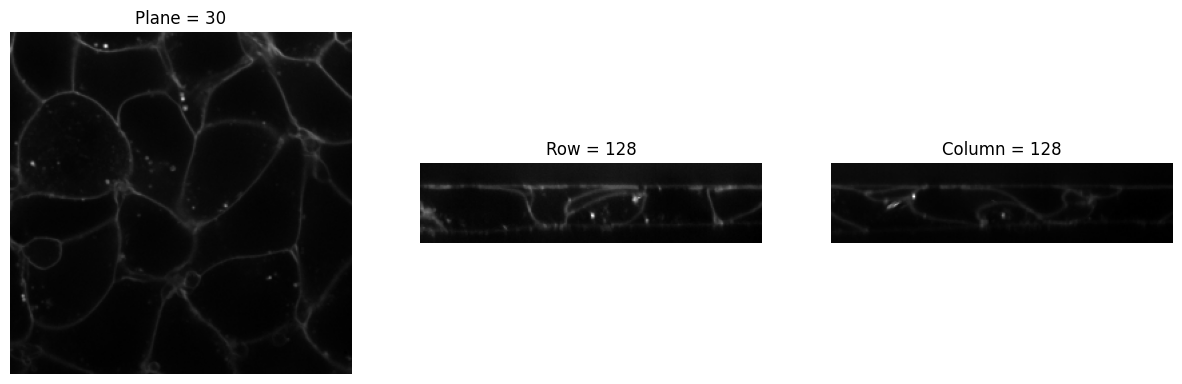

Resampled Output Size:
torch.Size([60, 128, 128])


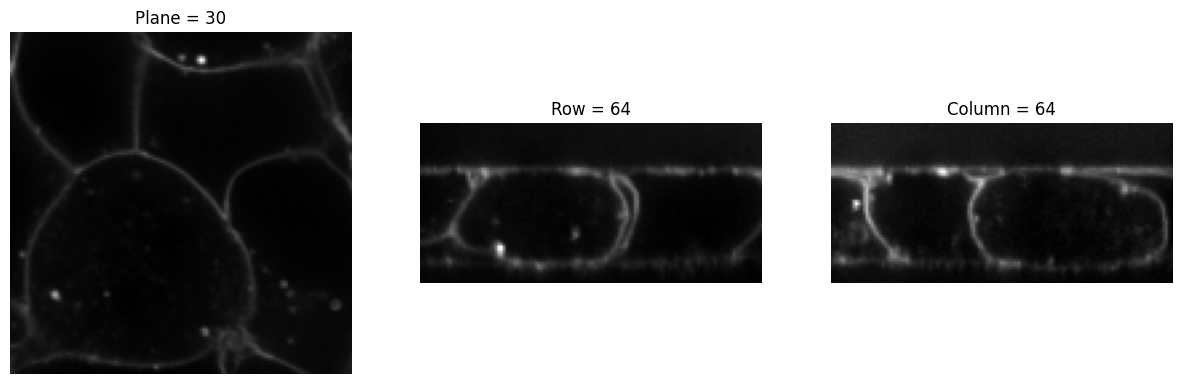

In [210]:
# Example: Resampling the spatial coordinate grid of an image
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base image (Shape: [Channels, Y, X])
img = BioVolume(torchTensor(cells3d()[:,0]))
print(f"Original Input Size: {img.shape}")
show_slices(img, showlines=False)

# 2. Apply Spatial Resampling
# We force the image to resample its coordinate grid to a new 128x128 footprint.
# Unlike a standard 'Resize', SpatialResample can also accept complex target affine matrices.
resample_tfm = SpatialResample(spatial_size=(128, 128))
img2 = resample_tfm(img)

print(f"Resampled Output Size:")
print(img2.size())
show_slices(img2, showlines=False)

In [211]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_spatial_resample_logic():
    # Transform inheritance
    t = SpatialResample(spatial_size=(64, 64), backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to SpatialResample
    t_monai = SpatialResample(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.SpatialResample), True)
    
    # Dict transform inference mapping to SpatialResampled
    t_dict = SpatialResample(spatial_size=(32, 32), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.SpatialResampled), True)

    return "Passed"

test_eq(test_spatial_resample_logic(), "Passed")

### `SpatialResample` Parameter Reference

This reference details the configurations used to recalculate the physical or spatial grid of the array.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`spatial_size`** | `tuple`, `list`, or `None` | `None` | The target spatial dimensions to resample into (e.g., `(128, 128)`). Explicitly supported during initialization via our static patch. |
| **`dst_affine`** | `array-like` or `None` | `None` | The target affine matrix defining the new coordinate space. Explicitly supported during initialization via our static patch. |
| **`mode`** | `str` | `"bilinear"` | The interpolation mode used to estimate the new grid values. Options typically include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling out-of-bounds pixels during resampling. Options include `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`SpatialResampled`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `align_corners`). |

In [59]:
#| export
class ResampleToMatch(MonaiTransform):
    """
    MONAI ResampleToMatch wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (ResampleToMatch*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.ResampleToMatch

In [212]:
show_doc(ResampleToMatch)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L928){target="_blank" style="float:right; font-size:smaller"}

### ResampleToMatch

```python

def ResampleToMatch(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI ResampleToMatch wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (ResampleToMatch*d auto-inferred)
- BioImageBase
- NumPy arrays

Mismatched Shapes -> Image: torch.Size([60, 256, 256]), Mask: torch.Size([60, 64, 64])
Matched Shapes    -> Image: torch.Size([60, 256, 256]), Mask: torch.Size([60, 256, 256])


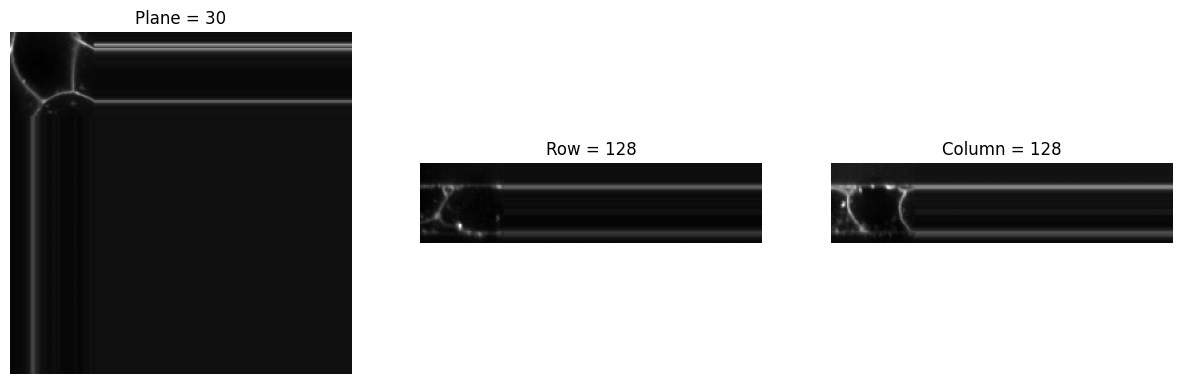

In [213]:
# Example: Aligning a low-res mask to perfectly match a high-res image grid
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Let's simulate a scenario with mismatched spatial resolutions
img_high_res = BioVolume(torchTensor(cells3d()[:,0]))

# Create an artificially smaller "mask" to simulate mismatched acquisition
mismatched_mask = SpatialResample(spatial_size=(64, 64))(img_high_res) 

# Package them into a dictionary representing a single patient's data
data_dict = {"image": img_high_res, "mask": mismatched_mask}

print(f"Mismatched Shapes -> Image: {data_dict['image'].shape}, Mask: {data_dict['mask'].shape}")

# 2. Apply dictionary-based ResampleToMatch
# We configure it to resample the 'mask' using the 'image' as the spatial reference.
# We use mode="nearest" to preserve discrete class values in masks.
match_tfm = ResampleToMatch(keys=["mask"], key_dst="image", mode="nearest")
matched_dict = match_tfm(data_dict)

print(f"Matched Shapes    -> Image: {matched_dict['image'].shape}, Mask: {matched_dict['mask'].shape}")
show_slices(matched_dict['mask'], showlines=False)

In [214]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_resample_to_match_logic():
    # Transform inheritance
    t = ResampleToMatch(backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to ResampleToMatch
    t_monai = ResampleToMatch(backend="monai")
    test_eq(isinstance(t_monai, mt.ResampleToMatch), True)
    
    # Dict transform inference mapping to ResampleToMatchd
    # Note: 'key_dst' is required by MONAI to point to the reference dictionary key
    t_dict = ResampleToMatch(keys=["mask"], key_dst="image", backend="monai")
    test_eq(isinstance(t_dict, mt.ResampleToMatchd), True)

    return "Passed"

test_eq(test_resample_to_match_logic(), "Passed")

### `ResampleToMatch` Parameter Reference

This reference details the configurations used to align and interpolate arrays to a reference grid.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`keys`** | `list[str]` or `None` | `None` | Identifiers triggering the dictionary-based counterpart (`ResampleToMatchd`). Defines which arrays will be resampled. |
| **`key_dst`** | `str` | `None` | **Required if using `keys`.** The dictionary key pointing to the reference image. The transform will extract its spatial metadata to govern the resampling. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode used for resampling. E.g., use `"nearest"` for segmentation masks or `"bilinear"`/`"bicubic"` for images. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"border"` | Strategy for filling out-of-bounds pixels during resampling. Options include `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [226]:
#| export
import warnings
import monai.transforms as mt

class _QuietOrientation(mt.Orientation):
    """Internal patch to suppress MONAI's FutureWarning regarding labels."""
    def __init__(self, *args, **kwargs):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            super().__init__(*args, **kwargs)

class _QuietOrientationd(mt.Orientationd):
    """Internal patch to suppress MONAI's FutureWarning for dictionary inputs."""
    def __init__(self, *args, **kwargs):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore", FutureWarning)
            super().__init__(*args, **kwargs)


class Orientation(MonaiTransform):
    """
    MONAI Orientation wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Orientation*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _QuietOrientation

    @classmethod
    def _create_dict_transform(cls, keys, *args, **kwargs):
        # Override to ensure the dict inference uses our quiet dictionary subclass
        return _QuietOrientationd(keys, *args, **kwargs)

In [227]:
show_doc(Orientation)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L941){target="_blank" style="float:right; font-size:smaller"}

### Orientation

```python

def Orientation(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI Orientation wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Orientation*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([1, 60, 256, 256])


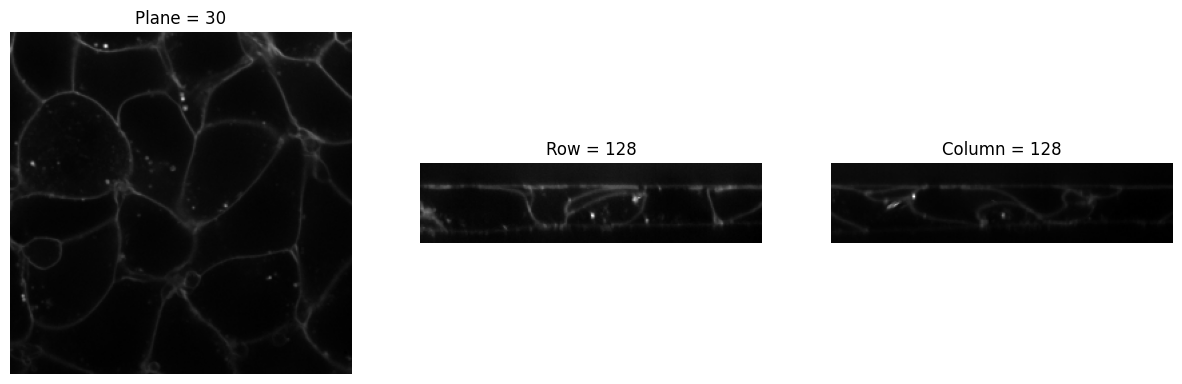

Re-oriented Output Size:
torch.Size([1, 60, 256, 256])


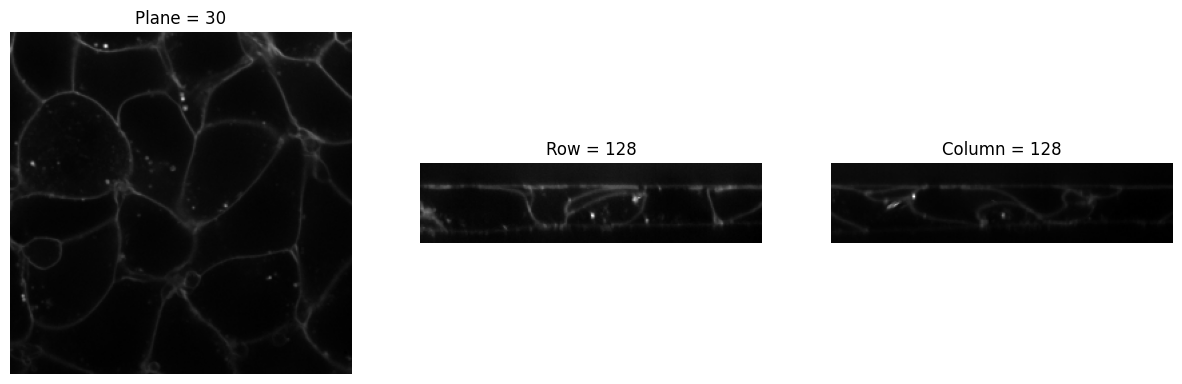

In [231]:
# Example: Standardizing the physical orientation of a volume
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume (Shape: [Channels, Z, Y, X])
# cells3d()[:,0] gives us [60, 256, 256] (Z, Y, X).
# We use .unsqueeze(0) to explicitly add the Channel dimension -> [1, 60, 256, 256]
img = BioVolume(torchTensor(cells3d()[:,0]).unsqueeze(0))
print(f"Original Input Size: {img.shape}")

# show_slices strictly expects a 3D spatial volume. 
# We pass img[0] to temporarily strip the channel dimension for plotting.
show_slices(img[0], showlines=False)

# 2. Apply Anatomical Orientation
# We specify the target orientation using axis codes.
# 'RAS' is a very common 3D standard representing Right, Anterior, Superior.
# The transform automatically calculates the necessary transpositions/flips 
# to rearrange the spatial axes into this specific coordinate space.
orientation_tfm = Orientation(axcodes="RAS")
img2 = orientation_tfm(img)

print(f"Re-oriented Output Size:")
print(img2.size())

# Again, strip the channel dimension for the final visualization
show_slices(img2[0], showlines=False)

In [229]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt

def test_orientation_logic():
    # Transform inheritance
    t = Orientation(axcodes="RAS", backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Orientation
    t_monai = Orientation(axcodes="LPS", backend="monai")
    test_eq(isinstance(t_monai, mt.Orientation), True)
    
    # Dict transform inference mapping to Orientationd
    t_dict = Orientation(axcodes="RAS", keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Orientationd), True)

    return "Passed"

test_eq(test_orientation_logic(), "Passed")

### `Orientation` Parameter Reference

This reference details the configurations used to align physical spatial axes to standardized anatomical codes.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native orientation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`axcodes`** | `str` | `None` | The target axis codes representing the desired physical orientation (e.g., `"RAS"`, `"LPS"`, `"SPL"`). Passed via `**kwargs`. |
| **`as_closest_canonical`** | `bool` | `False` | If `True`, ignores the specific `axcodes` and automatically snaps the orientation to the closest standard canonical orientation (like RAS). Passed via `**kwargs`. |
| **`labels`** | `tuple` | `None` | Optional identifiers for the original spatial dimensions if the affine metadata is missing. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Orientationd`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator. |

In [61]:
#| export
class Affine(MonaiTransform):
    """
    MONAI Affine wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (Affine*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.Affine

In [232]:
show_doc(Affine)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L954){target="_blank" style="float:right; font-size:smaller"}

### Affine

```python

def Affine(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI Affine wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- dict (Affine*d auto-inferred)
- BioImageBase
- NumPy arrays

Original Input Size: torch.Size([1, 60, 256, 256])


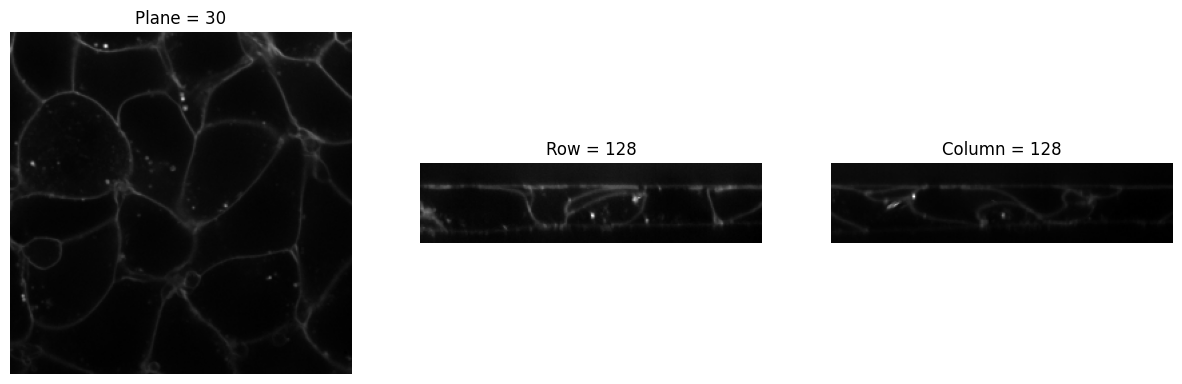

Affine Output Size:
torch.Size([1, 60, 256, 256])


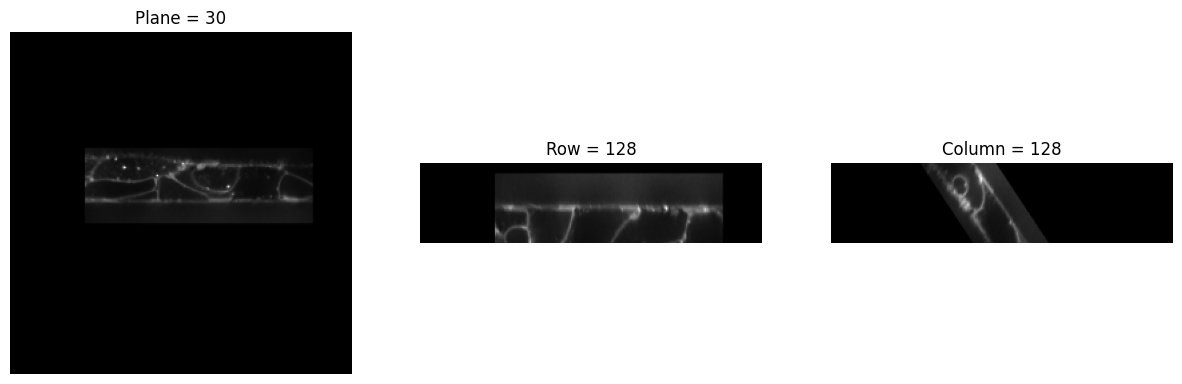

In [234]:
# Example: Applying a combined Rotate + Scale + Translate in a single pass
import numpy as np
from bioMONAI.datasets import cells3d
from bioMONAI.visualize import show_slices

# 1. Initialize the base volume (Shape: [Channels, Z, Y, X])
# We explicitly add the Channel dimension -> [1, 60, 256, 256]
img = BioVolume(torchTensor(cells3d()[:,0]).unsqueeze(0))
print(f"Original Input Size: {img.shape}")
show_slices(img[0], showlines=False)

# 2. Apply a complex Affine transformation
# Since our volume has 3 spatial dimensions (Z, Y, X), we pass a tuple of 3 values.
# - No change to Z (axis 0)
# - Rotate 45 degrees (pi/4) in the YX plane
# - Scale Y and X by 1.5x (zoom in)
# - Translate/shift Y by 20 pixels and X by -20 pixels
# IMPORTANT: image_only=True forces MONAI to return just the tensor, not the affine matrix tuple
affine_tfm = Affine(
    rotate_params=(0.0, 0.0, np.pi/4),
    scale_params=(1.0, 1.5, 1.5),
    translate_params=(0, 20, -20),
    padding_mode="zeros",
    image_only=True
)

img2 = affine_tfm(img)

print(f"Affine Output Size:")
print(img2.size())

# Strip the channel dimension for the final visualization
show_slices(img2[0], showlines=False)

In [235]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt
import numpy as np

def test_affine_logic():
    # Transform inheritance
    t = Affine(rotate_params=np.pi/4, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to Affine
    t_monai = Affine(scale_params=1.5, backend="monai")
    test_eq(isinstance(t_monai, mt.Affine), True)
    
    # Dict transform inference mapping to Affined
    t_dict = Affine(translate_params=(10, 10), keys=["image"], backend="monai")
    test_eq(isinstance(t_dict, mt.Affined), True)

    return "Passed"

test_eq(test_affine_logic(), "Passed")

### `Affine` Parameter Reference

This reference details the configurations used to build and apply multi-dimensional affine matrices.

**Returns:** A fastai-compatible augmentation wrapper (`backend="fastai"`) or a native deformation operation (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`affine`** | `array-like` | `None` | A custom square matrix (e.g., 3x3 for 2D, 4x4 for 3D) defining the exact mathematical transformation. Passed via `**kwargs`. |
| **`rotate_params`** | `float` or `Sequence` | `None` | Rotation angles in **radians**. For 3D, a sequence of 3 floats specifies rotation around the Z, Y, and X axes. Passed via `**kwargs`. |
| **`scale_params`** | `float` or `Sequence` | `None` | Scale multipliers (e.g., `1.5` increases size by 50%). Passed via `**kwargs`. |
| **`translate_params`**| `float` or `Sequence` | `None` | Translation offsets in pixels/voxels. Passed via `**kwargs`. |
| **`shear_params`** | `float` or `Sequence` | `None` | Shearing factors for the spatial axes. Passed via `**kwargs`. |
| **`spatial_size`** | `tuple` | `None` | The absolute target output size. If `None`, the output retains the input's spatial dimensions. Passed via `**kwargs`. |
| **`mode`** | `str` | `"bilinear"` | Interpolation mode used to calculate new voxel values. Options include `"nearest"`, `"bilinear"`, or `"bicubic"`. Passed via `**kwargs`. |
| **`padding_mode`** | `str` | `"reflection"`| Strategy for filling empty spaces created by the deformation. Options: `"zeros"`, `"border"`, or `"reflection"`. Passed via `**kwargs`. |
| **`keys`** | `list[str]` or `None` | `None` | Optional identifiers triggering the dictionary-based counterpart (`Affined`). |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `image_only`). |

In [241]:
#| export
import monai.transforms as mt

class _StaticAffineGrid(mt.AffineGrid):
    """Internal patch to allow static initialization of spatial_size."""
    def __init__(self, spatial_size=None, **kwargs):
        super().__init__(**kwargs)
        self.spatial_size = spatial_size
        
    def __call__(self, spatial_size=None, **kwargs):
        # If spatial_size is passed during the call (dynamic), use it.
        # Otherwise, fall back to the one defined during __init__ (static).
        target_size = spatial_size if spatial_size is not None else self.spatial_size
        return super().__call__(spatial_size=target_size, **kwargs)

class AffineGrid(MonaiTransform):
    """
    MONAI AffineGrid wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = _StaticAffineGrid

In [242]:
show_doc(AffineGrid)

---

[source](https://github.com/deepCLEM/bioMONAI/blob/main/bioMONAI/transforms.py#L967){target="_blank" style="float:right; font-size:smaller"}

### AffineGrid

```python

def AffineGrid(
    args:VAR_POSITIONAL, keys:NoneType=None, backend:str='fastai', kwargs:VAR_KEYWORD
):


```

*MONAI AffineGrid wrapper using MonaiTransform.*

Supports:
- MetaTensor (preserves spatial metadata)
- BioImageBase
- NumPy arrays

In [243]:
# Example: Generating a mathematical deformation grid
import numpy as np

# 1. Initialize the grid generator
# We configure it to apply a 45-degree rotation (pi/4 radians).
grid_tfm = AffineGrid(rotate_params=(np.pi/4,))

# 2. Generate the coordinate grid
# IMPORTANT: We pass the size as a LIST [64, 64], not a tuple.
# If we pass a tuple (64, 64), fastai assumes it's a multimodal batch (like image & mask)
# and tries to process the numbers 64 and 64 separately!
output = grid_tfm([64, 64])

# AffineGrid returns a tuple of (grid, affine_matrix). We safely extract the grid [0].
deformation_grid = output[0] if isinstance(output, tuple) else output

print(f"Deformation Grid Output Size:")
print(deformation_grid.size())

# For a 2D spatial size (64, 64), it returns a tensor of shape [2, 64, 64].
# The 2 channels represent the independent X and Y coordinate shifts for every pixel.

Deformation Grid Output Size:
torch.Size([3, 64, 64])


In [244]:
#| hide
from fastcore.test import test_eq
from fasttransform import Transform
import monai.transforms as mt
import numpy as np

def test_affine_grid_logic():
    # Transform inheritance
    t = AffineGrid(rotate_params=np.pi/4, backend="fastai")
    test_eq(isinstance(t, Transform), True)
    
    # Backend interception mapping to AffineGrid
    t_monai = AffineGrid(spatial_size=(32, 32), backend="monai")
    test_eq(isinstance(t_monai, mt.AffineGrid), True)
    
    # NOTE: We explicitly omit the dictionary inference test here because 
    # AffineGrid does not process data dictionaries, and mt.AffineGridd does not exist.

    return "Passed"

test_eq(test_affine_grid_logic(), "Passed")

### `AffineGrid` Parameter Reference

This reference details the configurations used to generate mathematical deformation coordinate maps.

**Returns:** A fastai-compatible wrapper (`backend="fastai"`) or a native grid generator (`backend="monai"`).

| Parameter | Type | Default | Details |
| :--- | :--- | :--- | :--- |
| **`affine`** | `array-like` | `None` | A custom square matrix defining the exact mathematical transformation. Passed via `**kwargs`. |
| **`rotate_params`** | `float` or `Sequence` | `None` | Rotation angles in **radians**. For 3D grids, a sequence of 3 floats. Passed via `**kwargs`. |
| **`scale_params`** | `float` or `Sequence` | `None` | Scale multipliers (e.g., `1.5` for zooming in). Passed via `**kwargs`. |
| **`translate_params`**| `float` or `Sequence` | `None` | Translation offsets in pixels/voxels. Passed via `**kwargs`. |
| **`shear_params`** | `float` or `Sequence` | `None` | Shearing factors for the spatial axes. Passed via `**kwargs`. |
| **`spatial_size`** | `tuple` or `list` | `None` | The absolute target output size for the grid. **Explicitly supported during initialization via our static patch**, or can be passed dynamically during execution. |
| **`backend`** | `str` | `"monai"` | Execution context flag. Set to `"fastai"` for the dynamic pipeline wrapper. |
| **`**kwargs`** | `dict` | `{}` | Additional properties forwarded directly to the MONAI base operator (e.g., `device`, `align_corners`). |

*(Note: The `keys` parameter is intentionally omitted from this transform because a dictionary counterpart does not exist in the MONAI library for grid generation).*

In [261]:
#| export
class GridDistortion(MonaiTransform):
    """
    MONAI GridDistortion wrapper using MonaiTransform.

    Supports:
    - MetaTensor (preserves spatial metadata)
    - dict (GridDistortion*d auto-inferred)
    - BioImageBase
    - NumPy arrays
    """
    _monai_transform = mt.GridDistortion

### Noise & Intensity Shift

In [64]:
#| export
class GaussianSmooth(MonaiTransform):
    """
    Apply Gaussian smoothing to the input image.

    Parameters
    ----------
    sigma : float or sequence
        Standard deviation of the Gaussian kernel.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSmooth

    def __init__(self, sigma=1.0, approx="erf", **kwargs):
        super().__init__(
            sigma=sigma,
            approx=approx,
            **kwargs
        )


class MedianSmooth(MonaiTransform):
    """
    Apply median filtering to the input image.

    Parameters
    ----------
    radius : int or sequence
        Radius of the median filter kernel.
    """
    _monai_transform = mt.MedianSmooth

    def __init__(self, radius=1, **kwargs):
        super().__init__(
            radius=radius,
            **kwargs
        )


class SavitzkyGolaySmooth(MonaiTransform):
    """
    Smooth data using a Savitzky-Golay filter.

    Parameters
    ----------
    window_length : int
        Length of the filter window.
    order : int
        Polynomial order.
    axis : int
        Axis along which smoothing is applied.
    mode : str
        Padding mode.
    """
    _monai_transform = mt.SavitzkyGolaySmooth

    def __init__(self, window_length, order, axis=1, mode="zeros", **kwargs):
        super().__init__(
            window_length=window_length,
            order=order,
            axis=axis,
            mode=mode,
            **kwargs
        )

In [65]:
#| export
Blur = GaussianSmooth

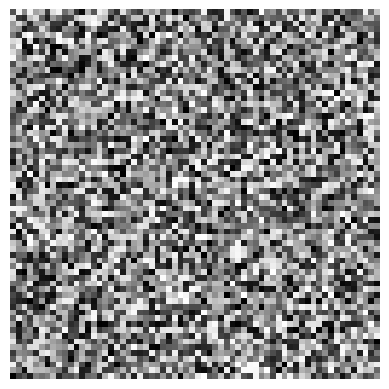

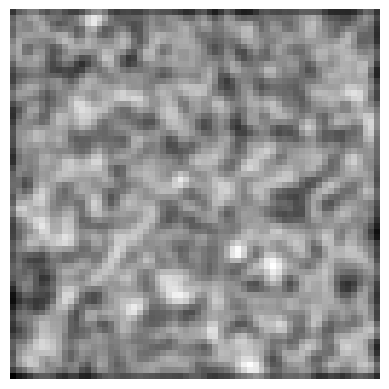

In [66]:
# Generate a random NumPy array 
random_array = np.random.rand(1, 64, 64)
# Apply Blur transform to the image
blur_transform = Blur() 
blurred_nparray = blur_transform(random_array)

# plot the original image
show_image(random_array)
# Plot the blurred image
show_image(blurred_nparray)

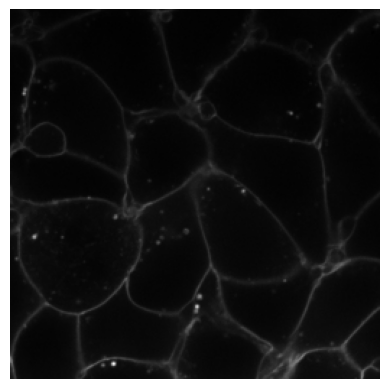

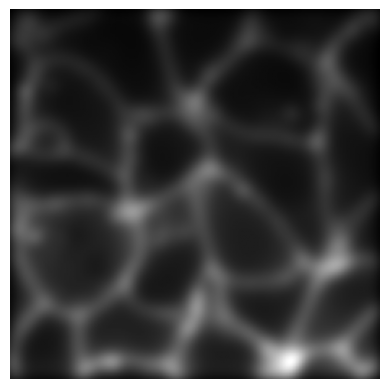

In [67]:
# Apply Blur transform to the image
blur_transform = Blur(sigma=5) 
sharp_img = blur_transform(img)

# plot the original image
show_image(img)
# Plot the blurred image
show_image(sharp_img)

In [68]:
#| export
class GaussianSharpen(MonaiTransform):
    """
    Sharpen images using Gaussian filtering.

    Parameters
    ----------
    sigma1 : float or sequence
        Sigma of the first Gaussian kernel.
    sigma2 : float or sequence
        Sigma of the second Gaussian kernel.
    alpha : float
        Sharpening strength.
    approx : str
        Kernel approximation method.
    """
    _monai_transform = mt.GaussianSharpen

    def __init__(self, sigma1=3.0, sigma2=1.0, alpha=30.0, approx="erf", **kwargs):
        super().__init__(
            sigma1=sigma1,
            sigma2=sigma2,
            alpha=alpha,
            approx=approx,
            **kwargs
        )

In [69]:
# | export

class ShiftIntensity(MonaiTransform):
    """
    Shift the intensity values of the entire image by a constant offset.

    This transform uniformly adds an offset to all pixel/voxel values.

    Parameters
    ----------
    offset : float
        Offset value added to the image intensity.
    safe : bool, optional
        If True, performs safe dtype conversion when overflow occurs.
    """
    _monai_transform = mt.ShiftIntensity

    def __init__(self, offset, safe=False, **kwargs):
        super().__init__(
            offset=offset,
            safe=safe,
            **kwargs
        )


class StdShiftIntensity(MonaiTransform):
    """
    Shift intensity values using the image standard deviation.

    The transform modifies intensity values using:
        v = v + factor * std(v)

    Parameters
    ----------
    factor : float
        Multiplicative factor applied to the image standard deviation.
    nonzero : bool, optional
        If True, compute statistics only on non-zero values.
    channel_wise : bool, optional
        Compute statistics separately for each channel.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.StdShiftIntensity
    
    def __init__(self, factor, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

### Intensity Normalization

In [70]:
#| export
def _scale_intensity_range(x,   # The input image to scale.
                           mi,  # The minimum intensity value.
                           ma,  # The maximum intensity value.
                           eps=1e-20, # A small value to prevent division by zero.
                           dtype=np_float32, # The data type to use for the output image.
                           ):
    if dtype is not None:
        x = x.astype(dtype, copy=False)
        mi = dtype(mi) if isscalar(mi) else mi.astype(dtype, copy=False)
        ma = dtype(ma) if isscalar(ma) else ma.astype(dtype, copy=False)
        eps = dtype(eps)
        x = (x - mi) / (ma - mi + eps)
    return x

In [71]:
#| export
class ScaleImage(Transform):
    """Image normalization."""
    def __init__(x,                 # The input image to scale.
                 min=0.0,           # The minimum intensity value.
                 max=1.0,           # The maximum intensity value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply intensity scaling to a BioImageBase object."""
        bioimagetype = type(x)
        y = _scale_intensity_range(x, x.min(), x.max(), eps=self.eps, dtype=self.dtype)
        y *= self.max
        y += self.min
        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity scaling to a NumPy array."""
        mi = x.min(axis=self.axis, keepdims=True)
        ma = x.max(axis=self.axis, keepdims=True)
        y = (x - mi) / (ma - mi + self.eps)  # Normalize to [0, 1]
        y = y * (self.max - self.min) + self.min  # Scale to [min, max]
        return y.astype(self.dtype)


In [72]:
#| export
class ScaleImagePercentiles(Transform):
    """Percentile-based image normalization."""
    def __init__(x,                 # The input image to scale.
                 pmin=3,            # The minimum percentile value.
                 pmax=99.8,         # The maximum percentile value.
                 axis=None,         # The axis or axes along which to compute the minimum and maximum values.
                 clip=True,         # If True, clips the output values to the specified range.
                 b_min=0.0,         # The minimum intensity value.
                 b_max=1.0,         # The maximum intensity value.
                 eps=1e-20,         # A small value to prevent division by zero.
                 dtype=np_float32,  # The data type to use for the output image.
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        """Apply percentile-based normalization to a BioImageBase object."""
        bioimagetype = type(x)
        mi = percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = percentile(x, self.pmax, axis=self.axis, keepdims=True)
        if self.clip:
            return bioimagetype(np.clip(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype), self.b_min, self.b_max))
        return bioimagetype(_scale_intensity_range(x, mi, ma, eps=self.eps, dtype=self.dtype))
    
    def encodes(self, x: np.ndarray):
        """Apply percentile-based normalization to a NumPy array."""
        mi = np.percentile(x, self.pmin, axis=self.axis, keepdims=True)
        ma = np.percentile(x, self.pmax, axis=self.axis, keepdims=True)
        scaled = (x - mi) / (ma - mi + self.eps)
        scaled = scaled.astype(self.dtype)

        if self.clip:
            return np.clip(scaled, self.b_min, self.b_max)
        return scaled


In [73]:
#| export
class ScaleImageVariance(fastTransform):
    """
    Scales the intensity variance of an ND image to a target value.
    """
    def __init__(self, target_variance=1.0, # The desired variance for the scaled intensities.
                 ndim=2, # Number of spatial dimensions in the image.
                 ):
        store_attr()
        
    def encodes(self, x: BioImageBase):
        """Apply intensity variance scaling to a BioImageBase object."""
        bioimagetype = type(x)
        # Calculate the current variance of the image intensities
        mean, variance = torchmean(x), torchvar(x)
        if variance == 0:
            return bioimagetype(x)  # Avoid division by zero
        # Calculate the scaling factor based on the ratio of target to current variance
        scale_factor = (self.target_variance / variance).sqrt()
        # Apply the scaling factor to each channel in the image
        if x.ndim == self.ndim + 1:  # Check if it's a multi-channel image (e.g., RGB)
            for i in range(x.shape[0]):
                x[i] = (x[i] - mean) * scale_factor
        else:
            x = (x - mean) * scale_factor
        return bioimagetype(x)
    
    def encodes(self, x: np.ndarray):
        """Apply intensity variance scaling to a NumPy array."""
        mean = np.mean(x)
        variance = np.var(x)
        if variance == 0:
            return x  # Avoid division by zero
        scale_factor = np.sqrt(self.target_variance / variance)
        return (x - mean) * scale_factor


In [74]:

# Example usage with a random tensor of shape (1, 3, 256, 256)
rand_tensor = BioImageBase(rand(1, 3, 256, 256))

transform = ScaleImageVariance(ndim=4)

# Apply the transform to the tensor
scaled_tensor = transform(rand_tensor)

print('Original Tensor Variance:', rand_tensor.var().item())
print('Scaled Tensor Variance:', scaled_tensor.var().item())


Original Tensor Variance: 0.08350427448749542
Scaled Tensor Variance: 0.9999999403953552


In [75]:
#| export
class ScaleIntensity(MonaiTransform):
    """
    Scale image intensity to a specified range or by a multiplicative factor.

    Parameters
    ----------
    minv : float, optional
        Minimum output intensity value.
    maxv : float, optional
        Maximum output intensity value.
    factor : float, optional
        Scaling factor applied as v = v * (1 + factor).
    channel_wise : bool, optional
        If True, scale each channel independently.
    dtype : data-type, optional
        Output data type.
    """
    _monai_transform = mt.ScaleIntensity

    def __init__(self, minv=0.0, maxv=1.0, factor=None, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            minv=minv,
            maxv=maxv,
            factor=factor,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityFixedMean(MonaiTransform):
    """
    Scale intensity while preserving the original mean.

    After scaling intensities, the transform shifts the output so that
    the mean intensity remains equal to the input mean.

    Parameters
    ----------
    factor : float
        Scaling factor applied to the image.
    preserve_range : bool
        Clip the output to the original intensity range.
    fixed_mean : bool
        Preserve the original image mean after scaling.
    channel_wise : bool
        Apply scaling independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityFixedMean

    def __init__(self, factor=0, preserve_range=False, fixed_mean=True, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            factor=factor,
            preserve_range=preserve_range,
            fixed_mean=fixed_mean,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityRange(MonaiTransform):
    """
    Linearly rescale intensities from one range to another.

    Parameters
    ----------
    a_min : float
        Minimum value of the input intensity range.
    a_max : float
        Maximum value of the input intensity range.
    b_min : float, optional
        Minimum value of the target intensity range.
    b_max : float, optional
        Maximum value of the target intensity range.
    clip : bool
        Clip intensities after scaling.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRange

    def __init__(self, a_min, a_max, b_min=None, b_max=None, clip=False, dtype=np.float32, **kwargs):
        super().__init__(
            a_min=a_min,
            a_max=a_max,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            dtype=dtype,
            **kwargs
        )


class ScaleIntensityRangePercentiles(MonaiTransform):
    """
    Scale intensity values based on image percentiles.

    The transform maps the intensity range defined by two percentiles
    to a target range.

    Parameters
    ----------
    lower : float
        Lower intensity percentile.
    upper : float
        Upper intensity percentile.
    b_min : float
        Target minimum intensity.
    b_max : float
        Target maximum intensity.
    clip : bool
        Clip intensities after scaling.
    relative : bool
        Scale relative to the output range percentiles.
    channel_wise : bool
        Apply independently to each channel.
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ScaleIntensityRangePercentiles
    _dict_transform = mt.ScaleIntensityRangePercentilesD

    def __init__(self, lower, upper, b_min, b_max, clip=False, relative=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            lower=lower,
            upper=upper,
            b_min=b_min,
            b_max=b_max,
            clip=clip,
            relative=relative,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )

In [76]:
#| export
class NormalizeIntensity(MonaiTransform):
    """
    Normalize image intensity using mean and standard deviation.

    The transform performs:
        (img - subtrahend) / divisor

    Parameters
    ----------
    subtrahend : float or sequence, optional
        Value subtracted from the image (usually mean).
    divisor : float or sequence, optional
        Value used for division (usually std).
    nonzero : bool
        Normalize only non-zero values.
    channel_wise : bool
        Compute statistics independently per channel.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.NormalizeIntensity

    def __init__(self, subtrahend=None, divisor=None, nonzero=False, channel_wise=False, dtype=np.float32, **kwargs):
        super().__init__(
            subtrahend=subtrahend,
            divisor=divisor,
            nonzero=nonzero,
            channel_wise=channel_wise,
            dtype=dtype,
            **kwargs
        )


class HistogramNormalize(MonaiTransform):
    """
    Normalize image intensity using histogram equalization.

    Parameters
    ----------
    num_bins : int
        Number of histogram bins.
    min : float
        Minimum intensity value.
    max : float
        Maximum intensity value.
    mask : ndarray, optional
        Optional mask defining valid histogram regions.
    dtype : data-type
        Output data type.
    """
    _monai_transform = mt.HistogramNormalize
    def __init__(self, num_bins=256, min=0, max=255, mask=None, dtype=np.float32, **kwargs):
        super().__init__(
            num_bins=num_bins,
            min=min,
            max=max,
            mask=mask,
            dtype=dtype,
            **kwargs
        )

In [77]:
#| export
class AdjustContrast(MonaiTransform):
    """
    Adjust image contrast using gamma transformation.

    Each pixel intensity is transformed using a gamma function.

    Parameters
    ----------
    gamma : float
        Gamma value controlling contrast.
    invert_image : bool
        Invert image before applying gamma.
    retain_stats : bool
        Preserve mean and standard deviation after transform.
    """
    _monai_transform = mt.AdjustContrast
    
    def __init__(self, gamma, invert_image=False, retain_stats=False, **kwargs):
        super().__init__(
            gamma=gamma,
            invert_image=invert_image,
            retain_stats=retain_stats,
            **kwargs
        )

### Label Mapping

In [78]:
#| export
class RelabelInstances(Transform):
    """Remap instance mask labels to consecutive integers.
    
    Example:
        [0, 1, 3, 7, 18] → [0, 1, 2, 3, 4]
    """

    def __init__(self,
                 background=0,        # Label considered background
                 dtype=np.int32,      # Output dtype
                 ):
        store_attr()

    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)

        arr = np.asarray(x)

        unique_labels = np.unique(arr)
        fg_labels = unique_labels[unique_labels != self.background]

        new_ids = np.arange(1, len(fg_labels) + 1, dtype=self.dtype)
        mapping = dict(zip(fg_labels, new_ids))

        y = np.full_like(arr, self.background, dtype=self.dtype)

        for old_id, new_id in mapping.items():
            y[arr == old_id] = new_id

        return bioimagetype(y)
    
    def encodes(self, x: np.ndarray):
        """Relabel instance mask (NumPy array)."""

        x = np.asarray(x)

        unique_labels = np.unique(x)

        # Remove background from remapping
        fg_labels = unique_labels[unique_labels != self.background]

        # Create mapping dictionary
        new_ids = np.arange(1, len(fg_labels) + 1, dtype=self.dtype)
        mapping = dict(zip(fg_labels, new_ids))

        # Initialize output
        y = np.full_like(x, self.background, dtype=self.dtype)

        # Apply mapping
        for old_id, new_id in mapping.items():
            y[x == old_id] = new_id

        return y

In [79]:
#| export
class InstanceToMaskAndDistance(fastTransform):
    """
    Converts a single-channel instance segmentation map (CHW or CDHW)
    into a 2-channel image:

    Channel 0: Binary mask (instances > 0)
    Channel 1: Distance transform (inside objects)
    """

    def __init__(self, 
                 normalize=True,     # Normalize distance map per instance
                 ):
        store_attr()

    def encodes(self, img: BioImageBase):
        return type(img)(self._process(img.numpy()))

    def encodes(self, img: np.ndarray):
        return self._process(img)

    def _process(self, img: np.ndarray):
        """
        img: (C,H,W) or (C,D,H,W) with C=1
        """
        assert img.shape[0] == 1, "Input must have exactly 1 channel"

        inst = img[0]
        binary = (inst > 0).astype(np.uint8)

        # distance inside objects
        dist = distance_transform_edt(binary)

        if self.normalize and dist.max() > 0:
            dist = dist / dist.max()

        # stack channels
        out = np.stack([binary, dist], axis=0)

        return out.astype(np.float32)

In [80]:
md = InstanceToMaskAndDistance()(np.random.rand(1, 33, 90, 90))
test_eq(md.shape, (2, 33, 90, 90))

In [81]:
#| export
class ComputeHoVerMaps(MonaiTransform):
    """
    Compute HoVer maps (horizontal and vertical distance maps) from instance masks.

    These maps are commonly used in HoVer-Net based nucleus segmentation.

    Parameters
    ----------
    dtype : data-type
        Output data type.
    """

    _monai_transform = mt.ComputeHoVerMaps

### Thresholding / Masking

In [82]:
#| export
class ThresholdIntensity(MonaiTransform):
    """
    Filter image intensities using a threshold.

    Values above or below the threshold are replaced with a constant value.

    Parameters
    ----------
    threshold : float
        Intensity threshold.
    above : bool
        If True, filter values above the threshold.
    cval : float
        Fill value for filtered pixels.
    """
    _monai_transform = mt.ThresholdIntensity

    def __init__(self, threshold, above=True, cval=0.0, **kwargs):
        super().__init__(
            threshold=threshold,
            above=above,
            cval=cval,
            **kwargs
        )


class MaskIntensity(MonaiTransform):
    """
    Mask intensity values using a binary mask.

    Pixels outside the mask are set to zero.

    Parameters
    ----------
    mask_data : ndarray, optional
        Binary mask defining valid regions.
    select_fn : callable, optional
        Function defining valid mask values.
    """
    _monai_transform = mt.MaskIntensity

    def __init__(self, mask_data=None, select_fn=None, **kwargs):
        super().__init__(
            mask_data=mask_data,
            select_fn=select_fn,
            **kwargs
        )


class ForegroundMask(MonaiTransform):
    """
    Generate a binary foreground mask based on image intensity.

    Parameters
    ----------
    threshold : int, float, callable, or str
        Threshold method or value.
    hsv_threshold : optional
        Threshold defined in HSV space.
    invert : bool
        Invert image before thresholding.
    """
    _monai_transform=mt.ForegroundMask

    def __init__(self, threshold="otsu", hsv_threshold=None, invert=False, **kwargs):
        super().__init__(
            threshold=threshold,
            hsv_threshold=hsv_threshold,
            invert=invert,
            **kwargs
        )

### Color space

In [83]:
#| export
from skimage.color import rgb2hed, hed2rgb

In [84]:
#| export
class RGB2HED(Transform):
    """Convert RGB images to HED color space."""
    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)
        x = ScaleIntensity()(x).numpy()  # Ensure the image is scaled to [0, 1] before conversion
        ihc = rgb2hed(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for rgb2hed, then back to (C, H, W)
        return bioimagetype(torchTensor(ihc))  # Return the converted image with the same type as the input
    
    def encodes(self, x: np.ndarray):
        x = ScaleIntensity()(x)  # Ensure the image is scaled to [0, 1] before conversion
        return rgb2hed(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for rgb2hed, then back to (C, H, W)

In [85]:
#| export
class HED2RGB(Transform):
    """Convert HED images back to RGB color space."""
    def encodes(self, x: BioImageBase):
        bioimagetype = type(x)
        x = ScaleIntensity()(x).numpy()  # Ensure the image is scaled to [0, 1] before conversion
        rgb = hed2rgb(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for hed2rgb, then back to (C, H, W)
        return bioimagetype(torchTensor(rgb))  # Return the converted image with the same type as the input
    
    def encodes(self, x: np.ndarray):
        x = ScaleIntensity()(x)  # Ensure the image is scaled to [0, 1] before conversion
        return hed2rgb(x.transpose(1, 2, 0)).transpose(2, 0, 1)  # Convert from (C, H, W) to (H, W, C) for hed2rgb, then back to (C, H, W)

## Data Augmentation

### Size

In [86]:
#| export
def _process_sz(size, ndim=3):
    if isinstance(size,int): 
        size=(size,)*ndim
    return fastuple(size)

def _get_sz(x):
    if isinstance(x, tuple): x = x[0]
    if not isinstance(x, torchTensor): return fastuple(x.shape[1:])
    return fastuple(getattr(x, 'img_size', getattr(x, 'sz', (x.shape[1:])))) # maybe it should swap x and y axes 

In [87]:
#| export
def _compute_roi_intervals(img_size, roi_size):
    intervals = []
    for img_dim, roi_dim in zip(img_size, roi_size):
        if img_dim > roi_dim:
            start = roi_dim // 2
            end = img_dim - (roi_dim - roi_dim // 2)
            intervals.append((start, end))
        else:
            intervals.append((0, 0))  # No valid interval if ROI is larger than image dimension
    return intervals

In [88]:
#| hide
# Define a random tensor
orig_size = (10, 8)
rand_tensor = rand(3, *orig_size)  # Random tensor with shape (3, 10, 8)

test_eq((3,)*3,_process_sz(3,ndim=3))
test_eq(orig_size,_get_sz((rand_tensor, rand_tensor)))

In [89]:
#| export
class RandCrop(RandMonaiTransform):
    """
    Randomly crop a region from the input image.

    Parameters
    ----------
    spatial_size : sequence
        Desired output spatial size (e.g., (height, width)).
    keys : list of str, optional
        Keys to apply the transform to when using with dictionaries.
    """
    _monai_rand_transform = mt.RandSpatialCrop
    _monai_det_transform = mt.SpatialCrop

    _val_transform = CenterSpatialCrop

    def __init__(self, roi_size, 
                 keys=None, 
                 **kwargs
                 ):
        self.roi_size = roi_size

        super().__init__(
            keys=keys,
            roi_size=roi_size, 
            **kwargs,
        )

        self.kwargs.pop("prob", None)  

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        im_size = _get_sz(b)

        if self.kwargs.get("random_size", None) is not None:
            max_roi_size = self.kwargs.get("max_roi_size", im_size)
            roi_interval = [
                (min_size,max_size+1) 
                for min_size,max_size in zip(
                    self.roi_size, max_roi_size
                    )
                ]
            sampled_roi_size = tuple(
                self.param_sampler(v) for v in roi_interval
            )
            self.sampled_kwargs["roi_size"] = sampled_roi_size
        else:
            sampled_roi_size = self.roi_size

        center_intervals = _compute_roi_intervals(im_size, sampled_roi_size)

        self.sampled_kwargs["roi_center"] = tuple(
            self.param_sampler(v) for v in center_intervals
        )

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [90]:
im = cells3d()[30,1:].astype(float)

torch.Size([1, 50, 57])


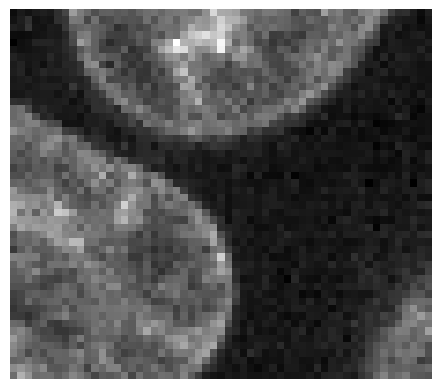

In [91]:
tfm = RandCrop(roi_size=(50, 50), max_roi_size=(60,70), random_size=True)
im2 = tfm(im)
print(im2.shape)
show_image(im2)

torch.Size([1, 95, 147])


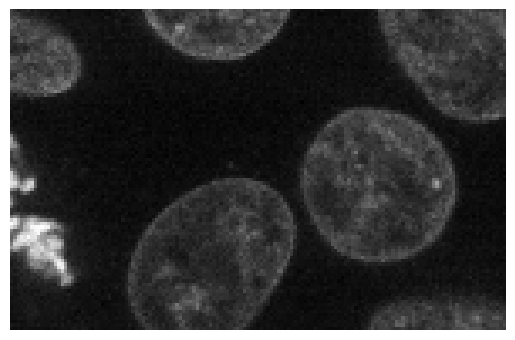

In [92]:
tfm = RandCrop(roi_size=(50, 50), random_size=True)
im2 = tfm(BioImageBase(im))
print(im2.shape)
show_image(im2)

In [93]:
#| export
RandSpatialCrop = RandCrop

In [94]:
#| export

class RandCrop2D(RandTransform):
    """
    Randomly crops a 2D image to a specified size.

    This transform randomly crops a 2D image to a specified size during training and 
    performs a center crop during validation.
    """
    split_idx,order = None,1
    def __init__(self, 
        size:int|tuple, # Size to crop to, duplicated if one value is specified
        lazy = False,   # a flag to indicate whether this transform should execute lazily or not. Defaults to False
        **kwargs
    ):
        size = _process_sz(size, ndim=2)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, 
        b, 
        split_idx:int # Index of the train/valid dataset
    ):
        "Randomly positioning crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx: self.ctr = (self.orig_sz)//2
        else:
            wd = self.orig_sz[0] - self.size[0]
            hd = self.orig_sz[1] - self.size[1]
            w_rand = (wd, -1) if wd < 0 else (0, wd)
            h_rand = (hd, -1) if hd < 0 else (0, hd)
            self.ctr = fastuple(random.randint(*w_rand)+self.size[0]//2, random.randint(*h_rand)+self.size[1]//2)

    def encodes(self, x: BioImageBase):
        """Apply spatial cropping to a BioImageBase object."""
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_center=self.ctr, roi_size=self.size, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        half_w, half_h = self.size[0] // 2, self.size[1] // 2
        cx, cy = self.ctr

        # Calculate crop region
        x_start, x_end = max(cx - half_w, 0), min(cx + half_w, x.shape[0])
        y_start, y_end = max(cy - half_h, 0), min(cy + half_h, x.shape[1])

        return x[x_start:x_end, y_start:y_end]

In [95]:
#| export

class RandCropND(RandTransform):
    """
    Randomly crops an ND image to a specified size.

    This transform randomly crops an ND image to a specified size during training and performs
    a center crop during validation. It supports both 2D and 3D images and videos, assuming
    the first dimension is the batch dimension.
    """

    split_idx,order = None,1
        
    def __init__(self, size: int | tuple, # Size to crop to, duplicated if one value is specified
                 lazy = False,            # a flag to indicate whether this transform should execute lazily or not. Defaults to False
                 **kwargs):
        size = _process_sz(size)
        store_attr()
        super().__init__(**kwargs)

    def before_call(self, b, split_idx: int):
        "Randomly position crop if train dataset else center crop"
        self.orig_sz = _get_sz(b)
        if split_idx:
            self.tl = tuple((osz - sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
            self.br = tuple((osz + sz) // 2 for osz, sz in zip(self.orig_sz, self.size))
        else:
            tl = [] # top-left corner
            br = [] # bottom-right corner
            # Calculate top-left and bottom-right corner coordinates for random crop
            for osz, sz in zip(self.orig_sz, self.size):
                w_dif = osz - sz
                if w_dif < 0:
                    w_rand = (0, 0) # No random cropping if input size is smaller than crop size
                    sz = osz # Adjust crop size to match input size
                else:
                    w_rand = (0, w_dif)
                rnd = random.randint(*w_rand)
                tl.append(rnd)
                br.append(rnd + sz)
            self.tl = fastuple(*tl)
            self.br = fastuple(*br)

    def encodes(self, x:BioImageBase):
        "Apply spatial crop transformation to the input image."
        bioimagetype = type(x)
        return bioimagetype(mt.SpatialCrop(roi_start=self.tl, roi_end=self.br, lazy=self.lazy)(x))
    
    def encodes(self, x: np.ndarray):
        """Apply spatial cropping to a NumPy array."""
        slices = tuple(slice(t, b) for t, b in zip(self.tl, self.br))
        return x[slices]
    

In [96]:
# Define a random tensor
orig_size = (65, 65)
rand_tensor = BioImageBase(rand(8, *orig_size))

for i in range(100):
    test_eq((8,64,64),RandCropND((64,64))(rand_tensor).shape)

### Spatial Orientation & Deformation

In [97]:
class RandRotate(RandMonaiTransform):

    _monai_rand_transform = mt.RandRotate
    _monai_det_transform = mt.Rotate

    _rand_kwargs = {'angle': ['range_x', 'range_y', 'range_z']}
    _default_kwargs = {'range_x': 0, 'range_y': 0, 'range_z': 0}

    def encodes(self, x: BioImageBase):

        # CYX → MONAI expects 1 value
        if x.ndim == 3:
            angle = self.sampled_kwargs["angle"]
            self.sampled_kwargs["angle"] = angle[0]

        tfm = self._monai_det_transform(**self.sampled_kwargs)
        out = tfm(x)

        return type(x)(x=out, meta=x.meta)

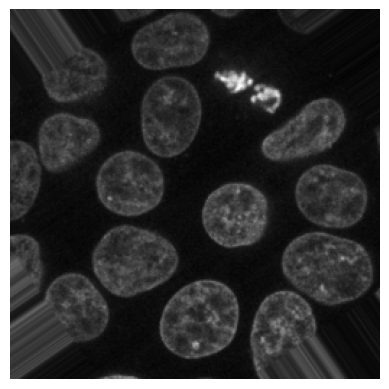

In [98]:
tfm = RandRotate(range_x=(-30, 30), keep_size=True, prob=1)
show_image(tfm(BioImageBase(im)));

In [99]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(rand(*orig_size))

In [100]:
print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandRotate(prob=1, range_x=1)(rand_tensor))

orig tensor:  metatensor([[[0.1596, 0.0046, 0.9038, 0.2495],
         [0.2088, 0.8158, 0.4398, 0.5230],
         [0.2839, 0.6137, 0.0562, 0.3888],
         [0.8245, 0.4336, 0.6233, 0.2059]]]) 

metatensor([[[0.5951, 0.6678, 0.4951, 0.4349],
         [0.0477, 0.5862, 0.2733, 0.3179],
         [0.2462, 0.6263, 0.3958, 0.5629],
         [0.2346, 0.3480, 0.5485, 0.4988]]])
metatensor([[[0.5122, 0.7102, 0.4806, 0.4473],
         [0.0746, 0.5895, 0.2839, 0.3274],
         [0.2415, 0.6210, 0.3836, 0.5261],
         [0.2415, 0.3862, 0.5312, 0.5162]]])
metatensor([[[0.2029, 0.2357, 0.2179, 0.8252],
         [0.2661, 0.6639, 0.5659, 0.5077],
         [0.5773, 0.4571, 0.2144, 0.4912],
         [0.4806, 0.5783, 0.3198, 0.3668]]])


In [101]:
#| export
class RandRotate90(RandMonaiTransform):
    """
    Randomly rotate an image by 90-degree increments.

    This transform randomly rotates an image by 0, 90, 180, or 270 degrees during training and applies no rotation during validation.
    """

    _monai_rand_transform = mt.RandRotate90
    _monai_det_transform = mt.Rotate90

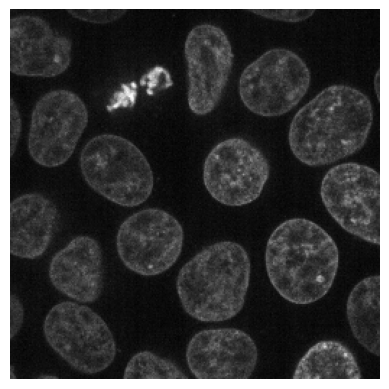

In [102]:
tfm = RandRotate90(max_k=3, prob=1)
show_image(tfm(im));

In [103]:
#| export
class RandFlip(RandMonaiTransform):
    """
    Randomly flips an ND image over a specified axis.
    Works with both NumPy arrays and BioImageBase objects.
    """
    _monai_rand_transform = mt.RandFlip
    _monai_det_transform = mt.Flip
        

In [104]:
image = np.random.rand(1, 3, 3)  
flip_transform = RandFlip(prob=1., spatial_axis=0)  
flipped_image = flip_transform(image)
print('original:\n', image)
print('flipped:\n', flipped_image)  
test_eq(image[0,0,0], flipped_image[0,2,0]) # Check if the image is flipped correctly


original:
 [[[0.44364188 0.46113078 0.07559466]
  [0.8950599  0.56041911 0.54807896]
  [0.57891487 0.23809395 0.76765788]]]
flipped:
 metatensor([[[0.5789, 0.2381, 0.7677],
         [0.8951, 0.5604, 0.5481],
         [0.4436, 0.4611, 0.0756]]], dtype=torch.float64)


In [105]:
# Define a random tensor
orig_size = (1,4,4)
rand_tensor = BioImageBase(rand(*orig_size))
print('orig tensor: ', rand_tensor, '\n')
for i in range(3):
    print(RandFlip(prob=.75, spatial_axis=None)(rand_tensor))

orig tensor:  metatensor([[[0.4059, 0.5601, 0.5892, 0.4850],
         [0.3833, 0.8954, 0.6455, 0.1365],
         [0.5497, 0.5312, 0.3467, 0.3130],
         [0.1497, 0.0537, 0.2243, 0.3056]]]) 

metatensor([[[0.3056, 0.2243, 0.0537, 0.1497],
         [0.3130, 0.3467, 0.5312, 0.5497],
         [0.1365, 0.6455, 0.8954, 0.3833],
         [0.4850, 0.5892, 0.5601, 0.4059]]])
metatensor([[[0.3056, 0.2243, 0.0537, 0.1497],
         [0.3130, 0.3467, 0.5312, 0.5497],
         [0.1365, 0.6455, 0.8954, 0.3833],
         [0.4850, 0.5892, 0.5601, 0.4059]]])
metatensor([[[0.3056, 0.2243, 0.0537, 0.1497],
         [0.3130, 0.3467, 0.5312, 0.5497],
         [0.1365, 0.6455, 0.8954, 0.3833],
         [0.4850, 0.5892, 0.5601, 0.4059]]])


In [106]:
#| export
class RandZoom(RandMonaiTransform):
    """
    Randomly zoom the input arrays with given probability within given zoom range.

    """

    _monai_rand_transform = mt.RandZoom
    _monai_det_transform = mt.Zoom

    def __init__(self,
                 prob=0.1,
                 min_zoom=0.9, 
                 max_zoom=1.1,
                 keys=None, 
                 **kwargs
                 ):

        super().__init__(
            keys=keys,
            prob=prob,
            min_zoom=min_zoom, 
            max_zoom=max_zoom,
            **kwargs,
        )

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):

        self.sampled_kwargs = {}

        min_zoom = self.kwargs["min_zoom"]
        max_zoom = self.kwargs["max_zoom"]

        if isinstance(min_zoom, Sequence):
            zoom_pairs = [
                (min_z,max_z) 
                for min_z,max_z in zip(
                    min_zoom, max_zoom
                    )
                ]
            sampled_zoom = tuple(
                self.param_sampler(v) for v in zoom_pairs
            )
            self.sampled_kwargs["zoom"] = sampled_zoom
        else:
            self.sampled_kwargs["zoom"] = self.param_sampler((min_zoom,max_zoom))

        # merge sampled into deterministic params
        self.sampled_kwargs = {
            **self.det_kwargs,
            **self.sampled_kwargs,
        }

In [107]:
print('orig tensor: ', rand_tensor, '\n')

for i in range(3):
    print(RandZoom(prob=1)(rand_tensor))

orig tensor:  metatensor([[[0.4059, 0.5601, 0.5892, 0.4850],
         [0.3833, 0.8954, 0.6455, 0.1365],
         [0.5497, 0.5312, 0.3467, 0.3130],
         [0.1497, 0.0537, 0.2243, 0.3056]]]) 

metatensor([[[0.4059, 0.5601, 0.5892, 0.4850],
         [0.3833, 0.8954, 0.6455, 0.1365],
         [0.5497, 0.5312, 0.3467, 0.3130],
         [0.1497, 0.0537, 0.2243, 0.3056]]])
metatensor([[[0.4059, 0.5601, 0.5892, 0.4850],
         [0.3833, 0.8954, 0.6455, 0.1365],
         [0.5497, 0.5312, 0.3467, 0.3130],
         [0.1497, 0.0537, 0.2243, 0.3056]]])
metatensor([[[0.4059, 0.5601, 0.5892, 0.4850],
         [0.3833, 0.8954, 0.6455, 0.1365],
         [0.5497, 0.5312, 0.3467, 0.3130],
         [0.1497, 0.0537, 0.2243, 0.3056]]])


### Noise & Intensity Shift


In [108]:
#| export
class RandCameraNoise(RandTransform):
    """
    Simulates camera noise with typedispatch support:
    - MetaTensor (kept in tensor domain)
    - dict (image key-based pipeline)
    - BioImageBase (type preserved)
    - NumPy arrays
    """

    def __init__(
        self,
        prob: float = 1.0,
        damp=1e-2,
        qe=0.7,
        gain=2,
        offset=100,
        exp_time=0.1,
        dark_current=0.6,
        readout=1.5,
        bitdepth=16,
        seed=42,
        simulation=False,
        camera='cmos',
        gain_variance=0.1,
        offset_variance=5,
        keys=None,  # <-- for dict support
    ):
        store_attr()
        self.p = prob
        self.rs = np.random.RandomState(seed=seed)

    # -------------------------
    # CORE NOISE FUNCTION 
    # -------------------------
    def _apply_noise(self, x, rs):
        max_adu = float(2**self.bitdepth - 1)

        # normalize input
        if x.min() >= 0.0 and x.max() <= 1.0:
            x = (x * max_adu).astype(np.uint16 if self.bitdepth > 8 else np.uint8)

        # photon model
        if not self.simulation:
            photons = x / self.gain / self.qe * self.damp
        else:
            photons = x

        photons = rs.poisson(photons, size=photons.shape)
        electrons = self.qe * photons

        # dark current
        electrons += rs.poisson(self.dark_current * self.exp_time, size=electrons.shape)

        # read noise (FIX: std should NOT be squared)
        electrons += rs.normal(scale=self.readout, size=electrons.shape) * (self.bitdepth / 16)

        gain = np.broadcast_to(self.gain, electrons.shape).astype(np.float32).copy()
        offset = np.broadcast_to(self.offset, electrons.shape).astype(np.float32).copy()

        if self.camera == 'cmos':
            gain_noise = rs.normal(scale=self.gain_variance, size=electrons.shape)
            offset_noise = (
                rs.normal(scale=self.offset_variance, size=electrons.shape)
                + rs.normal(scale=self.offset_variance, size=(electrons.shape[0],))
            )

            gain = gain + gain_noise
            offset = offset + offset_noise

        adu = electrons * gain + offset
        adu = np.clip(adu, 0, max_adu)

        return adu

    # -------------------------
    # MetaTensor
    # -------------------------
    def encodes(self, x: "MetaTensor"):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # torch.Tensor
    # -------------------------
    def encodes(self, x: torchTensor):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x.numpy(), rs)
        return torch.as_tensor(out)

    # -------------------------
    # dict (MONAI-style)
    # -------------------------
    def encodes(self, x: dict):
        if self.keys is None:
            raise ValueError("keys must be provided for dict input")

        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))

        x = dict(x)  # avoid mutation
        for k in self.keys:
            x[k] = self._apply_noise(x[k], rs)

        return x

    # -------------------------
    # BioImageBase
    # -------------------------
    def encodes(self, x: BioImageBase):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        out = self._apply_noise(x, rs)
        return type(x)(out)

    # -------------------------
    # NumPy
    # -------------------------
    def encodes(self, x: np.ndarray):
        rs = np.random.RandomState(self.rs.randint(0, 2**32 - 1))
        return self._apply_noise(x, rs)

In [109]:
img3 = img[30]

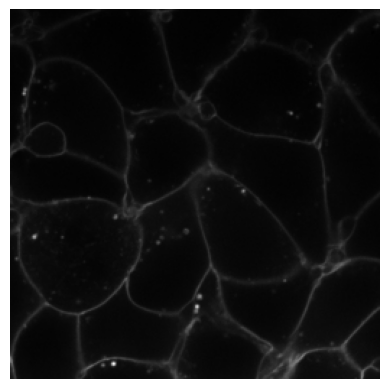

In [110]:
# Original clean image
show_image(img3)

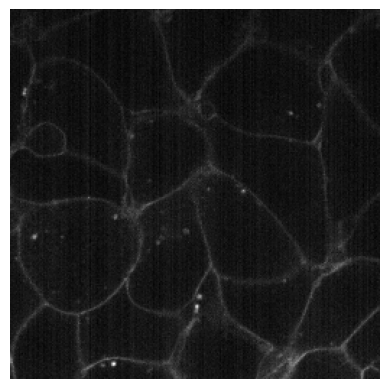

In [111]:
# Noisy image simulating a CMOS camera
show_image(RandCameraNoise(camera = 'cmos').encodes(img3))

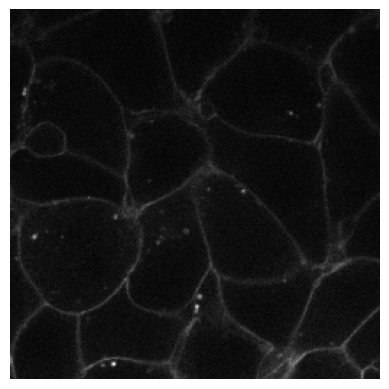

In [112]:
# Noisy image simulating a CCD camera
show_image(RandCameraNoise(camera = 'ccd', readout=2).encodes(img3))

In [113]:
#| export
class RandGaussianNoise(RandMonaiTransform):
    """
    Add Gaussian noise to image.
    """
    _monai_rand_transform = mt.RandGaussianNoise
    _monai_det_transform = mt.RandGaussianNoise

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        pass

    def encodes(self, x: BioImageBase):

        if self._rand_transform is None:
            self._build_rand_transform()

        out = self._rand_transform(x)

        return type(x)(
            x=out,
            meta=x.meta,
        )

In [114]:
x =  [[1,1],[1,1]]
RandGaussianNoise(prob=1, std=5)(BioImageBase(x))

BioImageBase([[-0.1457,  0.5818],
        [ 0.7468,  0.4134]])

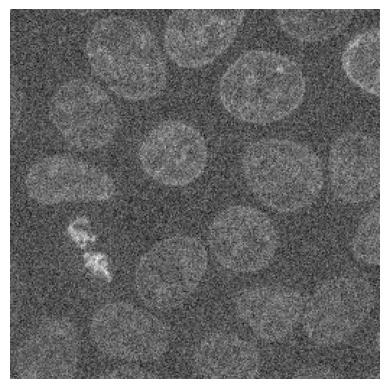

In [115]:
show_image(RandGaussianNoise(prob=1, mean=100, std=10000)(BioImageBase(im)))

In [116]:
#| export
class RandGaussianSmooth(RandMonaiTransform):
    """
    Apply Gaussian smoothing with randomly sampled sigma.
    """
    _monai_rand_transform = mt.RandGaussianSmooth
    _monai_det_transform = mt.GaussianSmooth

    _rand_kwargs = {'sigma': ['sigma_x', 'sigma_y']}

    def __init__(self, 
                 sigma_x=(0.25, 1.5), 
                 sigma_y=(0.25, 1.5), 
                 sigma_z=(0.25, 1.5), 
                 prob=0.1, 
                 param_sampler=_uniform_sampler, 
                 keys=None, 
                 **kwargs
                 ):
        super().__init__(prob=prob, 
                         param_sampler=param_sampler,
                         keys=keys, 
                         sigma_x=sigma_x,
                         sigma_y= sigma_y,
                         sigma_z=sigma_z, 
                         **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma': ['sigma_x', 'sigma_y', 'sigma_z']}

        super().before_call(b, split_idx)

In [117]:
#| export
RandBlur = RandGaussianSmooth

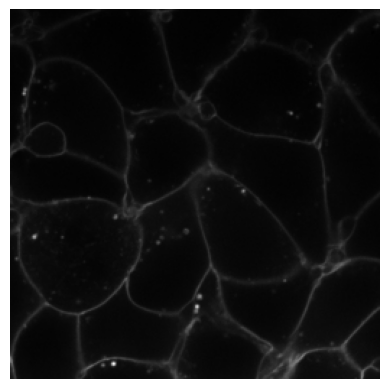

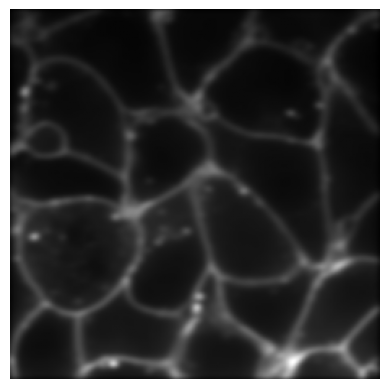

In [118]:
# Apply Blur transform to the image
blur_transform = RandBlur(prob=1, sigma_x = (1.0, 5.0), sigma_y = (1, 5)) 
sharp_img = blur_transform(img)

# plot the original image
show_image(img)
# Plot the blurred image
show_image(sharp_img)

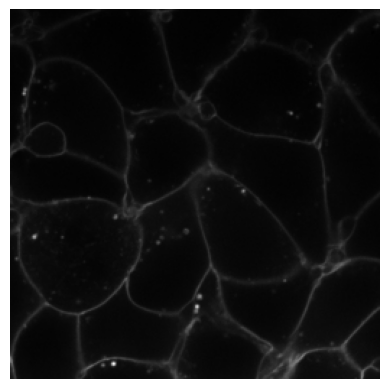

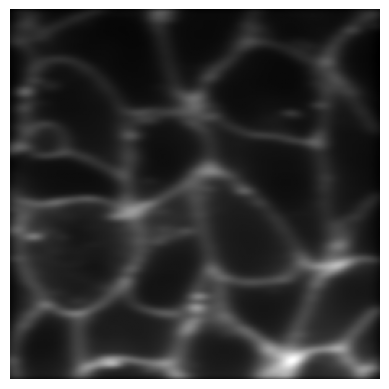

In [119]:
# Apply Blur transform to the image
blur_transform = RandBlur((1.0, 5.0), (1.0, 5.0), prob = 1) 
blurred_img = blur_transform(MetaTensor(img))

# plot the original image
show_image(img)
# Plot the blurred image
show_image(blurred_img)

In [120]:
#| export
class RandGaussianSharpen(RandMonaiTransform):
    """
    Randomly sharpen image using Gaussian kernels.
    """

    _monai_rand_transform = mt.RandGaussianSharpen
    _monai_det_transform = mt.GaussianSharpen

    _rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y'],
                    'sigma2': ['sigma2_x', 'sigma2_y']
                    }

    def __init__(self, 
                sigma1_x=(0.5, 1.0), 
                sigma1_y=(0.5, 1.0), 
                sigma1_z=(0.5, 1.0), 
                sigma2_x=0.5, 
                sigma2_y=0.5, 
                sigma2_z=0.5,
                alpha=(10.0,30.0),
                **kwargs
                ):
        
        super().__init__(sigma1_x=sigma1_x,
                        sigma1_y= sigma1_y,
                        sigma1_z=sigma1_z, 
                        sigma2_x=sigma2_x, 
                        sigma2_y=sigma2_y, 
                        sigma2_z=sigma2_z,
                        alpha=alpha,
                        **kwargs)

    # @dispatch
    def before_call(self, b:BioImageBase, split_idx=0):
        if len(_get_sz(b)) == 3:
            self._rand_kwargs = {'sigma1': ['sigma1_x', 'sigma1_y', 'sigma1_z'],
                                'sigma2': ['sigma2_x', 'sigma2_y', 'sigma2_z']
                                }

        super().before_call(b, split_idx)

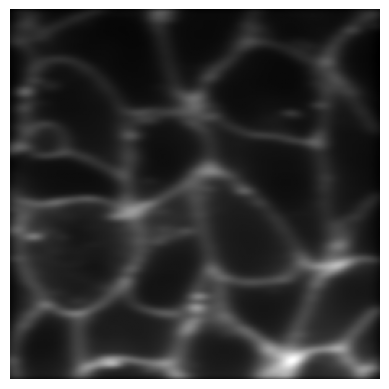

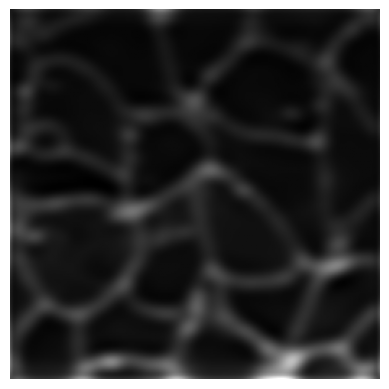

In [121]:
# Apply Blur transform to the image
blur_transform = RandGaussianSharpen((1.0, 5.0), (1.0, 5.0), prob =1) 
sharp_img = blur_transform(blurred_img)

# plot the original image
show_image(blurred_img)
# Plot the blurred image
show_image(sharp_img)

In [122]:
#| export
class RandShiftIntensity(RandMonaiTransform):
    """
    Randomly shift image intensity.

    Equivalent to MONAI RandShiftIntensity but uses the deterministic
    ShiftIntensity transform internally.
    """
    _monai_rand_transform = mt.RandShiftIntensity
    _monai_det_transform = mt.ShiftIntensity

    _rand_kwargs = {'offset': 'offsets'}

    def __init__(self,
                 offsets,
                 **kwargs,
                 ):

        super().__init__(
            offsets=offsets,
            **kwargs,
        )

class RandStdShiftIntensity(RandMonaiTransform):
    """
    Randomly shift intensity by a factor of the image standard deviation.
    """
    _monai_rand_transform = mt.RandStdShiftIntensity
    _monai_det_transform = mt.StdShiftIntensity

    _rand_kwargs = {'factor': 'factors'}

    def __init__(self,
                 factors,
                 **kwargs,
                 ):

        super().__init__(
            factors=factors,
            **kwargs,
        )

In [123]:
#| export
class RandAdjustContrast(RandMonaiTransform):
    """
    Randomly adjust image contrast using gamma correction.
    """

    _monai_rand_transform = mt.RandAdjustContrast
    _monai_det_transform = mt.AdjustContrast

    _rand_kwargs = {'gamma': 'gamma'}

### Intensity Normalization

### Thresholding & Masking

In [124]:
#| hide
import nbdev; nbdev.nbdev_export()